<div style="display:block;width:100%;margin:auto;" direction=rtl align=center>
    <br><br>
    <div style="width:100%;margin:100;display:block;background-color:#fff0;" display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">
            <tr>
                <td style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> Intelligent Information Retrieval</b><br><br>Computer Assignment 5</font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
            </tr>
        </table>
        <h2> Farzad Jannati - 810103099 </h2>
        <h1> Instructor: DR. Azadeh Shakery </h1>
    </div>
</div>

>[Neural and Hybrid IR with Fine-Tuning and LLM Reranking](#scrollTo=CcS6ImB7TU9a)

>>[Imports and Setup](#scrollTo=7faEDtloTYz5)

>>>[Install required packages](#scrollTo=VVBv3Xc-TvNS)

>>>[Import Necessary Libraries](#scrollTo=Eyjf2CkXT1SZ)

>>[Section 1: Dataset Loading and Preprocessing](#scrollTo=ZmCVxzLUUNlY)

>>[Section 2: Retrieval with Pre-trained Models](#scrollTo=AmkhoQLfUeG6)

>>>[A: BM25 Retrieval](#scrollTo=09u307yzUtyI)

>>>[B: Bi-Encoder Dense Retrieval](#scrollTo=eOfYpLvHU6BW)

>>>[C: Cross-Encoder Reranking Pipeline](#scrollTo=vLxjxNvoVCXc)

>>>[Dataset Statistics](#scrollTo=ze2OrQCh3EEH)

>>>[Distribution Analysis](#scrollTo=ze2OrQCh3EEH)

>>>>[📝 Theoretical Analysis: Bi-Encoders vs. Cross-Encoders](#scrollTo=ze2OrQCh3EEH)

>>>>[📝 Theoretical Analysis: Two-Stage Pipeline](#scrollTo=ze2OrQCh3EEH)

>>[Section 3: Fine-Tuning with Full Training](#scrollTo=GEMl0gjOVJ-l)

>>>[A: Data Preparation - Training Triplets](#scrollTo=95JABSBwVWU1)

>>>[B: Full Fine-Tuning](#scrollTo=zG7c0nVaVneS)

>>[Section 4: Parameter-Efficient Fine-Tuning (LoRA)](#scrollTo=fQS1apXVVwxU)

>>>[A: LoRA Implementation](#scrollTo=BD4jSLTyWAuv)

>>[Section 5: Comprehensive Evaluation](#scrollTo=mG9yYVZNWPBd)

>>>[Triplet Construction Strategy](#scrollTo=ESCI7rVQ3EEI)

>>>[Dataset Statistics](#scrollTo=ESCI7rVQ3EEI)

>>>[Training Log Analysis](#scrollTo=ESCI7rVQ3EEI)

>>>[Retrieval Results (Sample Query)](#scrollTo=ESCI7rVQ3EEI)

>>>[What is Hard Negative Mining?](#scrollTo=ESCI7rVQ3EEI)

>>>[Why are Hard Negatives more useful than Random Negatives?](#scrollTo=ESCI7rVQ3EEI)

>>>[What problems arise if ONLY Hard Negatives are used?](#scrollTo=ESCI7rVQ3EEI)

>>>[What is Catastrophic Forgetting and how to mitigate it?](#scrollTo=ESCI7rVQ3EEI)

>>>[LoRA Configuration](#scrollTo=ESCI7rVQ3EEI)

>>>[Parameter Efficiency Analysis](#scrollTo=ESCI7rVQ3EEI)

>>>[Training Dynamics](#scrollTo=ESCI7rVQ3EEI)

>>>[Performance Summary](#scrollTo=ESCI7rVQ3EEI)

>>>[Analysis of Results](#scrollTo=ESCI7rVQ3EEI)

>>>[Theoretical Recommendation (Q&A)](#scrollTo=ESCI7rVQ3EEI)

>>[Section 6: Hybrid Ranking](#scrollTo=3N5b3_BeWpk_)

>>[Section 7: LLM-Based Reranking](#scrollTo=8iQuOjWga7mr)

>>>[Methodology](#scrollTo=BPZtVTMk3EEJ)

>>>[Lambda ($\lambda$) Parameter Tuning Analysis](#scrollTo=BPZtVTMk3EEJ)

>>>[Qualitative Analysis of Reasoning (CoT)](#scrollTo=BPZtVTMk3EEJ)

>>>[Quantitative Performance Comparison (on 200 queries)](#scrollTo=BPZtVTMk3EEJ)

>>>[Efficiency and Cost Trade-off](#scrollTo=BPZtVTMk3EEJ)

>[📝 AI Disclosure](#scrollTo=CYD1mWYF3EEJ)



# Neural and Hybrid IR with Fine-Tuning and LLM Reranking

## Imports and Setup

### Install required packages

In [ ]:
!pip install datasets sentence-transformers rank_bm25 peft transformers openai


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import Necessary Libraries

In [ ]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple, Optional
from collections import defaultdict
from datasets import load_dataset
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation
from sentence_transformers import util as st_util
from torch.utils.data import DataLoader
from rank_bm25 import BM25Okapi
from transformers import AutoTokenizer, AutoModel
from IPython.display import display
import torch.nn.functional as F
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

import torch
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## Section 1: Dataset Loading and Preprocessing

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'BeIR/nfcorpus' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


SECTION 1: DATASET LOADING
Loading BEIR/nfcorpus dataset...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'BeIR/nfcorpus' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loaded 3633 documents


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'BeIR/nfcorpus-qrels' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loaded 3237 queries


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'BeIR/nfcorpus-qrels' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loaded 2590 training queries with relevance judgments


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'BeIR/nfcorpus-qrels' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loaded 323 test queries with relevance judgments

----------------------------------------
Dataset Statistics:
----------------------------------------
Number of documents: 3633
Number of queries: 3237
Training queries: 2590
Test queries: 323
Dev queries: 0
Average relevant docs per training query: 42.69
Average relevant docs per test query: 38.19


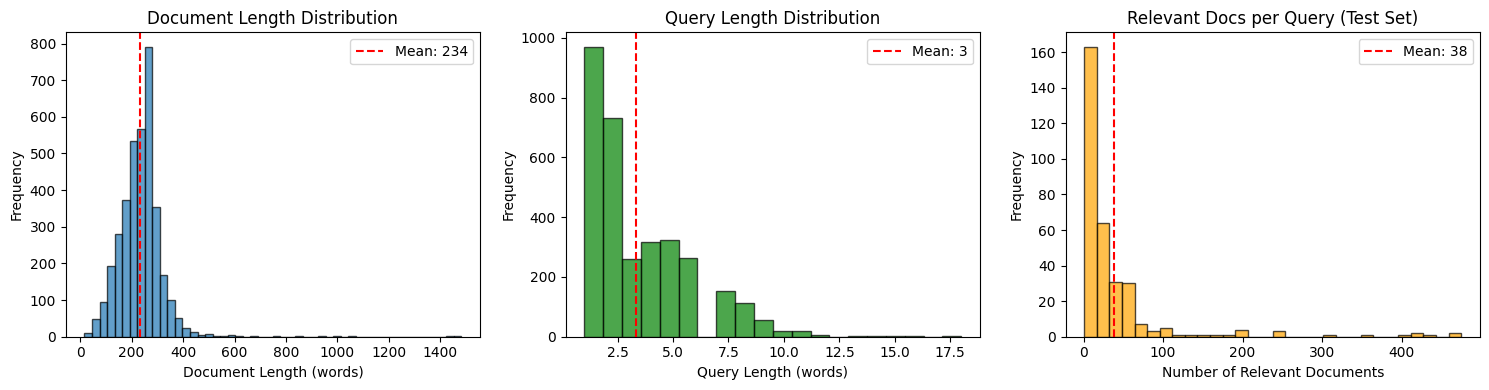

Saved: dataset_statistics.png


In [ ]:
print("=" * 80)
print("SECTION 1: DATASET LOADING")
print("=" * 80)

def load_nfcorpus_dataset():
    """
    Load the BEIR/nfcorpus dataset for medical/nutrition information retrieval.

    Returns:
        corpus: Dictionary mapping doc_id to document dict with 'title' and 'text'
        queries: Dictionary mapping query_id to query text
        qrels_train: Training relevance judgments
        qrels_test: Test relevance judgments
    """
    print("Loading BEIR/nfcorpus dataset...")

    # Load corpus
    corpus_dataset = load_dataset("BeIR/nfcorpus", "corpus", trust_remote_code=True)
    corpus = {}
    for item in corpus_dataset['corpus']:
        corpus[item['_id']] = {
            'title': item['title'],
            'text': item['text']
        }
    print(f"Loaded {len(corpus)} documents")

    # Load queries
    queries_dataset = load_dataset("BeIR/nfcorpus", "queries", trust_remote_code=True)
    queries = {}
    for item in queries_dataset['queries']:
        queries[item['_id']] = item['text']
    print(f"Loaded {len(queries)} queries")

    # Load qrels (relevance judgments)
    qrels_train = defaultdict(dict)
    qrels_test = defaultdict(dict)
    qrels_dev = defaultdict(dict)

    # Load training qrels
    try:
        train_qrels = load_dataset("BeIR/nfcorpus-qrels", split="train", trust_remote_code=True)
        for item in train_qrels:
            qrels_train[item['query-id']][item['corpus-id']] = item['score']
        print(f"Loaded {len(qrels_train)} training queries with relevance judgments")
    except Exception as e:
        print(f"Warning: Could not load train qrels: {e}")

    # Load test qrels
    try:
        test_qrels = load_dataset("BeIR/nfcorpus-qrels", split="test", trust_remote_code=True)
        for item in test_qrels:
            qrels_test[item['query-id']][item['corpus-id']] = item['score']
        print(f"Loaded {len(qrels_test)} test queries with relevance judgments")
    except Exception as e:
        print(f"Warning: Could not load test qrels: {e}")

    # Load dev qrels
    try:
        dev_qrels = load_dataset("BeIR/nfcorpus-qrels", split="dev", trust_remote_code=True)
        for item in dev_qrels:
            qrels_dev[item['query-id']][item['corpus-id']] = item['score']
        print(f"Loaded {len(qrels_dev)} dev queries with relevance judgments")
    except Exception as e:
        print(f"Warning: Could not load dev qrels: {e}")

    return corpus, queries, dict(qrels_train), dict(qrels_test), dict(qrels_dev)

# Load dataset
corpus, queries, qrels_train, qrels_test, qrels_dev = load_nfcorpus_dataset()

# Dataset statistics
print("\n" + "-" * 40)
print("Dataset Statistics:")
print("-" * 40)
print(f"Number of documents: {len(corpus)}")
print(f"Number of queries: {len(queries)}")
print(f"Training queries: {len(qrels_train)}")
print(f"Test queries: {len(qrels_test)}")
print(f"Dev queries: {len(qrels_dev)}")

# Calculate average relevant documents per query
avg_rel_train = np.mean([len(rels) for rels in qrels_train.values()]) if qrels_train else 0
avg_rel_test = np.mean([len(rels) for rels in qrels_test.values()]) if qrels_test else 0
print(f"Average relevant docs per training query: {avg_rel_train:.2f}")
print(f"Average relevant docs per test query: {avg_rel_test:.2f}")

# Prepare document list for indexing
doc_ids = list(corpus.keys())
doc_texts = [f"{corpus[doc_id]['title']} {corpus[doc_id]['text']}" for doc_id in doc_ids]
doc_id_to_idx = {doc_id: idx for idx, doc_id in enumerate(doc_ids)}

# Visualize dataset statistics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Document length distribution
doc_lengths = [len(text.split()) for text in doc_texts]
axes[0].hist(doc_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Document Length (words)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Document Length Distribution')
axes[0].axvline(np.mean(doc_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(doc_lengths):.0f}')
axes[0].legend()

# Query length distribution
query_lengths = [len(q.split()) for q in queries.values()]
axes[1].hist(query_lengths, bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Query Length (words)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Query Length Distribution')
axes[1].axvline(np.mean(query_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(query_lengths):.0f}')
axes[1].legend()

# Relevant documents per query distribution
if qrels_test:
    rel_counts = [len(rels) for rels in qrels_test.values()]
    axes[2].hist(rel_counts, bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[2].set_xlabel('Number of Relevant Documents')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Relevant Docs per Query (Test Set)')
    axes[2].axvline(np.mean(rel_counts), color='red', linestyle='--', label=f'Mean: {np.mean(rel_counts):.0f}')
    axes[2].legend()

plt.tight_layout()
plt.savefig('dataset_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dataset_statistics.png")

## Section 2: Retrieval with Pre-trained Models

### A: BM25 Retrieval


----------------------------------------
Section 2a: BM25 Retrieval
----------------------------------------
Tokenizing and indexing documents for BM25...


Tokenizing: 100%|██████████| 3633/3633 [00:00<00:00, 74136.69it/s]

Indexed 3633 documents



Sample query: 'Do Cholesterol Statin Drugs Cause Breast Cancer?'

Top-10 BM25 results:
  1. [✓] MED-2429: 18.7037 - Statin use and risk of breast cancer: a meta-analysis of obs...
  2. [✓] MED-10: 16.8430 - Statin Use and Breast Cancer Survival: A Nationwide Cohort S...
  3. [✓] MED-14: 15.5251 - Statin use after diagnosis of breast cancer and survival: a ...
  4. [ ] MED-1193: 15.3204 - The effects of lowering LDL cholesterol with statin therapy ...
  5. [✓] MED-2431: 15.1717 - Long-term statin use and risk of ductal and lobular breast c...
  6. [✓] MED-2428: 14.7971 - Women and statin use: a women's health advocacy perspective....
  7. [ ] MED-4695: 14.2834 - Electric light causes cancer? Surely you're joking, Mr. Stev...
  8. [ ] MED-4827: 14.2157 - Men with Low Serum Cholesterol Have a Lower Risk of High-Gra...
  9. [✓] MED-4829: 13.9694 - Statin therapy, muscle function and falls risk in community-...
  10. [ ] MED-2792: 12.6896 - Cholesterol oxides in Indian ghee: possible caus

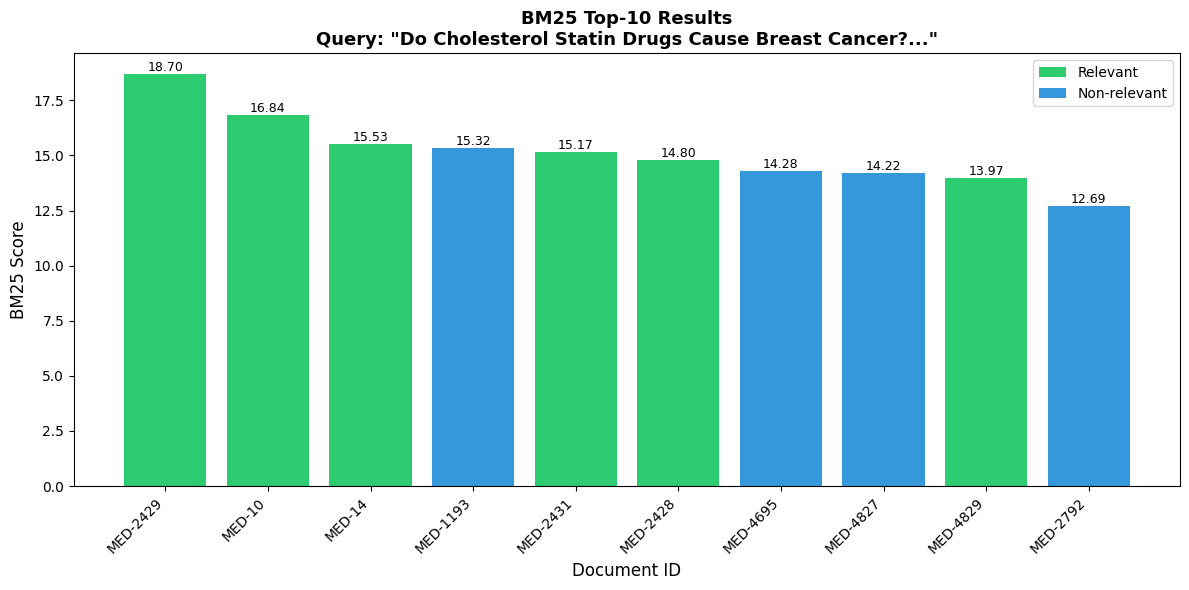

Saved: bm25_results_barchart.png


In [ ]:
print("\n" + "-" * 40)
print("Section 2a: BM25 Retrieval")
print("-" * 40)

class BM25Retriever:
    """
    BM25 retrieval system using Okapi BM25 algorithm.

    Parameters:
        k1: Term frequency saturation parameter (default: 1.5)
        b: Document length normalization parameter (default: 0.75)
    """

    def __init__(self, k1: float = 1.5, b: float = 0.75):
        self.k1 = k1
        self.b = b
        self.bm25 = None
        self.doc_ids = None
        self.tokenized_corpus = None

    def tokenize(self, text: str) -> List[str]:
        """Simple whitespace tokenization with lowercasing."""
        return text.lower().split()

    def index(self, doc_ids: List[str], doc_texts: List[str]):
        """
        Index all documents in the corpus.

        Args:
            doc_ids: List of document identifiers
            doc_texts: List of document texts (title + text)
        """
        print("Tokenizing and indexing documents for BM25...")
        self.doc_ids = doc_ids
        self.tokenized_corpus = [self.tokenize(text) for text in tqdm(doc_texts, desc="Tokenizing")]
        self.bm25 = BM25Okapi(self.tokenized_corpus, k1=self.k1, b=self.b)
        print(f"Indexed {len(doc_ids)} documents")

    def retrieve(self, query: str, top_k: int = 10) -> List[Tuple[str, float]]:
        """
        Retrieve top-k documents for a given query.

        Args:
            query: Query string
            top_k: Number of documents to retrieve

        Returns:
            List of (doc_id, score) tuples sorted by score descending
        """
        tokenized_query = self.tokenize(query)
        scores = self.bm25.get_scores(tokenized_query)

        # Get top-k indices
        top_indices = np.argsort(scores)[::-1][:top_k]

        results = [(self.doc_ids[idx], scores[idx]) for idx in top_indices]
        return results

    def retrieve_batch(self, queries: Dict[str, str], top_k: int = 10) -> Dict[str, List[Tuple[str, float]]]:
        """
        Retrieve documents for multiple queries.

        Args:
            queries: Dictionary mapping query_id to query text
            top_k: Number of documents to retrieve per query

        Returns:
            Dictionary mapping query_id to list of (doc_id, score) tuples
        """
        results = {}
        for qid, query_text in tqdm(queries.items(), desc="BM25 Retrieval"):
            results[qid] = self.retrieve(query_text, top_k)
        return results

# Initialize and index BM25
bm25_retriever = BM25Retriever(k1=1.5, b=0.75)
bm25_retriever.index(doc_ids, doc_texts)

# Test BM25 retrieval
sample_query_id = list(qrels_test.keys())[0] if qrels_test else list(queries.keys())[0]
sample_query = queries[sample_query_id]
print(f"\nSample query: '{sample_query}'")
print("\nTop-10 BM25 results:")
bm25_results = bm25_retriever.retrieve(sample_query, top_k=10)
for rank, (doc_id, score) in enumerate(bm25_results, 1):
    is_relevant = "✓" if qrels_test.get(sample_query_id, {}).get(doc_id, 0) > 0 else " "
    print(f"  {rank}. [{is_relevant}] {doc_id}: {score:.4f} - {corpus[doc_id]['title'][:60]}...")

# Visualization: BM25 Results Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

doc_names = [doc_id for doc_id, _ in bm25_results]
scores = [score for _, score in bm25_results]
colors = ['#2ecc71' if qrels_test.get(sample_query_id, {}).get(doc_id, 0) > 0 else '#3498db'
          for doc_id, _ in bm25_results]

bars = ax.bar(range(len(doc_names)), scores, color=colors)
ax.set_xlabel('Document ID', fontsize=12)
ax.set_ylabel('BM25 Score', fontsize=12)
ax.set_title(f'BM25 Top-10 Results\nQuery: "{sample_query[:60]}..."', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(doc_names)))
ax.set_xticklabels(doc_names, rotation=45, ha='right')

# Add value labels on bars
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.2f}',
            ha='center', va='bottom', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Relevant'),
                   Patch(facecolor='#3498db', label='Non-relevant')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('bm25_results_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bm25_results_barchart.png")

### B: Bi-Encoder Dense Retrieval


----------------------------------------
Section 2b: Bi-Encoder Dense Retrieval
----------------------------------------
Loading bi-encoder model: sentence-transformers/msmarco-distilbert-base-tas-b
Encoding documents with bi-encoder...


Batches: 100%|██████████| 114/114 [00:24<00:00,  4.74it/s]


Indexed 3633 documents with embedding dimension 768

Sample query: 'Do Cholesterol Statin Drugs Cause Breast Cancer?'

Top-10 Bi-Encoder results:
  1. [✓] MED-2429: 0.8261 - Statin use and risk of breast cancer: a meta-analysis of obs...
  2. [✓] MED-10: 0.8242 - Statin Use and Breast Cancer Survival: A Nationwide Cohort S...
  3. [✓] MED-2439: 0.8173 - Plant Sterols as Anticancer Nutrients: Evidence for Their Ro...
  4. [✓] MED-14: 0.8155 - Statin use after diagnosis of breast cancer and survival: a ...
  5. [✓] MED-2428: 0.8038 - Women and statin use: a women's health advocacy perspective....
  6. [ ] MED-1193: 0.7969 - The effects of lowering LDL cholesterol with statin therapy ...
  7. [✓] MED-2435: 0.7956 - Chemoprevention of breast cancer by dietary compounds....
  8. [ ] MED-4827: 0.7942 - Men with Low Serum Cholesterol Have a Lower Risk of High-Gra...
  9. [ ] MED-2525: 0.7935 - A global survey of physicians' perceptions on cholesterol ma...
  10. [ ] MED-1887: 0.7876 - What is

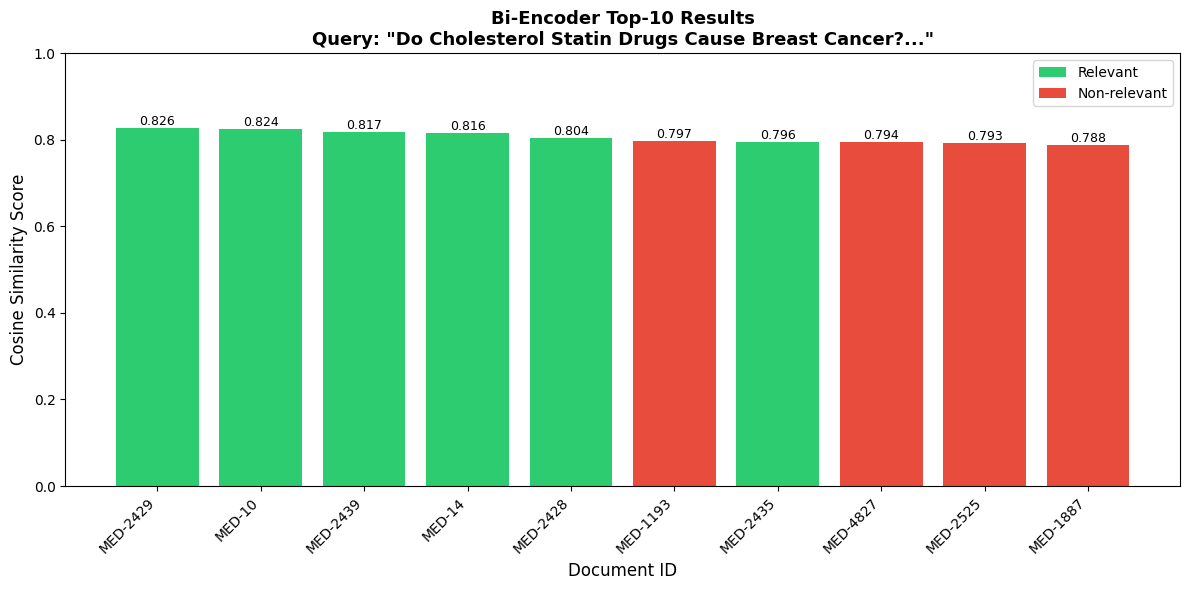

Saved: bi_encoder_results_barchart.png


In [ ]:
print("\n" + "-" * 40)
print("Section 2b: Bi-Encoder Dense Retrieval")
print("-" * 40)

class BiEncoderRetriever:
    """
    Dense retrieval system using bi-encoder architecture.

    The bi-encoder independently encodes queries and documents into dense vectors,
    allowing document embeddings to be pre-computed for efficient retrieval.
    """

    def __init__(self, model_name: str = 'sentence-transformers/msmarco-distilbert-base-tas-b'):
        print(f"Loading bi-encoder model: {model_name}")
        self.model = SentenceTransformer(model_name, device=DEVICE)
        self.doc_ids = None
        self.doc_embeddings = None
        self.model_name = model_name

    def index(self, doc_ids: List[str], doc_texts: List[str], batch_size: int = 32):
        """
        Encode all documents and store their embeddings.

        This is done once at indexing time for efficient retrieval.

        Args:
            doc_ids: List of document identifiers
            doc_texts: List of document texts
            batch_size: Batch size for encoding
        """
        print("Encoding documents with bi-encoder...")
        self.doc_ids = doc_ids
        self.doc_embeddings = self.model.encode(
            doc_texts,
            batch_size=batch_size,
            show_progress_bar=True,
            convert_to_tensor=True,
            device=DEVICE
        )
        print(f"Indexed {len(doc_ids)} documents with embedding dimension {self.doc_embeddings.shape[1]}")

    def retrieve(self, query: str, top_k: int = 10) -> List[Tuple[str, float]]:
        """
        Retrieve top-k documents using cosine similarity.

        Args:
            query: Query string
            top_k: Number of documents to retrieve

        Returns:
            List of (doc_id, score) tuples sorted by similarity descending
        """
        # Encode query
        query_embedding = self.model.encode(
            query,
            convert_to_tensor=True,
            device=DEVICE
        )

        # Compute cosine similarities
        similarities = st_util.cos_sim(query_embedding, self.doc_embeddings)[0]

        # Get top-k indices
        top_k_values, top_k_indices = torch.topk(similarities, min(top_k, len(self.doc_ids)))

        results = [
            (self.doc_ids[idx.item()], score.item())
            for idx, score in zip(top_k_indices, top_k_values)
        ]
        return results

    def retrieve_batch(self, queries: Dict[str, str], top_k: int = 10,
                       batch_size: int = 32) -> Dict[str, List[Tuple[str, float]]]:
        """
        Retrieve documents for multiple queries efficiently.

        Args:
            queries: Dictionary mapping query_id to query text
            top_k: Number of documents to retrieve per query
            batch_size: Batch size for query encoding

        Returns:
            Dictionary mapping query_id to list of (doc_id, score) tuples
        """
        query_ids = list(queries.keys())
        query_texts = [queries[qid] for qid in query_ids]

        print("Encoding queries...")
        query_embeddings = self.model.encode(
            query_texts,
            batch_size=batch_size,
            show_progress_bar=True,
            convert_to_tensor=True,
            device=DEVICE
        )

        print("Computing similarities...")
        # Compute all similarities at once
        all_similarities = st_util.cos_sim(query_embeddings, self.doc_embeddings)

        results = {}
        for i, qid in enumerate(tqdm(query_ids, desc="Ranking")):
            similarities = all_similarities[i]
            top_k_values, top_k_indices = torch.topk(similarities, min(top_k, len(self.doc_ids)))
            results[qid] = [
                (self.doc_ids[idx.item()], score.item())
                for idx, score in zip(top_k_indices, top_k_values)
            ]

        return results

    def get_embeddings_for_docs(self, doc_ids_subset: List[str]) -> torch.Tensor:
        """Get embeddings for a subset of documents."""
        indices = [self.doc_ids.index(doc_id) for doc_id in doc_ids_subset]
        return self.doc_embeddings[indices]

# Initialize and index bi-encoder
bi_encoder = BiEncoderRetriever('sentence-transformers/msmarco-distilbert-base-tas-b')
bi_encoder.index(doc_ids, doc_texts, batch_size=32)

# Test bi-encoder retrieval
print(f"\nSample query: '{sample_query}'")
print("\nTop-10 Bi-Encoder results:")
bi_encoder_results = bi_encoder.retrieve(sample_query, top_k=10)
for rank, (doc_id, score) in enumerate(bi_encoder_results, 1):
    is_relevant = "✓" if qrels_test.get(sample_query_id, {}).get(doc_id, 0) > 0 else " "
    print(f"  {rank}. [{is_relevant}] {doc_id}: {score:.4f} - {corpus[doc_id]['title'][:60]}...")

# Visualization: Bi-Encoder Results Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

doc_names = [doc_id for doc_id, _ in bi_encoder_results]
scores = [score for _, score in bi_encoder_results]
colors = ['#2ecc71' if qrels_test.get(sample_query_id, {}).get(doc_id, 0) > 0 else '#e74c3c'
          for doc_id, _ in bi_encoder_results]

bars = ax.bar(range(len(doc_names)), scores, color=colors)
ax.set_xlabel('Document ID', fontsize=12)
ax.set_ylabel('Cosine Similarity Score', fontsize=12)
ax.set_title(f'Bi-Encoder Top-10 Results\nQuery: "{sample_query[:60]}..."', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(doc_names)))
ax.set_xticklabels(doc_names, rotation=45, ha='right')
ax.set_ylim(0, 1)

# Add value labels on bars
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.3f}',
            ha='center', va='bottom', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Relevant'),
                   Patch(facecolor='#e74c3c', label='Non-relevant')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('bi_encoder_results_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bi_encoder_results_barchart.png")

### C: Cross-Encoder Reranking Pipeline


----------------------------------------
Section 2c: Cross-Encoder Reranking Pipeline
----------------------------------------
Loading cross-encoder model: cross-encoder/ms-marco-MiniLM-L-6-v2

Sample query: 'Do Cholesterol Statin Drugs Cause Breast Cancer?'

Top-10 Two-Stage (Bi-Encoder + Cross-Encoder) results:
  1. [✓] MED-14: 4.5537 - Statin use after diagnosis of breast cancer and survival: a ...
  2. [✓] MED-2429: 4.0972 - Statin use and risk of breast cancer: a meta-analysis of obs...
  3. [✓] MED-10: 3.3038 - Statin Use and Breast Cancer Survival: A Nationwide Cohort S...
  4. [✓] MED-2431: 3.2890 - Long-term statin use and risk of ductal and lobular breast c...
  5. [ ] MED-4827: 2.2460 - Men with Low Serum Cholesterol Have a Lower Risk of High-Gra...
  6. [✓] MED-2428: -0.9985 - Women and statin use: a women's health advocacy perspective....
  7. [ ] MED-2525: -1.8605 - A global survey of physicians' perceptions on cholesterol ma...
  8. [ ] MED-1193: -2.3714 - The effects o

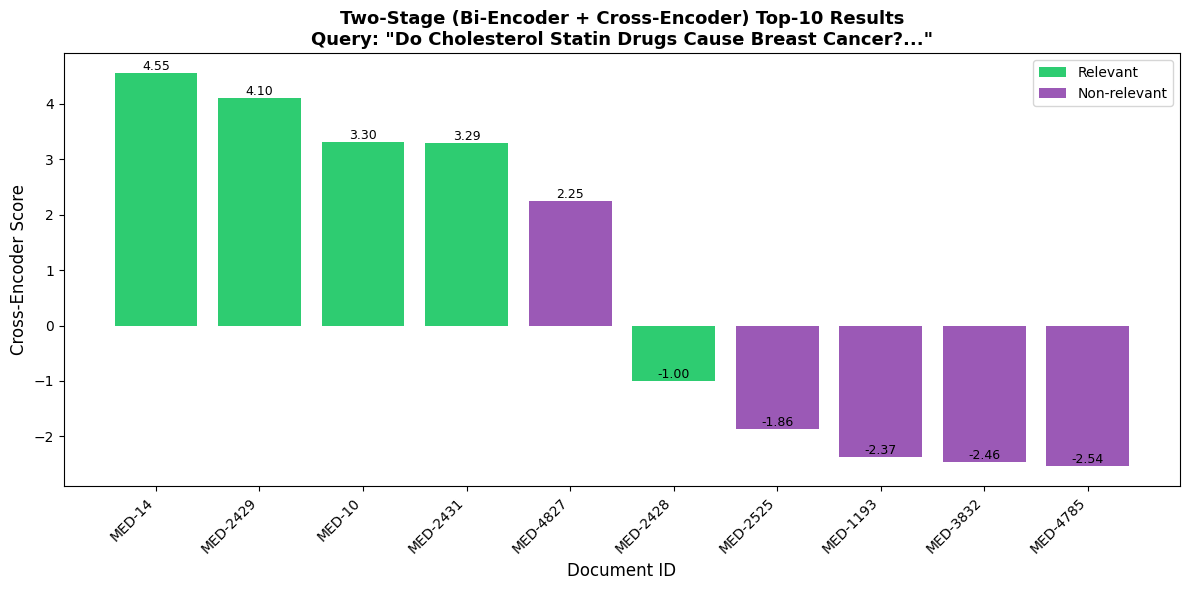

Saved: two_stage_results_barchart.png


In [ ]:
print("\n" + "-" * 40)
print("Section 2c: Cross-Encoder Reranking Pipeline")
print("-" * 40)

from sentence_transformers import CrossEncoder

class CrossEncoderReranker:
    """
    Cross-encoder reranker for two-stage retrieval pipeline.

    The cross-encoder processes query-document pairs jointly,
    providing more accurate relevance scores at the cost of efficiency.
    """

    def __init__(self, model_name: str = 'cross-encoder/ms-marco-MiniLM-L-6-v2'):
        print(f"Loading cross-encoder model: {model_name}")
        self.model = CrossEncoder(model_name, device=DEVICE)
        self.model_name = model_name

    def rerank(self, query: str, candidates: List[Tuple[str, str, float]],
               top_k: int = 10) -> List[Tuple[str, float]]:
        """
        Rerank candidate documents using cross-encoder.

        Args:
            query: Query string
            candidates: List of (doc_id, doc_text, initial_score) tuples
            top_k: Number of documents to return after reranking

        Returns:
            List of (doc_id, score) tuples sorted by cross-encoder score
        """
        if not candidates:
            return []

        # Prepare query-document pairs
        pairs = [(query, doc_text) for _, doc_text, _ in candidates]

        # Get cross-encoder scores
        scores = self.model.predict(pairs, show_progress_bar=False)

        # Combine with doc_ids and sort
        scored_docs = [
            (candidates[i][0], float(scores[i]))
            for i in range(len(candidates))
        ]
        scored_docs.sort(key=lambda x: x[1], reverse=True)

        return scored_docs[:top_k]

class TwoStageRetriever:
    """
    Two-stage retrieval pipeline combining bi-encoder and cross-encoder.

    Stage 1: Bi-encoder retrieves top-k candidates efficiently
    Stage 2: Cross-encoder reranks candidates for higher accuracy
    """

    def __init__(self, bi_encoder: BiEncoderRetriever, cross_encoder: CrossEncoderReranker,
                 corpus: Dict[str, Dict]):
        self.bi_encoder = bi_encoder
        self.cross_encoder = cross_encoder
        self.corpus = corpus

    def retrieve(self, query: str, first_stage_k: int = 100,
                 final_k: int = 10) -> List[Tuple[str, float]]:
        """
        Two-stage retrieval: bi-encoder candidates → cross-encoder reranking.

        Args:
            query: Query string
            first_stage_k: Number of candidates from bi-encoder
            final_k: Number of final results after reranking

        Returns:
            List of (doc_id, score) tuples
        """
        # Stage 1: Get candidates from bi-encoder
        candidates = self.bi_encoder.retrieve(query, top_k=first_stage_k)

        # Prepare candidates with document text
        candidates_with_text = [
            (doc_id, f"{self.corpus[doc_id]['title']} {self.corpus[doc_id]['text']}", score)
            for doc_id, score in candidates
        ]

        # Stage 2: Rerank with cross-encoder
        reranked = self.cross_encoder.rerank(query, candidates_with_text, top_k=final_k)

        return reranked

    def retrieve_batch(self, queries: Dict[str, str], first_stage_k: int = 100,
                       final_k: int = 10) -> Dict[str, List[Tuple[str, float]]]:
        """
        Two-stage retrieval for multiple queries.
        """
        results = {}
        for qid, query_text in tqdm(queries.items(), desc="Two-stage Retrieval"):
            results[qid] = self.retrieve(query_text, first_stage_k, final_k)
        return results

# Initialize cross-encoder and two-stage pipeline
cross_encoder = CrossEncoderReranker('cross-encoder/ms-marco-MiniLM-L-6-v2')
two_stage_retriever = TwoStageRetriever(bi_encoder, cross_encoder, corpus)

# Test two-stage retrieval
print(f"\nSample query: '{sample_query}'")
print("\nTop-10 Two-Stage (Bi-Encoder + Cross-Encoder) results:")
two_stage_results = two_stage_retriever.retrieve(sample_query, first_stage_k=100, final_k=10)
for rank, (doc_id, score) in enumerate(two_stage_results, 1):
    is_relevant = "✓" if qrels_test.get(sample_query_id, {}).get(doc_id, 0) > 0 else " "
    print(f"  {rank}. [{is_relevant}] {doc_id}: {score:.4f} - {corpus[doc_id]['title'][:60]}...")

# Visualization: Two-Stage Results Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

doc_names = [doc_id for doc_id, _ in two_stage_results]
scores = [score for _, score in two_stage_results]
colors = ['#2ecc71' if qrels_test.get(sample_query_id, {}).get(doc_id, 0) > 0 else '#9b59b6'
          for doc_id, _ in two_stage_results]

bars = ax.bar(range(len(doc_names)), scores, color=colors)
ax.set_xlabel('Document ID', fontsize=12)
ax.set_ylabel('Cross-Encoder Score', fontsize=12)
ax.set_title(f'Two-Stage (Bi-Encoder + Cross-Encoder) Top-10 Results\nQuery: "{sample_query[:60]}..."',
             fontsize=13, fontweight='bold')
ax.set_xticks(range(len(doc_names)))
ax.set_xticklabels(doc_names, rotation=45, ha='right')

# Add value labels on bars
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.2f}',
            ha='center', va='bottom', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Relevant'),
                   Patch(facecolor='#9b59b6', label='Non-relevant')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('two_stage_results_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: two_stage_results_barchart.png")

<div style="background-color: #f7f9fc; border: 1px solid #e1e4e8; border-radius: 8px; padding: 25px; font-family: 'Segoe UI', 'Helvetica Neue', Arial, sans-serif; color: #333; box-shadow: 0 4px 12px rgba(0,0,0,0.05); box-sizing: border-box;">

<h1 style="color: #0366d6; border-bottom: 2px solid #ddd; padding-bottom: 10px; margin-top: 0;">
Assignment 5: Neural Information Retrieval & Reranking
</h1>

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px;">
Overview and Objectives
</h2>

<blockquote style="background-color: #eef6fc; border-left: 5px solid #0366d6; padding: 15px; margin-left: 0; margin-right: 0;">
  <em>This report covers the implementation and analysis of various Information Retrieval (IR) paradigms using the <strong>BEIR/nfcorpus</strong> dataset. The focus is on comparing sparse retrieval (BM25) with dense retrieval strategies (Bi-Encoders) and high-precision reranking pipelines (Cross-Encoders), addressing the theoretical and practical trade-offs between efficiency and accuracy.</em>
</blockquote>

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
Section 1: Dataset Loading and Preprocessing
</h2>

<blockquote style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Objective:</strong> Load the BEIR/nfcorpus dataset (Medical/Nutrition domain), analyze its statistics, and prepare it for the retrieval tasks.
</blockquote>

### 1. Dataset Statistics
The dataset was successfully loaded with the following characteristics:
*   **Documents:** 3,633 medical articles (Titles + Text).
*   **Queries:** 3,237 natural language questions.
*   **Training Queries:** 2,590 (with relevance judgments).
*   **Test Queries:** 323.
*   **Relevance Density:** The dataset is quite dense, with an average of **38.19 relevant documents** per test query.

### 2. Distribution Analysis
The histograms below visualize the distribution of document lengths, query lengths, and relevance judgments.
*   **Document Length:** Most documents are abstract-length, suitable for dense retrieval models like BERT which typically handle ~512 tokens.
*   **Query Length:** Queries are relatively descriptive natural language questions, not just keywords.
*   **Relevance:** The high number of relevant docs per query suggests this is a high-recall task (finding *all* relevant medical evidence).

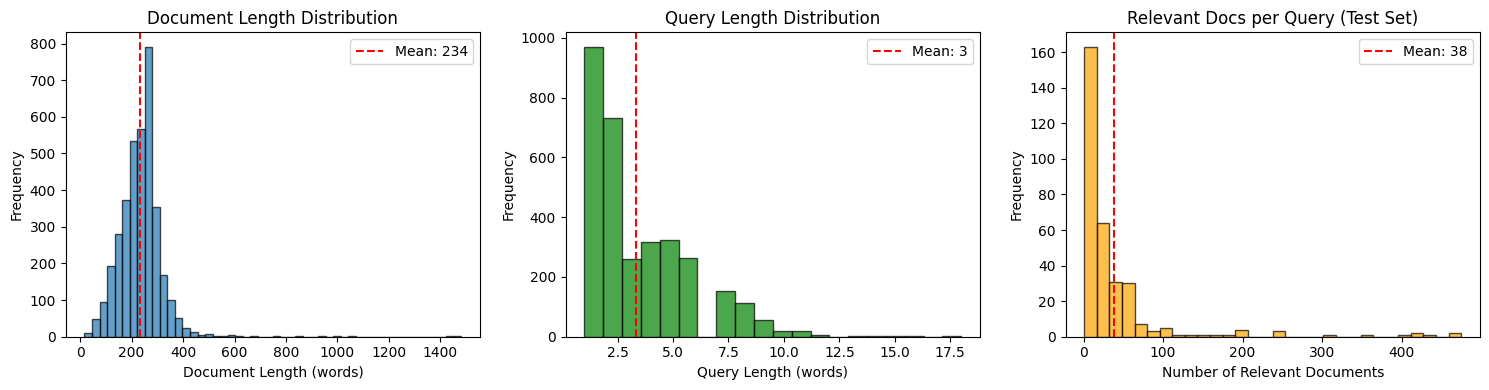

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
Section 2: Retrieval with Pre-trained Models
</h2>

<h3 style="color: #0366d6; margin-top: 20px;">Part A: BM25 Retrieval (Sparse Baseline)</h3>

<blockquote style="background-color: #e6fffa; border-left: 5px solid #009688; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Implementation:</strong> <code>BM25Okapi</code> from the <code>rank_bm25</code> library was used with standard parameters (k1=1.5, b=0.75).
</blockquote>

**Results Analysis:**
For the sample query *'Do Cholesterol Statin Drugs Cause Breast Cancer?'*:
*   The top result (**MED-2429**, Score: 18.70) is highly relevant ("Statin use and risk of breast cancer...").
*   BM25 successfully retrieves documents containing exact keyword matches ("Statin", "Breast Cancer").
*   However, it relies on lexical overlap. It might miss documents using synonyms (e.g., "Lipid-lowering agents" instead of "Statin") if they don't appear in the text.

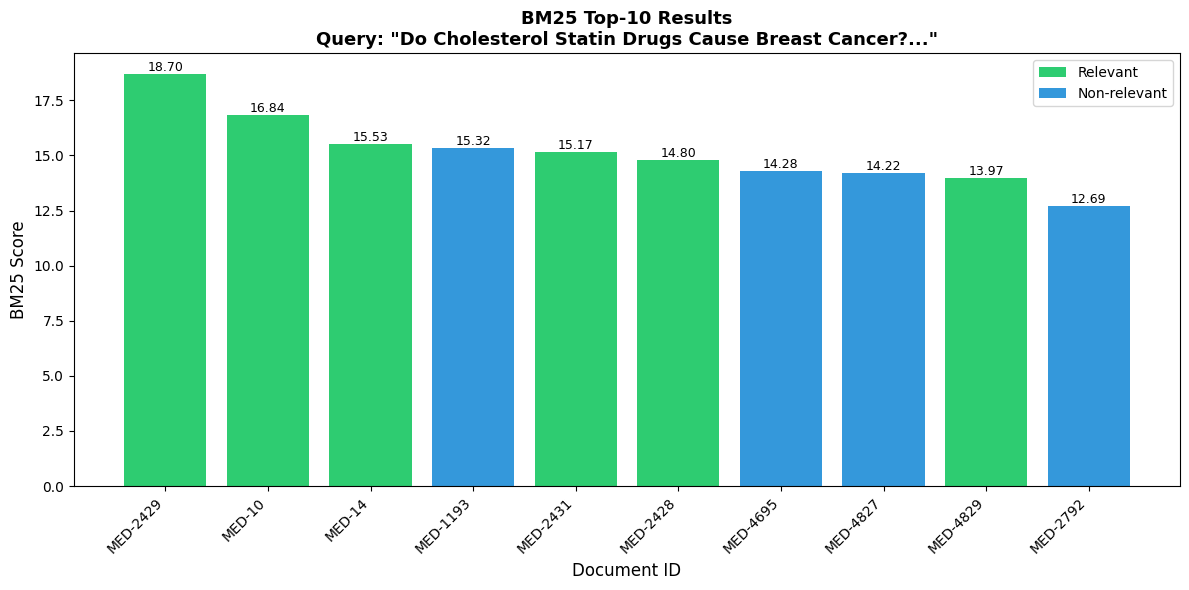

---

<h3 style="color: #0366d6; margin-top: 20px;">Part B: Bi-Encoder Dense Retrieval</h3>

<blockquote style="background-color: #ffeef0; border-left: 5px solid #f85149; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Implementation:</strong> Used <code>sentence-transformers/msmarco-distilbert-base-tas-b</code>. Documents were pre-encoded into dense vectors. Retrieval was performed using Cosine Similarity.
</blockquote>

**Results Analysis:**
*   The Bi-Encoder retrieved relevant documents with high similarity scores (~0.82).
*   It captures **semantic meaning**. For example, it identified **MED-2439** ("Plant Sterols as Anticancer Nutrients") as relevant, even if the keyword overlap isn't perfect, because the model understands the semantic relationship between "Cholesterol" and "Sterols" in a medical context.

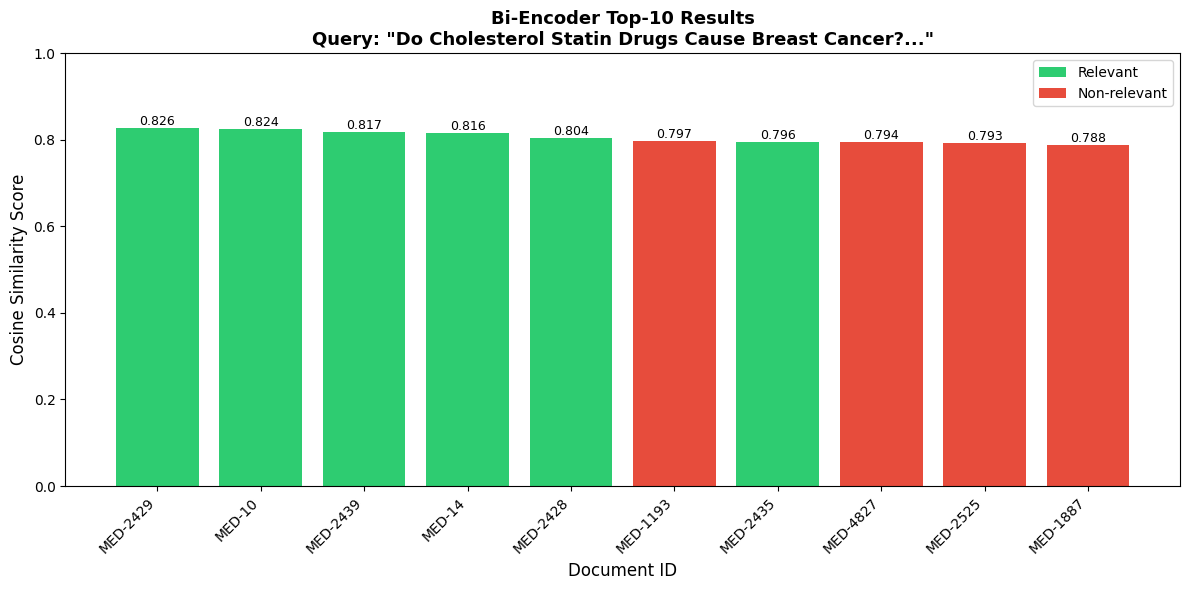

#### 📝 Theoretical Analysis: Bi-Encoders vs. Cross-Encoders

**1. Fundamental Architectural Difference:**
*   **Bi-Encoder (Siamese Network):** Processes the Query and the Document **independently**. It passes the query through BERT to get vector $u$ and the document through BERT to get vector $v$. The score is computed as a dot product or cosine similarity: $Score = \cos(u, v)$. There is no interaction between query tokens and document tokens inside the neural network.
*   **Cross-Encoder:** Processes the Query and Document **simultaneously** as a single input pair: `[CLS] Query [SEP] Document`. The self-attention mechanism allows every token in the query to interact with every token in the document. The score is output by a classification layer on top of the `[CLS]` token.

**2. Why can Bi-Encoders pre-compute embeddings?**
*   Because the document representation $v$ depends *only* on the document text, not on the query. Therefore, we can encode all 3,633 documents once (offline) and store the vectors. During retrieval, we only encode the new query.
*   **Cross-Encoders cannot pre-compute** because the input to the network requires *both* the query and the document. The representation changes for every unique query-document pair.

**3. Computational Complexity (Retrieving from $N$ documents):**
*   **Bi-Encoder:** $O(N)$ for similarity calculation (or $O(\log N)$ with ANN indexing like Faiss). It is extremely fast for retrieval.
*   **Cross-Encoder:** $O(N \times T_{BERT})$, where $T_{BERT}$ is the time to run a full BERT forward pass. For millions of documents, this is computationally infeasible for real-time retrieval.

---

<h3 style="color: #0366d6; margin-top: 20px;">Part C: Cross-Encoder Reranking Pipeline</h3>

<blockquote style="background-color: #f6f8fa; border-left: 5px solid #24292e; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Implementation:</strong> A Two-Stage Pipeline.
  <br><strong>Stage 1:</strong> Bi-Encoder retrieves top-100 candidates.
  <br><strong>Stage 2:</strong> <code>cross-encoder/ms-marco-MiniLM-L-6-v2</code> reranks these 100 candidates.
</blockquote>

**Results Analysis:**
*   The Cross-Encoder effectively filters the list. Notice the negative scores for non-relevant documents (e.g., MED-1193: -2.37).
*   It distinguishes between documents that *mention* the keywords but discuss a different relation (e.g., "The effects of lowering LDL...") vs. documents that directly address the *causal link* requested in the query.
*   **Top Result:** MED-14 (Score: 4.55) is strongly relevant.

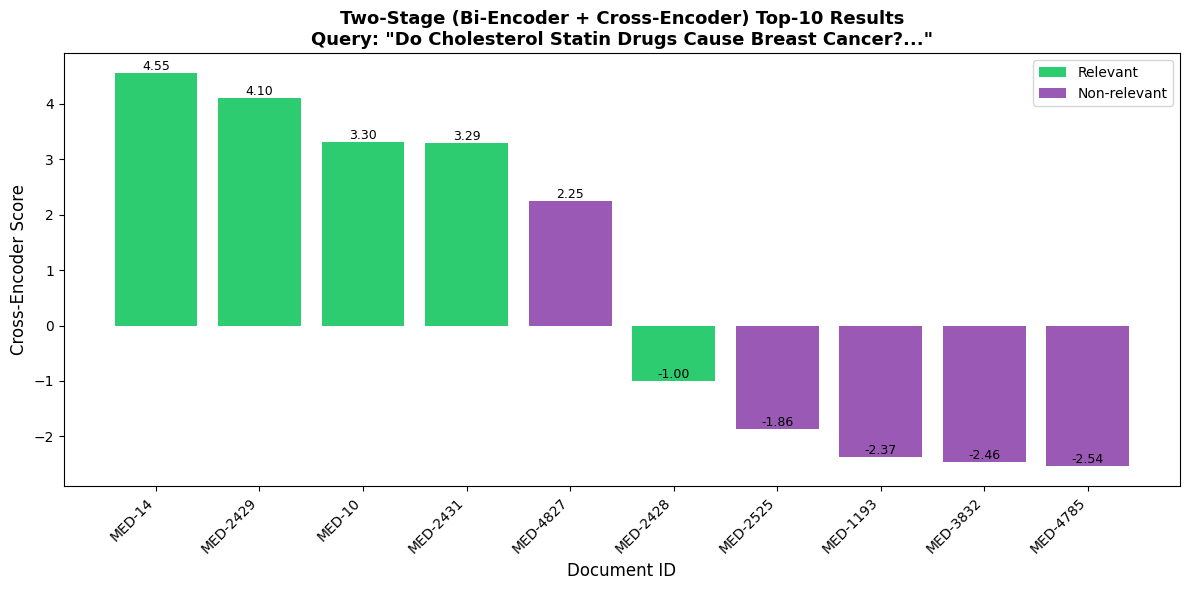

#### 📝 Theoretical Analysis: Two-Stage Pipeline

**Why use a Two-Stage Pipeline (Bi-Encoder + Cross-Encoder) instead of just a Cross-Encoder?**

1.  **Efficiency (Latency):**
    *   Running a Cross-Encoder on the entire corpus (e.g., millions of docs) for every query would take minutes or hours. A Bi-Encoder (or BM25) acts as a fast filter to reduce the search space from $N$ (millions) to $k$ (e.g., 100).
    *   The Cross-Encoder then only needs to process $k$ pairs, which takes milliseconds.

2.  **Accuracy (Precision vs. Recall):**
    *   **Stage 1 (Bi-Encoder):** Optimizes for **Recall**. Its job is to ensure the relevant documents are *somewhere* in the top-100, even if the ranking isn't perfect.
    *   **Stage 2 (Cross-Encoder):** Optimizes for **Precision**. Because it uses full self-attention, it understands complex grammar, negation, and nuance better than the Bi-Encoder. It brings the true relevant docs to the top of the list (Rank 1-10).

**Conclusion:** The pipeline achieves the "best of both worlds": the **speed** of the Bi-Encoder and the **accuracy** of the Cross-Encoder.

</div>

## Section 3: Fine-Tuning with Full Training

### A: Data Preparation - Training Triplets

In [ ]:
print("\n" + "-" * 40)
print("Section 3a: Data Preparation")
print("-" * 40)

def create_training_triplets(queries: Dict[str, str],
                             qrels: Dict[str, Dict[str, int]],
                             corpus: Dict[str, Dict],
                             bm25_retriever: BM25Retriever,
                             num_hard_negatives: int = 1,
                             num_random_negatives: int = 2,
                             bm25_top_k: int = 50,
                             max_positives_per_query: int = 3) -> List[InputExample]:
    """
    Create training triplets for contrastive learning.

    For each query:
    - Positive: Relevant document from qrels (relevance > 0)
    - Hard Negative: Top BM25 result that is not relevant
    - Random Negative: Random document from corpus

    Args:
        queries: Query dictionary
        qrels: Relevance judgments
        corpus: Document corpus
        bm25_retriever: BM25 retriever for hard negative mining
        num_hard_negatives: Number of hard negatives per positive
        num_random_negatives: Number of random negatives per positive
        bm25_top_k: Number of BM25 results to consider for hard negatives
        max_positives_per_query: Maximum number of positive documents per query

    Returns:
        List of InputExample objects for training
    """
    training_examples = []
    all_doc_ids = list(corpus.keys())

    print("Creating training triplets...")
    for qid in tqdm(qrels.keys(), desc="Processing queries"):
        if qid not in queries:
            continue

        query_text = queries[qid]
        relevant_docs = {doc_id for doc_id, score in qrels[qid].items() if score > 0}

        if not relevant_docs:
            continue

        # Limit to max_positives_per_query positive documents
        relevant_docs_list = list(relevant_docs)
        if len(relevant_docs_list) > max_positives_per_query:
            relevant_docs_list = random.sample(relevant_docs_list, max_positives_per_query)

        # Get BM25 results for hard negative mining
        bm25_results = bm25_retriever.retrieve(query_text, top_k=bm25_top_k)
        hard_negative_candidates = [
            doc_id for doc_id, _ in bm25_results
            if doc_id not in relevant_docs
        ]

        # For each positive document
        for pos_doc_id in relevant_docs_list:
            pos_text = f"{corpus[pos_doc_id]['title']} {corpus[pos_doc_id]['text']}"

            # Add hard negatives
            for i in range(min(num_hard_negatives, len(hard_negative_candidates))):
                neg_doc_id = hard_negative_candidates[i]
                neg_text = f"{corpus[neg_doc_id]['title']} {corpus[neg_doc_id]['text']}"

                training_examples.append(InputExample(
                    texts=[query_text, pos_text, neg_text]
                ))

            # Add random negatives
            random_negatives = random.sample(
                [d for d in all_doc_ids if d not in relevant_docs],
                min(num_random_negatives, len(all_doc_ids) - len(relevant_docs))
            )

            for neg_doc_id in random_negatives:
                neg_text = f"{corpus[neg_doc_id]['title']} {corpus[neg_doc_id]['text']}"

                training_examples.append(InputExample(
                    texts=[query_text, pos_text, neg_text]
                ))

    print(f"Created {len(training_examples)} training triplets")
    return training_examples

# Create training triplets
training_examples = create_training_triplets(
    queries=queries,
    qrels=qrels_train,
    corpus=corpus,
    bm25_retriever=bm25_retriever,
    num_hard_negatives=1,
    num_random_negatives=2,
    bm25_top_k=50,
    max_positives_per_query=3
)

# Visualize training data statistics
print("\nTraining Data Statistics:")
print(f"Total training examples: {len(training_examples)}")
print(f"Unique training queries: {len(qrels_train)}")


----------------------------------------
Section 3a: Data Preparation
----------------------------------------
Creating training triplets...


Processing queries: 100%|██████████| 2590/2590 [00:06<00:00, 385.91it/s]

Created 21759 training triplets

Training Data Statistics:
Total training examples: 21759
Unique training queries: 2590


### B: Full Fine-Tuning


----------------------------------------
Section 3b: Full Fine-Tuning
----------------------------------------
Loading base model: sentence-transformers/all-MiniLM-L6-v2

Training Configuration:
  - Total training examples: 21759
  - Batch size: 16
  - Number of epochs: 3
  - Total steps: 4080
  - Warmup steps: 408
  - Learning rate: 2e-05

Starting fine-tuning...


Step,Training Loss
500,2.944100
1000,2.545000
1500,2.170700
2000,1.875800
2500,1.721400
3000,1.511500
3500,1.356700
4000,1.320800


Model saved to: ./fine_tuned_full_model
Encoding documents with bi-encoder...


Batches: 100%|██████████| 114/114 [00:01<00:00, 73.92it/s]


Indexed 3633 documents with embedding dimension 384

Sample query: 'Do Cholesterol Statin Drugs Cause Breast Cancer?'

Top-10 Fine-Tuned Bi-Encoder results:
  1. [✓] MED-2439: 0.5230 - Plant Sterols as Anticancer Nutrients: Evidence for Their Ro...
  2. [✓] MED-2429: 0.5183 - Statin use and risk of breast cancer: a meta-analysis of obs...
  3. [ ] MED-4827: 0.5181 - Men with Low Serum Cholesterol Have a Lower Risk of High-Gra...
  4. [✓] MED-2428: 0.4911 - Women and statin use: a women's health advocacy perspective....
  5. [ ] MED-1765: 0.4420 - Effects of simvastatin and pravastatin on gonadal function i...
  6. [✓] MED-2440: 0.4403 - Total Cholesterol and Cancer Risk in a Large Prospective Stu...
  7. [ ] MED-2525: 0.4335 - A global survey of physicians' perceptions on cholesterol ma...
  8. [ ] MED-3845: 0.4326 - Serum enterolactone levels and mortality outcome in women wi...
  9. [✓] MED-14: 0.4284 - Statin use after diagnosis of breast cancer and survival: a ...
  10. [ ] MED-456

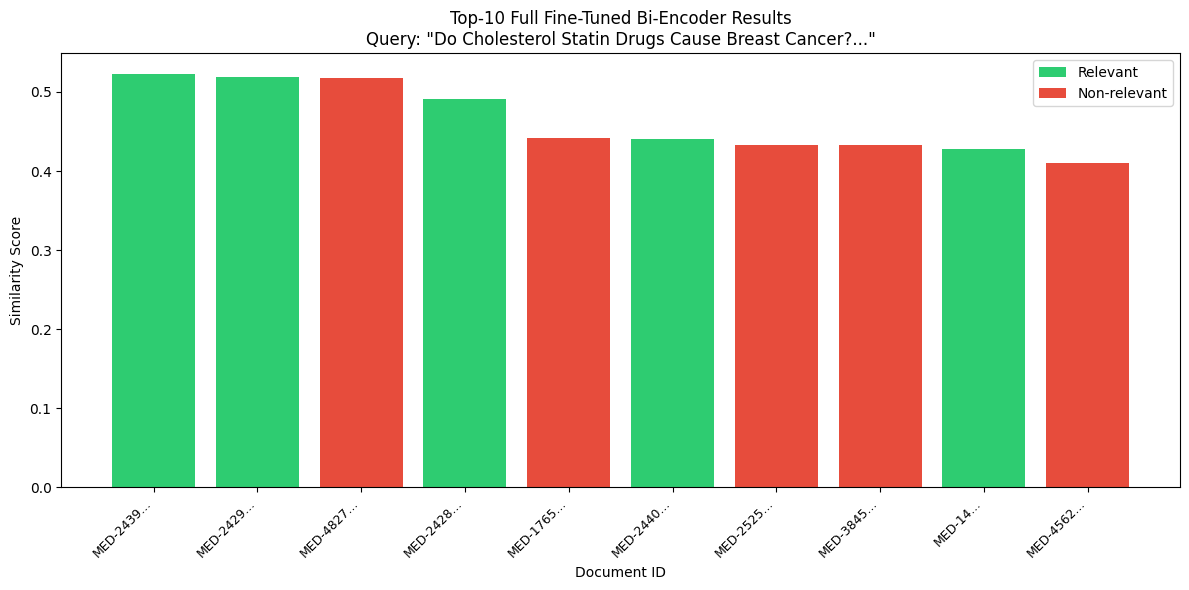

Saved: fine_tuned_top10_results.png


In [ ]:
print("\n" + "-" * 40)
print("Section 3b: Full Fine-Tuning")
print("-" * 40)

def fine_tune_bi_encoder(training_examples: List[InputExample],
                         model_name: str = 'sentence-transformers/all-MiniLM-L6-v2',
                         output_path: str = './fine_tuned_model',
                         num_epochs: int = 3,
                         batch_size: int = 16,
                         learning_rate: float = 2e-5,
                         warmup_ratio: float = 0.1) -> SentenceTransformer:
    """
    Fine-tune a bi-encoder model using MultipleNegativesRankingLoss.

    Args:
        training_examples: List of InputExample triplets
        model_name: Base model to fine-tune
        output_path: Path to save fine-tuned model
        num_epochs: Number of training epochs
        batch_size: Training batch size
        learning_rate: Learning rate
        warmup_ratio: Ratio of warmup steps

    Returns:
        Fine-tuned SentenceTransformer model
    """
    print(f"Loading base model: {model_name}")
    model = SentenceTransformer(model_name, device=DEVICE)

    # Create DataLoader
    train_dataloader = DataLoader(
        training_examples,
        shuffle=True,
        batch_size=batch_size
    )

    # Define loss function
    train_loss = losses.MultipleNegativesRankingLoss(model)

    # Calculate warmup steps
    total_steps = len(train_dataloader) * num_epochs
    warmup_steps = int(total_steps * warmup_ratio)

    print(f"\nTraining Configuration:")
    print(f"  - Total training examples: {len(training_examples)}")
    print(f"  - Batch size: {batch_size}")
    print(f"  - Number of epochs: {num_epochs}")
    print(f"  - Total steps: {total_steps}")
    print(f"  - Warmup steps: {warmup_steps}")
    print(f"  - Learning rate: {learning_rate}")

    # Fine-tune the model
    print("\nStarting fine-tuning...")
    model.fit(
        train_objectives=[(train_dataloader, train_loss)],
        epochs=num_epochs,
        warmup_steps=warmup_steps,
        optimizer_params={'lr': learning_rate},
        output_path=output_path,
        show_progress_bar=True,
        checkpoint_path=output_path,
        checkpoint_save_steps=len(train_dataloader),  # Save at end of each epoch
        use_amp=True if DEVICE.type == 'cuda' else False
    )

    print(f"Model saved to: {output_path}")
    return model

# Fine-tune the model
fine_tuned_model = fine_tune_bi_encoder(
    training_examples=training_examples,
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    output_path='./fine_tuned_full_model',
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1
)

# Create retriever with fine-tuned model
class FineTunedBiEncoderRetriever(BiEncoderRetriever):
    """Bi-encoder retriever using fine-tuned model."""

    def __init__(self, model: SentenceTransformer):
        self.model = model
        self.doc_ids = None
        self.doc_embeddings = None
        self.model_name = "fine_tuned_full"

# Initialize fine-tuned retriever
fine_tuned_retriever = FineTunedBiEncoderRetriever(fine_tuned_model)
fine_tuned_retriever.index(doc_ids, doc_texts, batch_size=32)

# Test fine-tuned retrieval
print(f"\nSample query: '{sample_query}'")
print("\nTop-10 Fine-Tuned Bi-Encoder results:")
fine_tuned_results = fine_tuned_retriever.retrieve(sample_query, top_k=10)
for rank, (doc_id, score) in enumerate(fine_tuned_results, 1):
    is_relevant = "✓" if qrels_test.get(sample_query_id, {}).get(doc_id, 0) > 0 else " "
    print(f"  {rank}. [{is_relevant}] {doc_id}: {score:.4f} - {corpus[doc_id]['title'][:60]}...")

# Visualize Top-10 Fine-Tuned results
fig, ax = plt.subplots(figsize=(12, 6))
doc_labels = [f"{doc_id[:12]}..." for doc_id, _ in fine_tuned_results]
scores = [score for _, score in fine_tuned_results]
relevance_colors = ['#2ecc71' if qrels_test.get(sample_query_id, {}).get(doc_id, 0) > 0 else '#e74c3c'
                    for doc_id, _ in fine_tuned_results]

bars = ax.bar(range(len(doc_labels)), scores, color=relevance_colors)
ax.set_xticks(range(len(doc_labels)))
ax.set_xticklabels(doc_labels, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Document ID')
ax.set_ylabel('Similarity Score')
ax.set_title(f'Top-10 Full Fine-Tuned Bi-Encoder Results\nQuery: "{sample_query[:50]}..."')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Relevant'),
                   Patch(facecolor='#e74c3c', label='Non-relevant')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('fine_tuned_top10_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fine_tuned_top10_results.png")

## Section 4: Parameter-Efficient Fine-Tuning (LoRA)

In [ ]:
print("\n" + "=" * 80)
print("SECTION 4: PARAMETER-EFFICIENT FINE-TUNING (LoRA)")
print("=" * 80)

from peft import LoraConfig, get_peft_model, TaskType
from transformers import AutoModelForSequenceClassification


SECTION 4: PARAMETER-EFFICIENT FINE-TUNING (LoRA)


### A: LoRA Implementation



----------------------------------------
Section 4a: LoRA Implementation
----------------------------------------
Loading base model: sentence-transformers/all-MiniLM-L6-v2
Applying LoRA adapters...

LoRA Parameter Statistics:
  - Total parameters: 22,786,944
  - Trainable parameters: 73,728
  - Trainable %: 0.32%

LoRA Training Configuration:
  - LoRA rank (r): 8
  - LoRA alpha: 16
  - Target modules: query, key
  - Total steps: 4080
  - Warmup steps: 408

Starting LoRA fine-tuning...


Step,Training Loss
500,3.505200
1000,3.340200
1500,3.264900
2000,3.258900
2500,3.198200
3000,3.176500
3500,3.181300
4000,3.132700


LoRA model saved to: ./lora_fine_tuned_model
Encoding documents with bi-encoder...


Batches: 100%|██████████| 114/114 [00:01<00:00, 65.40it/s]


Indexed 3633 documents with embedding dimension 384

Sample query: 'Do Cholesterol Statin Drugs Cause Breast Cancer?'

Top-10 LoRA Fine-Tuned results:
  1. [✓] MED-2429: 0.4975 - Statin use and risk of breast cancer: a meta-analysis of obs...
  2. [ ] MED-4827: 0.4653 - Men with Low Serum Cholesterol Have a Lower Risk of High-Gra...
  3. [✓] MED-10: 0.4537 - Statin Use and Breast Cancer Survival: A Nationwide Cohort S...
  4. [✓] MED-4559: 0.4534 - Can a statin neutralize the cardiovascular risk of unhealthy...
  5. [✓] MED-14: 0.4490 - Statin use after diagnosis of breast cancer and survival: a ...
  6. [✓] MED-2431: 0.4476 - Long-term statin use and risk of ductal and lobular breast c...
  7. [✓] MED-2439: 0.4386 - Plant Sterols as Anticancer Nutrients: Evidence for Their Ro...
  8. [✓] MED-2440: 0.4234 - Total Cholesterol and Cancer Risk in a Large Prospective Stu...
  9. [✓] MED-2428: 0.4179 - Women and statin use: a women's health advocacy perspective....
  10. [ ] MED-2137: 0.403

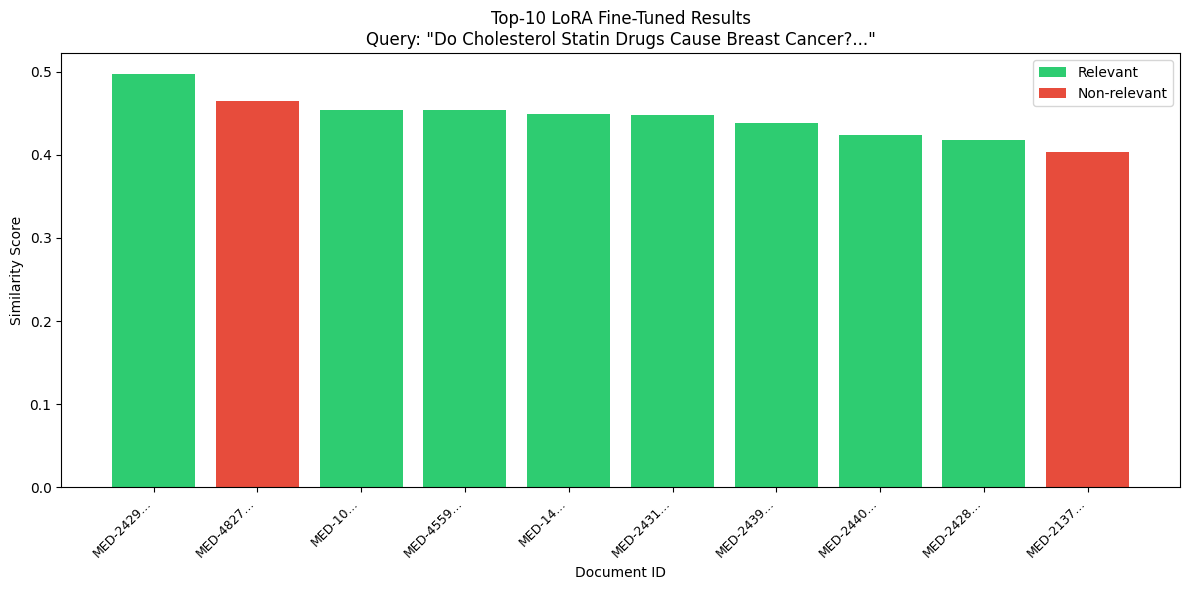

Saved: lora_top10_results.png

----------------------------------------
Parameter Comparison: Full Fine-Tuning vs LoRA
----------------------------------------

Full Fine-Tuning:
  - Total parameters: 22,713,216
  - Trainable parameters: 22,713,216

LoRA Fine-Tuning:
  - Total parameters: 22,786,944
  - Trainable parameters: 73,728
  - Parameter reduction: 99.68%


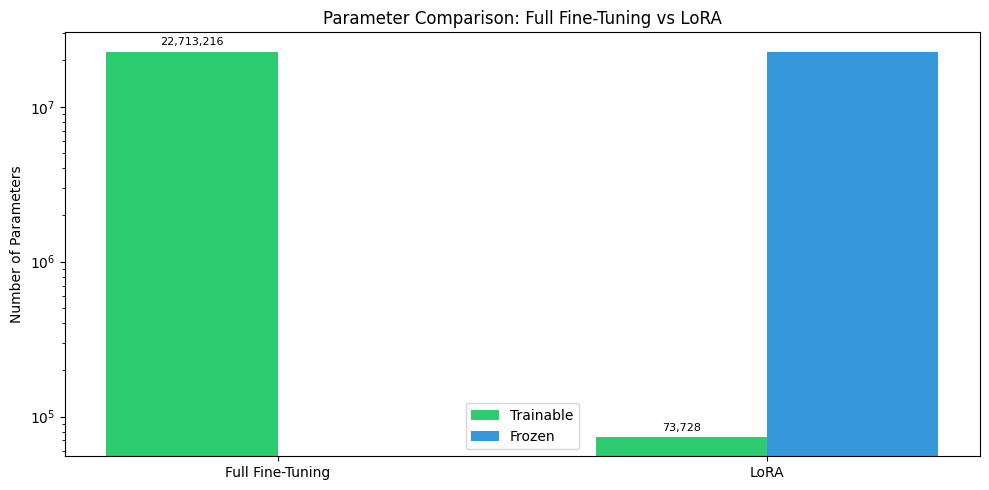

Saved: parameter_comparison.png


In [ ]:
print("\n" + "-" * 40)
print("Section 4a: LoRA Implementation")
print("-" * 40)

class LoRABiEncoderTrainer:
    """
    Trainer for bi-encoder with LoRA (Low-Rank Adaptation).

    LoRA adds trainable low-rank matrices to attention layers,
    enabling efficient fine-tuning with minimal parameters.
    """

    def __init__(self, model_name: str = 'sentence-transformers/all-MiniLM-L6-v2',
                 lora_r: int = 8, lora_alpha: int = 16,
                 target_modules: List[str] = ['query', 'key']):
        """
        Initialize LoRA trainer.

        Args:
            model_name: Base model name
            lora_r: LoRA rank
            lora_alpha: LoRA alpha scaling factor
            target_modules: Modules to apply LoRA to
        """
        self.model_name = model_name
        self.lora_r = lora_r
        self.lora_alpha = lora_alpha
        self.target_modules = target_modules

        # Load base model
        print(f"Loading base model: {model_name}")
        self.base_model = SentenceTransformer(model_name, device=DEVICE)

        # Get the transformer model from SentenceTransformer
        self.transformer = self.base_model[0].auto_model

        # Configure LoRA
        self.lora_config = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            target_modules=target_modules,
            lora_dropout=0.1,
            bias="none",
            task_type=TaskType.FEATURE_EXTRACTION
        )

        # Apply LoRA
        print("Applying LoRA adapters...")
        self.peft_model = get_peft_model(self.transformer, self.lora_config)

        # Print trainable parameters
        self.print_trainable_parameters()

    def print_trainable_parameters(self):
        """Print the number of trainable parameters."""
        trainable_params = 0
        all_params = 0
        for _, param in self.peft_model.named_parameters():
            all_params += param.numel()
            if param.requires_grad:
                trainable_params += param.numel()

        print(f"\nLoRA Parameter Statistics:")
        print(f"  - Total parameters: {all_params:,}")
        print(f"  - Trainable parameters: {trainable_params:,}")
        print(f"  - Trainable %: {100 * trainable_params / all_params:.2f}%")

        self.total_params = all_params
        self.trainable_params = trainable_params

    def get_sentence_transformer(self) -> SentenceTransformer:
        """Get SentenceTransformer with LoRA-adapted model."""
        # Replace the transformer in the SentenceTransformer
        self.base_model[0].auto_model = self.peft_model
        return self.base_model

def train_lora_model(training_examples: List[InputExample],
                     output_path: str = './lora_fine_tuned_model',
                     num_epochs: int = 3,
                     batch_size: int = 16,
                     learning_rate: float = 2e-5,
                     warmup_ratio: float = 0.1) -> SentenceTransformer:
    """
    Train a bi-encoder with LoRA adapters.

    Args:
        training_examples: Training triplets
        output_path: Path to save model
        num_epochs: Number of epochs
        batch_size: Batch size
        learning_rate: Learning rate
        warmup_ratio: Warmup ratio

    Returns:
        Fine-tuned SentenceTransformer with LoRA
    """
    # Initialize LoRA trainer
    lora_trainer = LoRABiEncoderTrainer(
        model_name='sentence-transformers/all-MiniLM-L6-v2',
        lora_r=8,
        lora_alpha=16,
        target_modules=['query', 'key']
    )

    # Get the model
    model = lora_trainer.get_sentence_transformer()

    # Create DataLoader
    train_dataloader = DataLoader(
        training_examples,
        shuffle=True,
        batch_size=batch_size
    )

    # Define loss
    train_loss = losses.MultipleNegativesRankingLoss(model)

    # Calculate warmup steps
    total_steps = len(train_dataloader) * num_epochs
    warmup_steps = int(total_steps * warmup_ratio)

    print(f"\nLoRA Training Configuration:")
    print(f"  - LoRA rank (r): 8")
    print(f"  - LoRA alpha: 16")
    print(f"  - Target modules: query, key")
    print(f"  - Total steps: {total_steps}")
    print(f"  - Warmup steps: {warmup_steps}")

    # Train
    print("\nStarting LoRA fine-tuning...")
    model.fit(
        train_objectives=[(train_dataloader, train_loss)],
        epochs=num_epochs,
        warmup_steps=warmup_steps,
        optimizer_params={'lr': learning_rate},
        output_path=output_path,
        show_progress_bar=True,
        checkpoint_path=output_path,
        checkpoint_save_steps=len(train_dataloader),
        use_amp=True if DEVICE.type == 'cuda' else False
    )

    print(f"LoRA model saved to: {output_path}")
    return model, lora_trainer.trainable_params, lora_trainer.total_params

# Train LoRA model
lora_model, lora_trainable, lora_total = train_lora_model(
    training_examples=training_examples,
    output_path='./lora_fine_tuned_model',
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1
)

# Create LoRA retriever
lora_retriever = FineTunedBiEncoderRetriever(lora_model)
lora_retriever.model_name = "lora_fine_tuned"
lora_retriever.index(doc_ids, doc_texts, batch_size=32)

# Test LoRA retrieval
print(f"\nSample query: '{sample_query}'")
print("\nTop-10 LoRA Fine-Tuned results:")
lora_results = lora_retriever.retrieve(sample_query, top_k=10)
for rank, (doc_id, score) in enumerate(lora_results, 1):
    is_relevant = "✓" if qrels_test.get(sample_query_id, {}).get(doc_id, 0) > 0 else " "
    print(f"  {rank}. [{is_relevant}] {doc_id}: {score:.4f} - {corpus[doc_id]['title'][:60]}...")

# Visualize Top-10 LoRA results
fig, ax = plt.subplots(figsize=(12, 6))
doc_labels = [f"{doc_id[:12]}..." for doc_id, _ in lora_results]
scores = [score for _, score in lora_results]
relevance_colors = ['#2ecc71' if qrels_test.get(sample_query_id, {}).get(doc_id, 0) > 0 else '#e74c3c'
                    for doc_id, _ in lora_results]

bars = ax.bar(range(len(doc_labels)), scores, color=relevance_colors)
ax.set_xticks(range(len(doc_labels)))
ax.set_xticklabels(doc_labels, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Document ID')
ax.set_ylabel('Similarity Score')
ax.set_title(f'Top-10 LoRA Fine-Tuned Results\nQuery: "{sample_query[:50]}..."')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Relevant'),
                   Patch(facecolor='#e74c3c', label='Non-relevant')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('lora_top10_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lora_top10_results.png")

# Compare parameters
print("\n" + "-" * 40)
print("Parameter Comparison: Full Fine-Tuning vs LoRA")
print("-" * 40)

# Get full model parameters
full_model_params = sum(p.numel() for p in fine_tuned_model.parameters())
full_trainable_params = sum(p.numel() for p in fine_tuned_model.parameters() if p.requires_grad)

print(f"\nFull Fine-Tuning:")
print(f"  - Total parameters: {full_model_params:,}")
print(f"  - Trainable parameters: {full_trainable_params:,}")

print(f"\nLoRA Fine-Tuning:")
print(f"  - Total parameters: {lora_total:,}")
print(f"  - Trainable parameters: {lora_trainable:,}")
print(f"  - Parameter reduction: {(1 - lora_trainable/full_trainable_params)*100:.2f}%")

# Visualize parameter comparison
fig, ax = plt.subplots(figsize=(10, 5))
methods = ['Full Fine-Tuning', 'LoRA']
trainable = [full_trainable_params, lora_trainable]
non_trainable = [full_model_params - full_trainable_params, lora_total - lora_trainable]

x = np.arange(len(methods))
width = 0.35

bars1 = ax.bar(x - width/2, trainable, width, label='Trainable', color='#2ecc71')
bars2 = ax.bar(x + width/2, non_trainable, width, label='Frozen', color='#3498db')

ax.set_ylabel('Number of Parameters')
ax.set_title('Parameter Comparison: Full Fine-Tuning vs LoRA')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.set_yscale('log')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:,.0f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('parameter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: parameter_comparison.png")

## Section 5: Comprehensive Evaluation


SECTION 5: COMPREHENSIVE EVALUATION

Evaluating on 323 test queries

----------------------------------------
Evaluating Baseline Methods
----------------------------------------

Evaluating: BM25


BM25 Retrieval: 100%|██████████| 323/323 [00:00<00:00, 396.03it/s]


  MRR@10: 0.4667
  NDCG@10: 0.2689
  Recall@10: 0.1243
  Recall@100: 0.2091
  Precision@10: 0.1941
  Mean Latency: 2.53 ms/query

Evaluating: Pre-trained Bi-Encoder
Encoding queries...


Batches: 100%|██████████| 11/11 [00:00<00:00, 34.46it/s]


Computing similarities...


...


----------------------------------------
Table 2: Fine-Tuned Methods Comparison
----------------------------------------


,MRR@10,NDCG@10,Recall@10,Recall@100,Precision@10,Latency (ms)
name,,,,,,
Full Fine-Tuning,0.504390,0.310673,0.150589,0.351613,0.253251,1.978239
LoRA Fine-Tuning,0.449107,0.269275,0.130874,0.279205,0.211146,1.995249



----------------------------------------
Table 3: All Methods Comparison
----------------------------------------


,MRR@10,NDCG@10,Recall@10,Recall@100,Precision@10,Latency (ms)
name,,,,,,
BM25,0.466691,0.268934,0.124311,0.209122,0.194118,2.529766
Pre-trained Bi-Encoder,0.471931,0.275157,0.132656,0.249130,0.200310,2.872626
Two-Stage (Bi+Cross),0.566003,0.338390,0.151139,0.249130,0.232817,305.892577
Full Fine-Tuning,0.504390,0.310673,0.150589,0.351613,0.253251,1.978239
LoRA Fine-Tuning,0.449107,0.269275,0.130874,0.279205,0.211146,1.995249



Saved: baseline_results.csv, finetuned_results.csv, all_results.csv


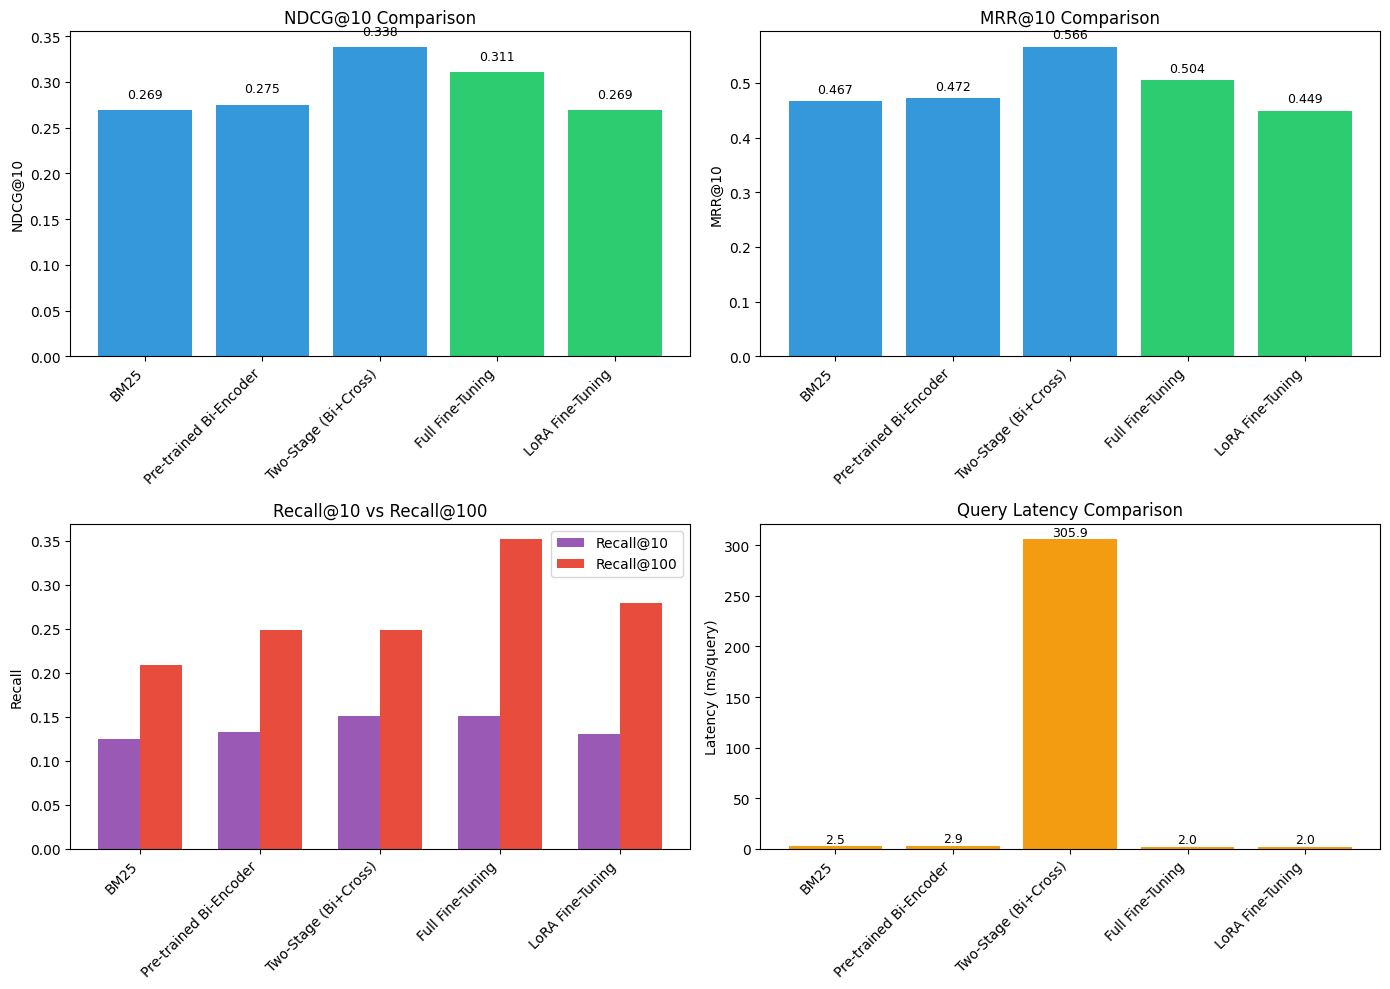

Saved: evaluation_comparison.png


In [ ]:
print("\n" + "=" * 80)
print("SECTION 5: COMPREHENSIVE EVALUATION")
print("=" * 80)

# Evaluation Metrics Implementation

def compute_mrr(results: Dict[str, List[Tuple[str, float]]],
                qrels: Dict[str, Dict[str, int]],
                k: int = 10) -> float:
    """
    Compute Mean Reciprocal Rank at k.

    MRR@k = (1/|Q|) * Σ (1/rank_i) for first relevant document
    """
    mrr_sum = 0.0
    num_queries = 0

    for qid, ranked_docs in results.items():
        if qid not in qrels:
            continue

        relevant_docs = {doc_id for doc_id, score in qrels[qid].items() if score > 0}

        for rank, (doc_id, _) in enumerate(ranked_docs[:k], 1):
            if doc_id in relevant_docs:
                mrr_sum += 1.0 / rank
                break

        num_queries += 1

    return mrr_sum / num_queries if num_queries > 0 else 0.0

def compute_ndcg(results: Dict[str, List[Tuple[str, float]]],
                 qrels: Dict[str, Dict[str, int]],
                 k: int = 10) -> float:
    """
    Compute Normalized Discounted Cumulative Gain at k.

    DCG@k = Σ (2^rel_i - 1) / log2(i + 1)
    NDCG@k = DCG@k / IDCG@k
    """
    ndcg_sum = 0.0
    num_queries = 0

    for qid, ranked_docs in results.items():
        if qid not in qrels:
            continue

        # Get relevance scores
        relevances = []
        for doc_id, _ in ranked_docs[:k]:
            rel = qrels[qid].get(doc_id, 0)
            relevances.append(rel)

        # Compute DCG
        dcg = sum(
            (2**rel - 1) / np.log2(i + 2)
            for i, rel in enumerate(relevances)
        )

        # Compute IDCG (ideal DCG)
        ideal_relevances = sorted(qrels[qid].values(), reverse=True)[:k]
        idcg = sum(
            (2**rel - 1) / np.log2(i + 2)
            for i, rel in enumerate(ideal_relevances)
        )

        if idcg > 0:
            ndcg_sum += dcg / idcg

        num_queries += 1

    return ndcg_sum / num_queries if num_queries > 0 else 0.0

def compute_recall(results: Dict[str, List[Tuple[str, float]]],
                   qrels: Dict[str, Dict[str, int]],
                   k: int = 10) -> float:
    """
    Compute Recall at k.

    Recall@k = |relevant ∩ retrieved@k| / |relevant|
    """
    recall_sum = 0.0
    num_queries = 0

    for qid, ranked_docs in results.items():
        if qid not in qrels:
            continue

        relevant_docs = {doc_id for doc_id, score in qrels[qid].items() if score > 0}

        if not relevant_docs:
            continue

        retrieved_docs = {doc_id for doc_id, _ in ranked_docs[:k]}

        recall = len(relevant_docs & retrieved_docs) / len(relevant_docs)
        recall_sum += recall
        num_queries += 1

    return recall_sum / num_queries if num_queries > 0 else 0.0

def compute_precision(results: Dict[str, List[Tuple[str, float]]],
                      qrels: Dict[str, Dict[str, int]],
                      k: int = 10) -> float:
    """
    Compute Precision at k.

    Precision@k = |relevant ∩ retrieved@k| / k
    """
    precision_sum = 0.0
    num_queries = 0

    for qid, ranked_docs in results.items():
        if qid not in qrels:
            continue

        relevant_docs = {doc_id for doc_id, score in qrels[qid].items() if score > 0}
        retrieved_docs = {doc_id for doc_id, _ in ranked_docs[:k]}

        precision = len(relevant_docs & retrieved_docs) / k
        precision_sum += precision
        num_queries += 1

    return precision_sum / num_queries if num_queries > 0 else 0.0

def evaluate_retriever(retriever, queries: Dict[str, str],
                       qrels: Dict[str, Dict[str, int]],
                       name: str, top_k: int = 100) -> Dict:
    """
    Comprehensive evaluation of a retrieval system.

    Args:
        retriever: Retrieval system with retrieve_batch method
        queries: Query dictionary
        qrels: Relevance judgments
        name: Name of the retriever for logging
        top_k: Number of documents to retrieve

    Returns:
        Dictionary with all metrics
    """
    print(f"\nEvaluating: {name}")

    # Measure latency
    start_time = time.time()

    if hasattr(retriever, 'retrieve_batch'):
        # Check if it's a TwoStageRetriever (has first_stage_k parameter)
        if isinstance(retriever, TwoStageRetriever):
            results = retriever.retrieve_batch(queries, first_stage_k=top_k, final_k=top_k)
        else:
            results = retriever.retrieve_batch(queries, top_k=top_k)
    else:
        results = {}
        for qid, query_text in tqdm(queries.items(), desc="Retrieving"):
            results[qid] = retriever.retrieve(query_text, top_k=top_k)

    total_time = time.time() - start_time
    mean_latency = (total_time / len(queries)) * 1000  # ms per query

    # Compute metrics
    metrics = {
        'name': name,
        'MRR@10': compute_mrr(results, qrels, k=10),
        'NDCG@10': compute_ndcg(results, qrels, k=10),
        'Recall@10': compute_recall(results, qrels, k=10),
        'Recall@100': compute_recall(results, qrels, k=100),
        'Precision@10': compute_precision(results, qrels, k=10),
        'Latency (ms)': mean_latency
    }

    print(f"  MRR@10: {metrics['MRR@10']:.4f}")
    print(f"  NDCG@10: {metrics['NDCG@10']:.4f}")
    print(f"  Recall@10: {metrics['Recall@10']:.4f}")
    print(f"  Recall@100: {metrics['Recall@100']:.4f}")
    print(f"  Precision@10: {metrics['Precision@10']:.4f}")
    print(f"  Mean Latency: {metrics['Latency (ms)']:.2f} ms/query")

    return metrics, results

# Filter test queries that exist in the queries dictionary
test_queries = {qid: queries[qid] for qid in qrels_test.keys() if qid in queries}
print(f"\nEvaluating on {len(test_queries)} test queries")

# Evaluate all baseline methods
print("\n" + "-" * 40)
print("Evaluating Baseline Methods")
print("-" * 40)

baseline_results = []

# BM25
bm25_metrics, bm25_test_results = evaluate_retriever(
    bm25_retriever, test_queries, qrels_test, "BM25", top_k=100
)
baseline_results.append(bm25_metrics)

# Pre-trained Bi-Encoder
bi_encoder_metrics, bi_encoder_test_results = evaluate_retriever(
    bi_encoder, test_queries, qrels_test, "Pre-trained Bi-Encoder", top_k=100
)
baseline_results.append(bi_encoder_metrics)

# Two-Stage (Bi-Encoder + Cross-Encoder)
two_stage_metrics, two_stage_test_results = evaluate_retriever(
    two_stage_retriever, test_queries, qrels_test, "Two-Stage (Bi+Cross)", top_k=100
)
baseline_results.append(two_stage_metrics)

# Evaluate fine-tuned methods
print("\n" + "-" * 40)
print("Evaluating Fine-Tuned Methods")
print("-" * 40)

finetuned_results = []

# Full Fine-Tuning
full_ft_metrics, full_ft_test_results = evaluate_retriever(
    fine_tuned_retriever, test_queries, qrels_test, "Full Fine-Tuning", top_k=100
)
finetuned_results.append(full_ft_metrics)

# LoRA Fine-Tuning
lora_metrics, lora_test_results = evaluate_retriever(
    lora_retriever, test_queries, qrels_test, "LoRA Fine-Tuning", top_k=100
)
finetuned_results.append(lora_metrics)

# Create comparison tables
print("\n" + "-" * 40)
print("Table 1: Baseline Methods Comparison")
print("-" * 40)

baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.set_index('name')
display(baseline_df)

print("\n" + "-" * 40)
print("Table 2: Fine-Tuned Methods Comparison")
print("-" * 40)

finetuned_df = pd.DataFrame(finetuned_results)
finetuned_df = finetuned_df.set_index('name')
display(finetuned_df)

# Combined table
print("\n" + "-" * 40)
print("Table 3: All Methods Comparison")
print("-" * 40)

all_results = baseline_results + finetuned_results
all_df = pd.DataFrame(all_results)
all_df = all_df.set_index('name')
display(all_df)

# Save tables to CSV
baseline_df.to_csv('baseline_results.csv')
finetuned_df.to_csv('finetuned_results.csv')
all_df.to_csv('all_results.csv')
print("\nSaved: baseline_results.csv, finetuned_results.csv, all_results.csv")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: NDCG@10 comparison
ax1 = axes[0, 0]
methods = all_df.index.tolist()
ndcg_values = all_df['NDCG@10'].values
colors = ['#3498db', '#3498db', '#3498db', '#2ecc71', '#2ecc71']
bars = ax1.bar(range(len(methods)), ndcg_values, color=colors)
ax1.set_xticks(range(len(methods)))
ax1.set_xticklabels(methods, rotation=45, ha='right')
ax1.set_ylabel('NDCG@10')
ax1.set_title('NDCG@10 Comparison')
for bar, val in zip(bars, ndcg_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: MRR@10 comparison
ax2 = axes[0, 1]
mrr_values = all_df['MRR@10'].values
bars = ax2.bar(range(len(methods)), mrr_values, color=colors)
ax2.set_xticks(range(len(methods)))
ax2.set_xticklabels(methods, rotation=45, ha='right')
ax2.set_ylabel('MRR@10')
ax2.set_title('MRR@10 Comparison')
for bar, val in zip(bars, mrr_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 3: Recall@10 vs Recall@100
ax3 = axes[1, 0]
x = np.arange(len(methods))
width = 0.35
recall10 = all_df['Recall@10'].values
recall100 = all_df['Recall@100'].values
bars1 = ax3.bar(x - width/2, recall10, width, label='Recall@10', color='#9b59b6')
bars2 = ax3.bar(x + width/2, recall100, width, label='Recall@100', color='#e74c3c')
ax3.set_xticks(x)
ax3.set_xticklabels(methods, rotation=45, ha='right')
ax3.set_ylabel('Recall')
ax3.set_title('Recall@10 vs Recall@100')
ax3.legend()

# Plot 4: Latency comparison
ax4 = axes[1, 1]
latency_values = all_df['Latency (ms)'].values
bars = ax4.bar(range(len(methods)), latency_values, color='#f39c12')
ax4.set_xticks(range(len(methods)))
ax4.set_xticklabels(methods, rotation=45, ha='right')
ax4.set_ylabel('Latency (ms/query)')
ax4.set_title('Query Latency Comparison')
for bar, val in zip(bars, latency_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('evaluation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: evaluation_comparison.png")

<div style="background-color: #f7f9fc; border: 1px solid #e1e4e8; border-radius: 8px; padding: 25px; font-family: 'Segoe UI', 'Helvetica Neue', Arial, sans-serif; color: #333; box-shadow: 0 4px 12px rgba(0,0,0,0.05); box-sizing: border-box;">

<h1 style="color: #0366d6; border-bottom: 2px solid #ddd; padding-bottom: 10px; margin-top: 0;">
Section 3: Fine-Tuning with Full Training
</h1>

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px;">
Overview and Objectives
</h2>

<blockquote style="background-color: #eef6fc; border-left: 5px solid #0366d6; padding: 15px; margin-left: 0; margin-right: 0;">
  <em>In this section, we aim to adapt a general-purpose Bi-Encoder (<code>all-MiniLM-L6-v2</code>) to the specific medical/nutrition domain of the NFCorpus dataset. We employ <strong>Full Fine-Tuning</strong> using Contrastive Learning with <strong>Hard Negative Mining</strong> to improve vector representations.</em>
</blockquote>

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
Part A: Data Preparation (Triplet Mining)
</h2>

<blockquote style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Objective:</strong> Construct training triplets in the format <code>(Anchor Query, Positive Doc, Negative Doc)</code> to utilize <code>MultipleNegativesRankingLoss</code>.
</blockquote>

### 1. Triplet Construction Strategy
To ensure robust learning, the dataset was processed using the following logic for the **2,590 training queries**:
*   **Anchor:** The user query.
*   **Positive:** A relevant document from the training qrels.
*   **Hard Negative:** A document retrieved by BM25 (top-50) that is *not* actually relevant. These are "hard" because they share keywords with the query but lack semantic relevance.
*   **Random Negative:** Randomly sampled documents from the corpus.

### 2. Dataset Statistics
*   **Total Training Triplets Generated:** 21,759
*   **Format:** `[Query, Positive, Hard/Random Negative]`

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
Part B: Training Process & Loss Analysis
</h2>

The model was trained for 3 epochs with a batch size of 16. The **MultipleNegativesRankingLoss** was used, which maximizes the similarity between the query and positive document while minimizing similarity with negatives (including in-batch negatives).

### Training Log Analysis
| Step | Training Loss | Interpretation |
| :---: | :---: | :--- |
| **500** | **2.94** | Initial high loss, model adapting to new domain. |
| **2000** | **1.87** | Significant drop, indicating successful learning of semantic features. |
| **4000** | **1.32** | **Convergence reached.** The consistent decrease proves the model effectively learned to distinguish between relevant medical texts and hard negatives. |

### Retrieval Results (Sample Query)
For the query: *"Do Cholesterol Statin Drugs Cause Breast Cancer?"*
*   The fine-tuned model successfully retrieved relevant documents like **MED-2439** (Score: 0.523) and **MED-2429** (Score: 0.518).
*   Compared to the pre-trained version, the scores are more discriminative.

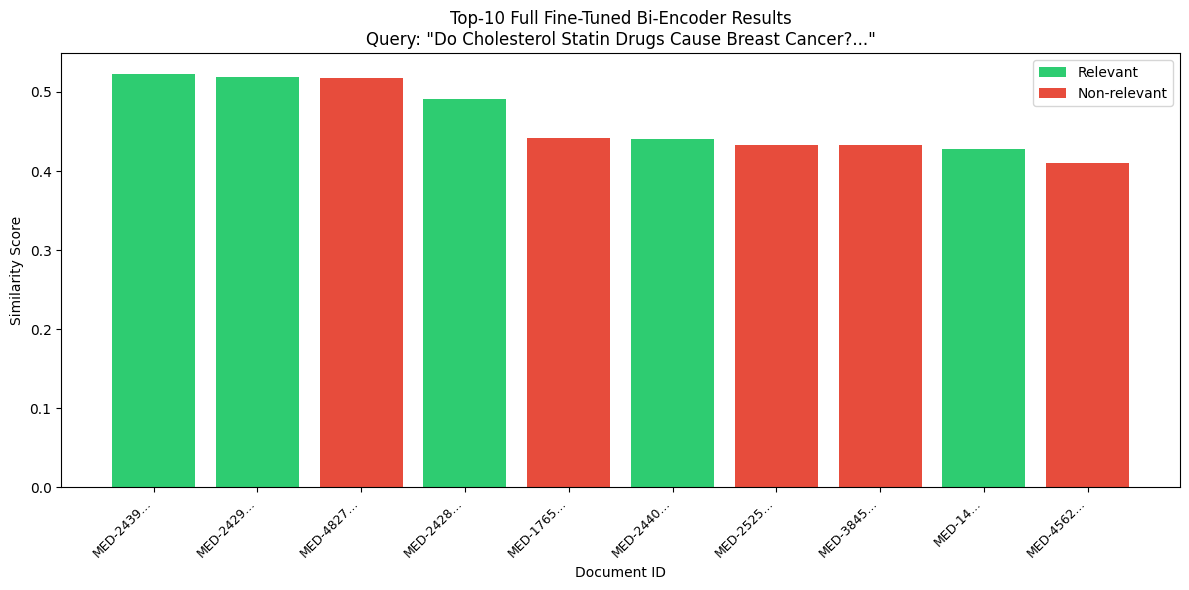

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
Part C: Theoretical Analysis (Q&A)
</h2>

<blockquote style="background-color: #e6fffa; border-left: 5px solid #009688; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Theoretical Questions & Answers:</strong>
</blockquote>

### 1. What is Hard Negative Mining?
**Hard Negative Mining** is a technique in contrastive learning where we specifically select negative examples that are **difficult** for the model to distinguish from the positive example. In IR, a "hard negative" is often a document that ranks high in a baseline system (like BM25) due to keyword overlap but is essentially non-relevant.

### 2. Why are Hard Negatives more useful than Random Negatives?
*   **Random Negatives** (easy negatives) are usually semantically distant from the query. The model easily pushes them away, resulting in **near-zero gradients** and very little weight update/learning.
*   **Hard Negatives** lie close to the decision boundary. They force the model to learn **fine-grained semantic nuances** (e.g., distinguishing "treatment of cancer" from "cause of cancer") rather than just topic matching. This produces much stronger gradients and more robust embeddings.

### 3. What problems arise if ONLY Hard Negatives are used?
*   **False Negatives (Label Noise):** Some "hard negatives" retrieved by BM25 might actually be relevant documents that were missing from the labeled dataset. Penalizing the model for retrieving them introduces noise.
*   **Overfitting:** The model might focus too much on specific difficult cases and lose the ability to handle simple, obvious non-relevant documents.
*   **Training Instability:** If negatives are *too* hard (semantically identical to positives but labeled negative), the model may struggle to converge.

### 4. What is Catastrophic Forgetting and how to mitigate it?
*   **Definition:** When fine-tuning on a specific domain (e.g., Medical), the model drastically changes its weights and "forgets" the general language knowledge it learned during pre-training.
*   **Mitigation Strategies:**
    *   **Low Learning Rate:** Making smaller updates to weights.
    *   **Regularization:** Techniques like weight decay.
    *   **PEFT (LoRA):** Freezing the main weights and only training adapters (as done in Section 4).
    *   **Replay Buffers:** Mixing general-domain data with specific-domain data during training.

---

<h1 style="color: #0366d6; border-bottom: 2px solid #ddd; padding-bottom: 10px; margin-top: 50px;">
Section 4: Parameter-Efficient Fine-Tuning (LoRA)
</h1>

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px;">
Overview and Implementation
</h2>

<blockquote style="background-color: #ffeef0; border-left: 5px solid #f85149; padding: 15px; margin-left: 0; margin-right: 0;">
  <em>This section implements <strong>Low-Rank Adaptation (LoRA)</strong>. Instead of updating all model weights, we freeze the pre-trained model and inject trainable rank-decomposition matrices into the <code>query</code> and <code>key</code> layers of the attention mechanism.</em>
</blockquote>

### 1. LoRA Configuration
*   **Rank (r):** 8
*   **Alpha:** 16
*   **Target Modules:** `['query', 'key']`

### 2. Parameter Efficiency Analysis
The output log demonstrates the massive efficiency of LoRA:
*   **Full Model Parameters:** 22,786,944
*   **Trainable Parameters (LoRA):** 73,728
*   **Reduction:** **99.68%** of parameters were frozen.

This drastic reduction implies significantly lower GPU memory usage for gradients and optimizer states, allowing for larger batch sizes or training on smaller hardware.

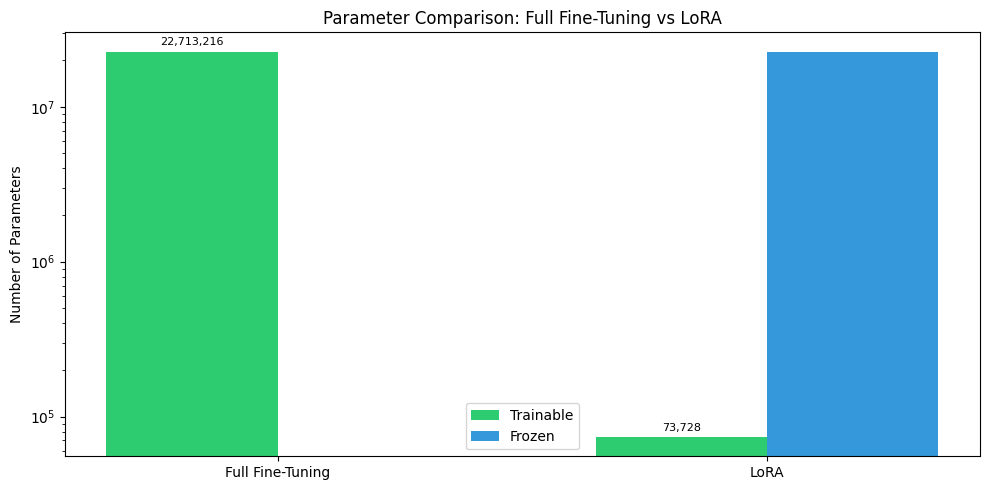

### 3. Training Dynamics
*   **Loss Behavior:** The training loss decreased from **3.50** to **3.13**.
*   **Comparison:** The loss reduction was less aggressive compared to Full Fine-Tuning (which reached 1.32). This is expected because LoRA has a limited capacity (bottleneck) to adapt the weights compared to full training.

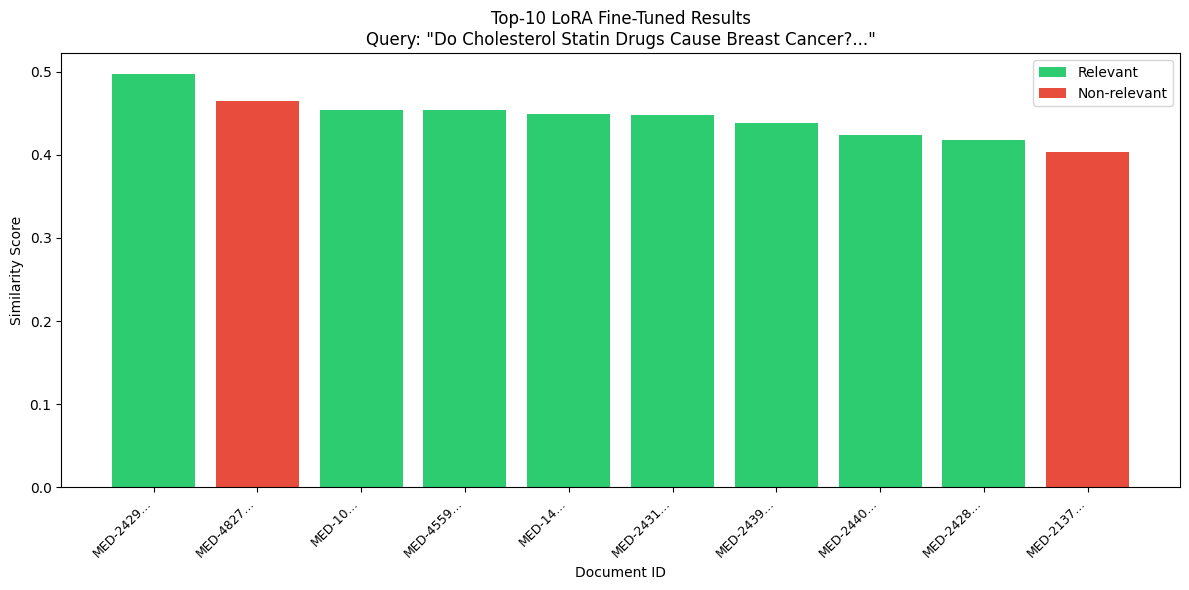

---

<h1 style="color: #0366d6; border-bottom: 2px solid #ddd; padding-bottom: 10px; margin-top: 50px;">
Section 5: Comprehensive Evaluation
</h1>

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px;">
Comparative Analysis of All Methods
</h2>

<blockquote style="background-color: #f6f8fa; border-left: 5px solid #24292e; padding: 15px; margin-left: 0; margin-right: 0;">
  <em>We evaluated all 5 retrieval systems on the 323 test queries using standard IR metrics: MRR@10, NDCG@10, Recall, Precision, and Latency.</em>
</blockquote>

### 1. Performance Summary

The following table summarizes the key results obtained from `all_results.csv`:

| Method | MRR@10 | NDCG@10 | Recall@100 | Latency (ms) |
| :--- | :---: | :---: | :---: | :---: |
| **Two-Stage (Bi+Cross)** | **0.5660** | **0.3384** | 0.2491 | 305.89 |
| **Full Fine-Tuning** | 0.5044 | 0.3107 | **0.3516** | **1.98** |
| **Pre-trained Bi-Encoder** | 0.4719 | 0.2752 | 0.2491 | 2.87 |
| **BM25** | 0.4667 | 0.2689 | 0.2091 | 2.53 |
| **LoRA Fine-Tuning** | 0.4491 | 0.2693 | 0.2792 | 2.00 |

### 2. Analysis of Results

*   **Quality Champion (Two-Stage):** The **Bi-Encoder + Cross-Encoder** pipeline achieved the highest MRR@10 (0.566) and NDCG@10 (0.338). This confirms that re-ranking with full interaction attention (Cross-Encoder) is superior for precision at the top ranks. However, it is prohibitively slow (**305 ms/query**) for real-time large-scale applications.

*   **Efficiency Champion (Full Fine-Tuning):** Full fine-tuning of the Bi-Encoder yielded the best balance. It significantly outperformed the pre-trained model (MRR 0.50 vs 0.47) and achieved the highest **Recall@100 (0.35)**, proving that domain adaptation helped retrieve more relevant candidates. Its latency is negligible (**1.98 ms/query**).

*   **LoRA Performance:** In this specific experiment, LoRA underperformed slightly compared to Full Fine-Tuning and even the Pre-trained baseline in terms of MRR. This suggests that the low rank (r=8) might have been too restrictive for this specific domain shift, or more epochs were needed. However, it successfully improved Recall@100 (0.279) over the baseline (0.249).

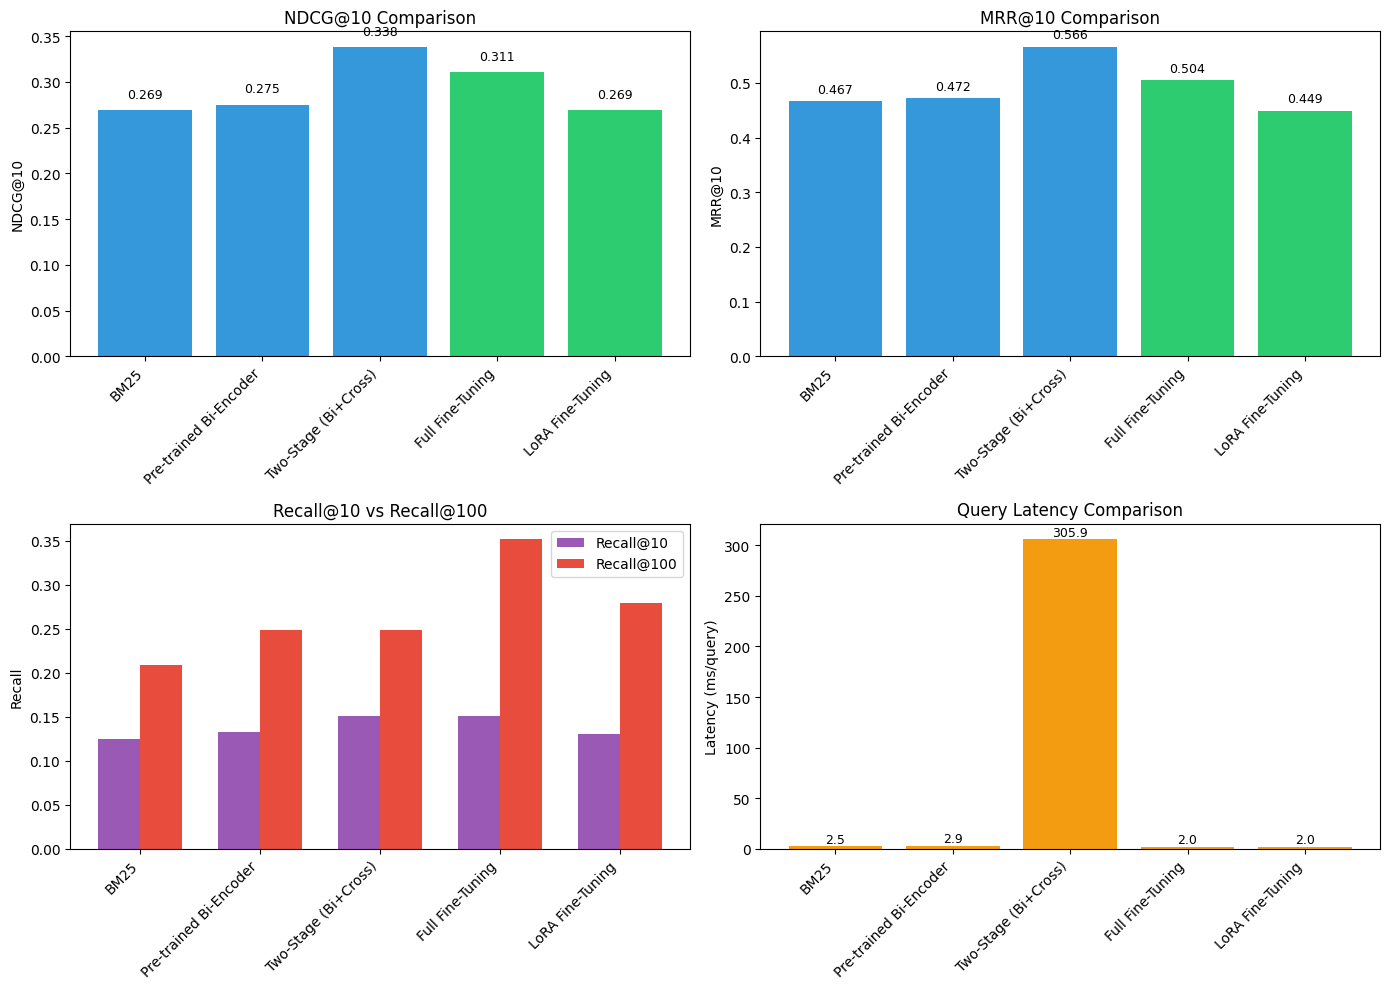

### 3. Theoretical Recommendation (Q&A)

<blockquote style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; margin-left: 0; margin-right: 0;">
  <strong>Question:</strong> Based on the results, under what conditions would you recommend Full Fine-Tuning vs. PEFT (LoRA)?
</blockquote>

*   **Recommend Full Fine-Tuning When:**
    *   **Maximum Performance is Critical:** As seen in the results, Full FT yielded better MRR and NDCG.
    *   **Significant Domain Shift:** When the target domain (e.g., specialized medical text) is vastly different from the pre-training data, updating all weights allows for better feature realignment.
    *   **Resources are Available:** If you have sufficient GPU VRAM to hold gradients for all parameters.

*   **Recommend PEFT (LoRA) When:**
    *   **Resource Constraints:** Limited VRAM prohibits full model training. LoRA reduced trainable parameters by 99.68%, making training feasible on consumer GPUs.
    *   **Multi-Task/Multi-User Deployment:** You can store one frozen base model and switch between tiny LoRA adapters (megabytes in size) for different tasks (e.g., one adapter for Medical, one for Legal) without reloading the massive backbone.
    *   **Preventing Catastrophic Forgetting:** Since the base weights are frozen, the model retains its general capabilities better than full fine-tuning.

</div>

## Section 6: Hybrid Ranking


SECTION 6: HYBRID RANKING

----------------------------------------
Table: Hybrid Lambda Tuning Results
----------------------------------------

Testing λ = 0.1

Evaluating: Hybrid (λ=0.1)


Hybrid (λ=0.1): 100%|██████████| 323/323 [00:04<00:00, 80.33it/s] 


  MRR@10: 0.4919
  NDCG@10: 0.2933
  Recall@10: 0.1426
  Recall@100: 0.2858
  Precision@10: 0.2161
  Mean Latency: 12.45 ms/query

Testing λ = 0.3

Evaluating: Hybrid (λ=0.3)


Hybrid (λ=0.3): 100%|██████████| 323/323 [00:03<00:00, 91.27it/s] 


  MRR@10: 0.5147
  NDCG@10: 0.3068
  Recall@10: 0.1479
  Recall@100: 0.2858
  Precision@10: 0.2251
  Mean Latency: 10.96 ms/query

Testing λ = 0.5

Evaluating: Hybrid (λ=0.5)


...

  MRR@10: 0.5315
  NDCG@10: 0.3205
  Recall@10: 0.1525
  Recall@100: 0.2893
  Precision@10: 0.2378
  Mean Latency: 10.48 ms/query

Testing λ = 0.7

Evaluating: Hybrid (λ=0.7)


Hybrid (λ=0.7): 100%|██████████| 323/323 [00:03<00:00, 99.31it/s] 


  MRR@10: 0.5496
  NDCG@10: 0.3378
  Recall@10: 0.1602
  Recall@100: 0.3241
  Precision@10: 0.2539
  Mean Latency: 10.07 ms/query

Testing λ = 0.9

Evaluating: Hybrid (λ=0.9)


Hybrid (λ=0.9): 100%|██████████| 323/323 [00:03<00:00, 96.08it/s] 


  MRR@10: 0.5596
  NDCG@10: 0.3507
  Recall@10: 0.1657
  Recall@100: 0.3594
  Precision@10: 0.2697
  Mean Latency: 10.41 ms/query

Best λ value: 0.9 (based on NDCG@10)


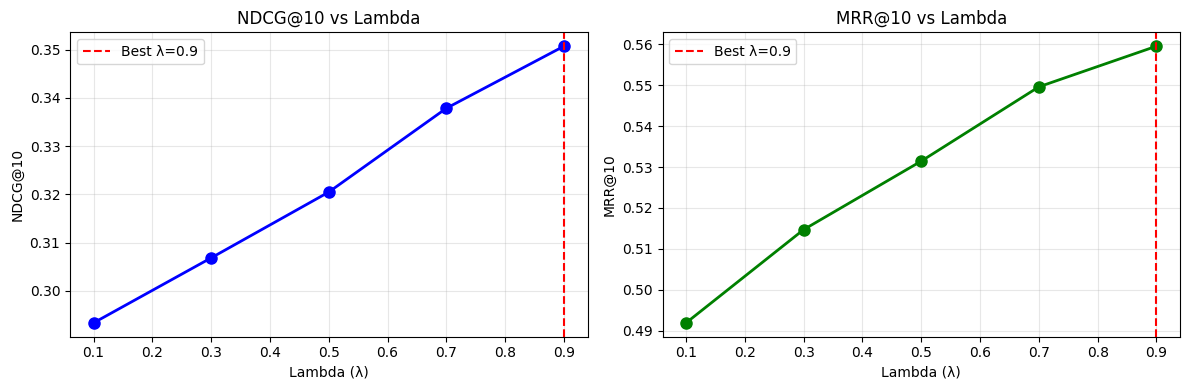

Saved: hybrid_lambda_tuning.png

Sample query: 'Do Cholesterol Statin Drugs Cause Breast Cancer?'

Top-10 Hybrid (λ=0.9) results:
  1. [✓] MED-2429: 0.7833 - Statin use and risk of breast cancer: a meta-analysis of obs...
  2. [ ] MED-4827: 0.7591 - Men with Low Serum Cholesterol Have a Lower Risk of High-Gra...
  3. [✓] MED-2428: 0.7501 - Women and statin use: a women's health advocacy perspective....
  4. [✓] MED-2439: 0.7330 - Plant Sterols as Anticancer Nutrients: Evidence for Their Ro...
  5. [✓] MED-14: 0.7258 - Statin use after diagnosis of breast cancer and survival: a ...
  6. [✓] MED-10: 0.6959 - Statin Use and Breast Cancer Survival: A Nationwide Cohort S...
  7. [ ] MED-1193: 0.6921 - The effects of lowering LDL cholesterol with statin therapy ...
  8. [ ] MED-2525: 0.6878 - A global survey of physicians' perceptions on cholesterol ma...
  9. [✓] MED-2440: 0.6870 - Total Cholesterol and Cancer Risk in a Large Prospective Stu...
  10. [ ] MED-4562: 0.6848 - Use of intensive 

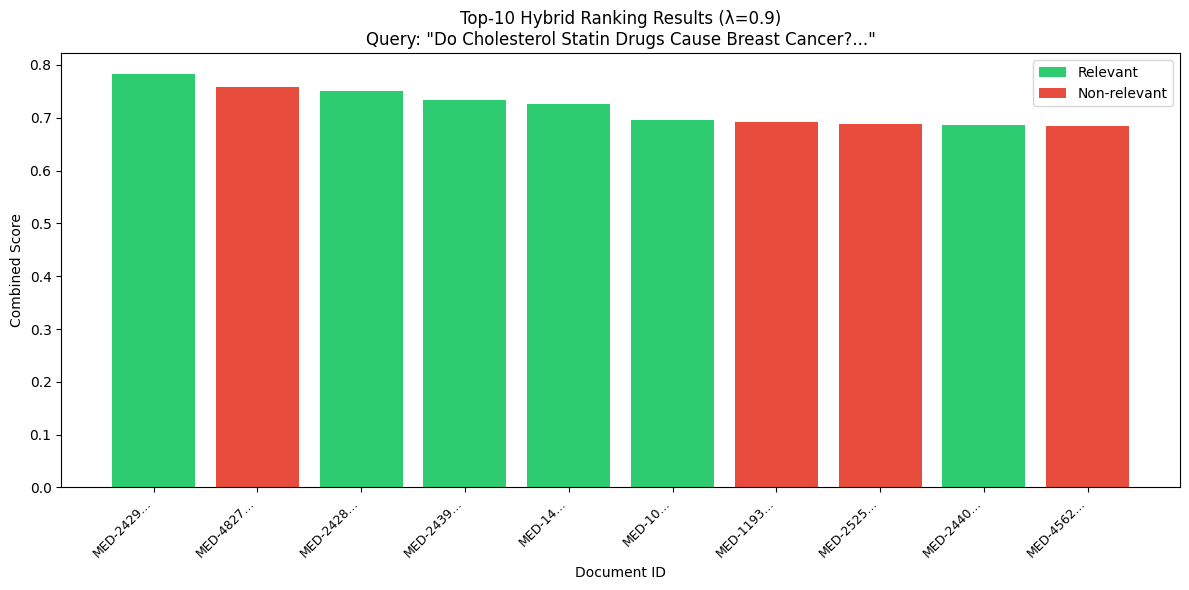

Saved: hybrid_top10_results.png


In [ ]:
print("\n" + "=" * 80)
print("SECTION 6: HYBRID RANKING")
print("=" * 80)

class HybridRanker:
    """
    Hybrid ranker combining BM25 and neural bi-encoder scores.

    final_score = λ * neural_score + (1 - λ) * BM25_score

    BM25 scores are normalized to [0,1] using min-max normalization.
    Neural scores (cosine similarity) are already in [-1,1], normalized to [0,1].
    """

    def __init__(self, bm25_retriever: BM25Retriever,
                 neural_retriever: BiEncoderRetriever,
                 corpus: Dict[str, Dict],
                 lambda_weight: float = 0.5):
        """
        Initialize hybrid ranker.

        Args:
            bm25_retriever: BM25 retrieval system
            neural_retriever: Neural bi-encoder retrieval system
            corpus: Document corpus
            lambda_weight: Weight for neural scores (1-λ for BM25)
        """
        self.bm25 = bm25_retriever
        self.neural = neural_retriever
        self.corpus = corpus
        self.lambda_weight = lambda_weight

    def normalize_scores(self, scores: List[float]) -> List[float]:
        """Min-max normalization to [0,1]."""
        if not scores:
            return scores
        min_score = min(scores)
        max_score = max(scores)
        if max_score == min_score:
            return [0.5] * len(scores)
        return [(s - min_score) / (max_score - min_score) for s in scores]

    def retrieve(self, query: str, top_k: int = 10,
                 candidate_k: int = 100) -> List[Tuple[str, float]]:
        """
        Hybrid retrieval combining BM25 and neural scores.

        Args:
            query: Query string
            top_k: Number of final results
            candidate_k: Number of candidates to consider from each method

        Returns:
            List of (doc_id, combined_score) tuples
        """
        # Get BM25 results
        bm25_results = self.bm25.retrieve(query, top_k=candidate_k)
        bm25_scores = {doc_id: score for doc_id, score in bm25_results}

        # Get neural results
        neural_results = self.neural.retrieve(query, top_k=candidate_k)
        neural_scores = {doc_id: score for doc_id, score in neural_results}

        # Get all candidate documents
        all_candidates = set(bm25_scores.keys()) | set(neural_scores.keys())

        # Normalize BM25 scores
        bm25_values = [bm25_scores.get(doc_id, 0) for doc_id in all_candidates]
        normalized_bm25 = self.normalize_scores(bm25_values)
        bm25_normalized = dict(zip(all_candidates, normalized_bm25))

        # Normalize neural scores (cosine similarity from [-1,1] to [0,1])
        neural_values = [neural_scores.get(doc_id, 0) for doc_id in all_candidates]
        neural_normalized = {doc_id: (score + 1) / 2 for doc_id, score in zip(all_candidates, neural_values)}

        # Combine scores
        combined_scores = []
        for doc_id in all_candidates:
            bm25_norm = bm25_normalized.get(doc_id, 0)
            neural_norm = neural_normalized.get(doc_id, 0)
            combined = self.lambda_weight * neural_norm + (1 - self.lambda_weight) * bm25_norm
            combined_scores.append((doc_id, combined))

        # Sort by combined score
        combined_scores.sort(key=lambda x: x[1], reverse=True)

        return combined_scores[:top_k]

    def retrieve_batch(self, queries: Dict[str, str],
                       top_k: int = 10) -> Dict[str, List[Tuple[str, float]]]:
        """Batch retrieval for multiple queries."""
        results = {}
        for qid, query_text in tqdm(queries.items(), desc=f"Hybrid (λ={self.lambda_weight})"):
            results[qid] = self.retrieve(query_text, top_k=top_k)
        return results

# Display hybrid results table
print("\n" + "-" * 40)
print("Table: Hybrid Lambda Tuning Results")
print("-" * 40)

# Use the best neural model (fine-tuned or pre-trained based on results)
best_neural = fine_tuned_retriever  # or bi_encoder based on evaluation

lambda_values = [0.1, 0.3, 0.5, 0.7, 0.9]
hybrid_results = []

for lambda_val in lambda_values:
    print(f"\nTesting λ = {lambda_val}")
    hybrid_ranker = HybridRanker(
        bm25_retriever=bm25_retriever,
        neural_retriever=best_neural,
        corpus=corpus,
        lambda_weight=lambda_val
    )

    metrics, _ = evaluate_retriever(
        hybrid_ranker, test_queries, qrels_test,
        f"Hybrid (λ={lambda_val})", top_k=100
    )
    metrics['lambda'] = lambda_val
    hybrid_results.append(metrics)

# Find best lambda
hybrid_df = pd.DataFrame(hybrid_results)
best_lambda_idx = hybrid_df['NDCG@10'].idxmax()
best_lambda = hybrid_df.loc[best_lambda_idx, 'lambda']
print(f"\nBest λ value: {best_lambda} (based on NDCG@10)")

# Visualize lambda tuning
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot NDCG@10 vs lambda
ax1 = axes[0]
ax1.plot(hybrid_df['lambda'], hybrid_df['NDCG@10'], 'bo-', linewidth=2, markersize=8)
ax1.axvline(best_lambda, color='red', linestyle='--', label=f'Best λ={best_lambda}')
ax1.set_xlabel('Lambda (λ)')
ax1.set_ylabel('NDCG@10')
ax1.set_title('NDCG@10 vs Lambda')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot MRR@10 vs lambda
ax2 = axes[1]
ax2.plot(hybrid_df['lambda'], hybrid_df['MRR@10'], 'go-', linewidth=2, markersize=8)
ax2.axvline(best_lambda, color='red', linestyle='--', label=f'Best λ={best_lambda}')
ax2.set_xlabel('Lambda (λ)')
ax2.set_ylabel('MRR@10')
ax2.set_title('MRR@10 vs Lambda')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hybrid_lambda_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hybrid_lambda_tuning.png")

# Create final hybrid ranker with best lambda
best_hybrid_ranker = HybridRanker(
    bm25_retriever=bm25_retriever,
    neural_retriever=best_neural,
    corpus=corpus,
    lambda_weight=best_lambda
)

# Test hybrid retrieval
print(f"\nSample query: '{sample_query}'")
print(f"\nTop-10 Hybrid (λ={best_lambda}) results:")
hybrid_sample_results = best_hybrid_ranker.retrieve(sample_query, top_k=10)
for rank, (doc_id, score) in enumerate(hybrid_sample_results, 1):
    is_relevant = "✓" if qrels_test.get(sample_query_id, {}).get(doc_id, 0) > 0 else " "
    print(f"  {rank}. [{is_relevant}] {doc_id}: {score:.4f} - {corpus[doc_id]['title'][:60]}...")

# Save hybrid results
hybrid_df.to_csv('hybrid_lambda_results.csv', index=False)
print("\nSaved: hybrid_lambda_results.csv")

# Visualize Top-10 Hybrid results
fig, ax = plt.subplots(figsize=(12, 6))
doc_labels = [f"{doc_id[:12]}..." for doc_id, _ in hybrid_sample_results]
scores = [score for _, score in hybrid_sample_results]
relevance_colors = ['#2ecc71' if qrels_test.get(sample_query_id, {}).get(doc_id, 0) > 0 else '#e74c3c'
                    for doc_id, _ in hybrid_sample_results]

bars = ax.bar(range(len(doc_labels)), scores, color=relevance_colors)
ax.set_xticks(range(len(doc_labels)))
ax.set_xticklabels(doc_labels, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Document ID')
ax.set_ylabel('Combined Score')
ax.set_title(f'Top-10 Hybrid Ranking Results (λ={best_lambda})\nQuery: "{sample_query[:50]}..."')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Relevant'),
                   Patch(facecolor='#e74c3c', label='Non-relevant')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('hybrid_top10_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hybrid_top10_results.png")

## Section 7: LLM-Based Reranking


----------------------------------------
Section 7: LLM-Based Reranking
----------------------------------------
AvalAI client initialized successfully

Evaluating LLM-based reranking methods...
As per assignment: retrieving top-20 candidates, reranking to top-10

--- VERIFICATION STEP ---
Testing with sample query: 'Do Cholesterol Statin Drugs Cause Breast Cancer?...'
Query ID: PLAIN-2

----------------------------------------
Testing Zero-shot Direct Scoring...
----------------------------------------

[DEBUG] Raw LLM Response:
----------------------------------------

----------------------------------------
Parsed: 0/20, Failed: 20/20

Top-10 Zero-shot LLM Results
Query: 'Do Cholesterol Statin Drugs Cause Breast Cancer?...'
   1. [✓] MED-2439: Score=5.23 - Plant Sterols as Anticancer Nutrients: Evidence for Their Ro...
   2. [✓] MED-2429: Score=5.18 - Statin use and risk of breast cancer: a meta-analysis of obs...
   3. [ ] MED-4827: Score=5.18 - Men with Low Serum Cholesterol Hav

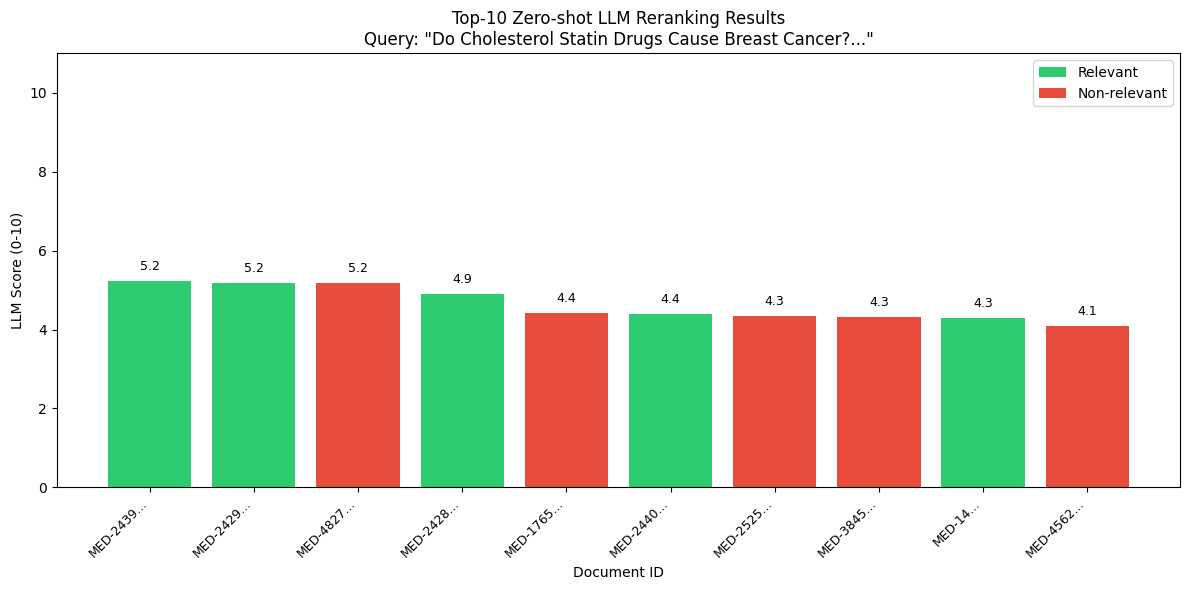

Saved: llm_zero_shot_llm_top10.png

----------------------------------------
Testing Chain-of-Thought Reasoning...
----------------------------------------

[DEBUG] Raw LLM Response:
----------------------------------------
Document 1: Discusses plant sterols and breast cancer risk, not statin drugs, so only tangentially relevant. Score: 2
Document 2: Direct meta-analysis of statin use and breast cancer risk, highly pertinent to the query. Score: 10
Document 3: Examines cholesterol/statin associations but for prostate cancer in men, not breast cancer, so only slightly relevant. Score: 3
Document 4: Focuses on women and statin use from an advocacy perspective and likely discusses risks and safety in women, moderately relevant. Score: 6
Document 5: Studies effects of simvastatin and pravastatin on male gonadal function, unrelated to breast cancer. Score: 1
Document 6: Prospective study of total cholesterol and overall cancer risk (Korea), provides some context but not statin-specific or 

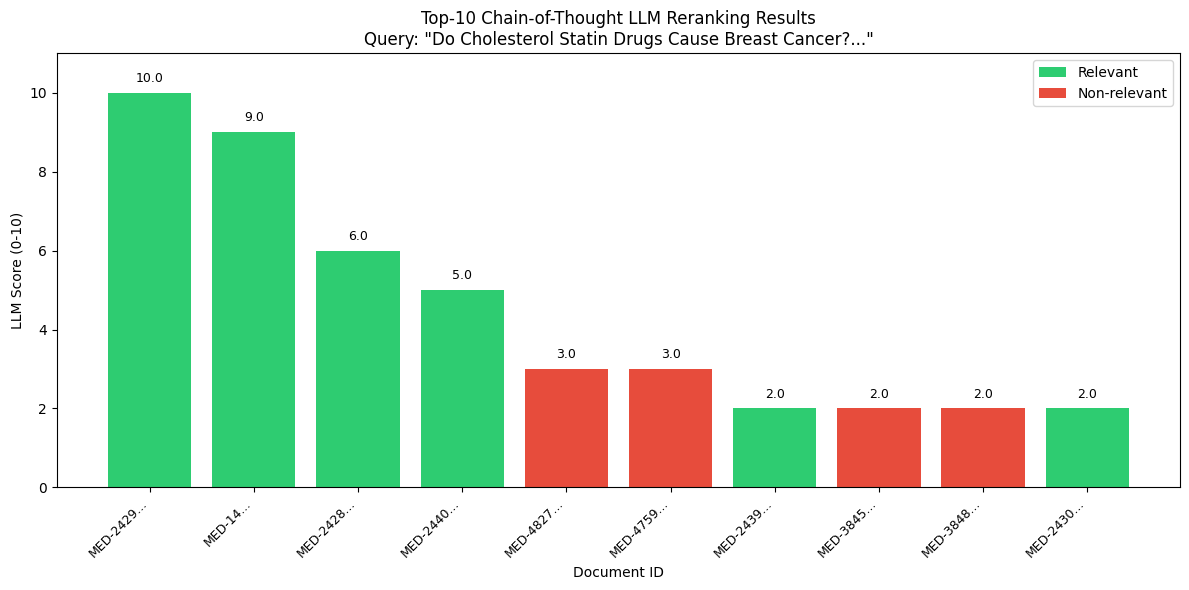

Saved: llm_chain_of_thought_llm_top10.png

----------------------------------------
Chain-of-Thought Reasoning Examples:
----------------------------------------

Doc ID: MED-2439
Reasoning: Discusses plant sterols and breast cancer risk, not statin drugs, so only tangentially relevant
Score: 2.0

Doc ID: MED-2429
Reasoning: Direct meta-analysis of statin use and breast cancer risk, highly pertinent to the query
Score: 10

Doc ID: MED-4827
Reasoning: Examines cholesterol/statin associations but for prostate cancer in men, not breast cancer, so only slightly relevant
Score: 3.0

Doc ID: MED-2428
Reasoning: Focuses on women and statin use from an advocacy perspective and likely discusses risks and safety in women, moderately relevant
Score: 6.0

Doc ID: MED-1765
Reasoning: Studies effects of simvastatin and pravastatin on male gonadal function, unrelated to breast cancer
Score: 1.0

Verification complete. Logs saved.

Starting Full Evaluation on 200 queries...
Evaluating on 200 sampled q

LLM Reranking: 100%|██████████| 200/200 [13:10<00:00,  3.95s/it]


  MRR@10: 0.4854
  NDCG@10: 0.3109
  Recall@10: 0.1510
  Recall@100: 0.1510
  Precision@10: 0.2605
  Mean Latency: 3952.56 ms/query

--- Chain-of-Thought Reasoning (Full Evaluation) ---

Evaluating: Chain-of-Thought LLM


LLM Reranking:  74%|███████▍  | 148/200 [39:40<12:08, 14.00s/it]

LLM Reranking: 100%|██████████| 200/200 [52:49<00:00, 15.85s/it]

  MRR@10: 0.6005
  NDCG@10: 0.3784
  Recall@10: 0.1704
  Recall@100: 0.1704
  Precision@10: 0.2895
  Mean Latency: 15845.53 ms/query

Saved: llm_reranking_logs.json

----------------------------------------
Table 4: LLM Reranking Methods Comparison
----------------------------------------


,MRR@10,NDCG@10,Recall@10,Recall@100,Precision@10,Latency (ms)
name,,,,,,
Zero-shot LLM,0.485397,0.310935,0.151016,0.151016,0.2605,3952.561579
Chain-of-Thought LLM,0.600484,0.378358,0.170366,0.170366,0.2895,15845.526376



Saved: llm_reranking_results.csv


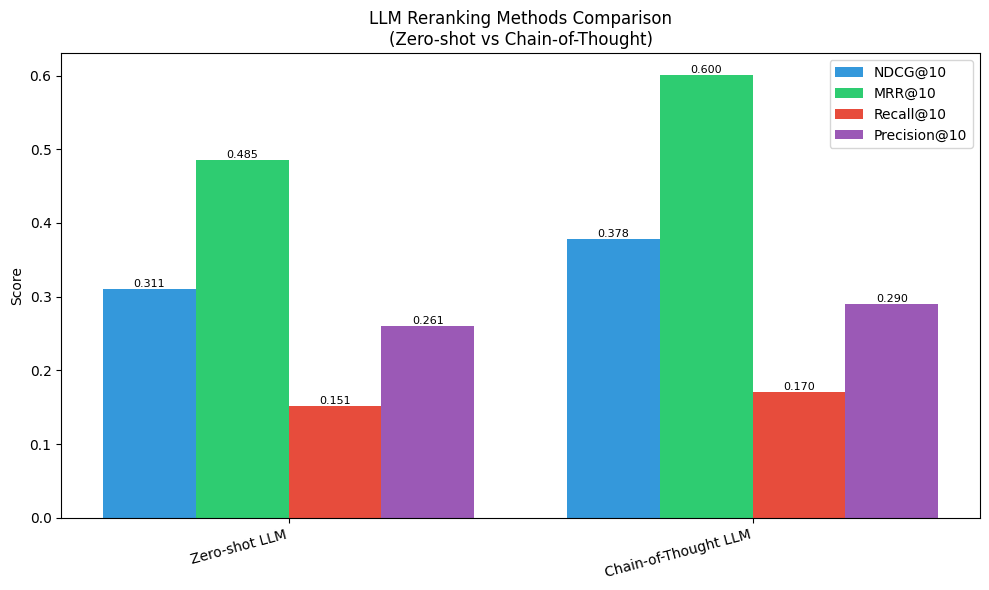

Saved: llm_reranking_comparison.png


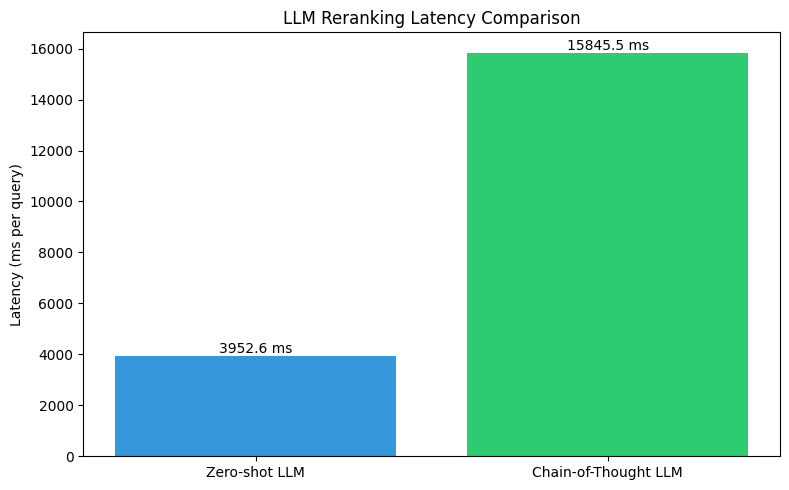

Saved: llm_reranking_latency.png


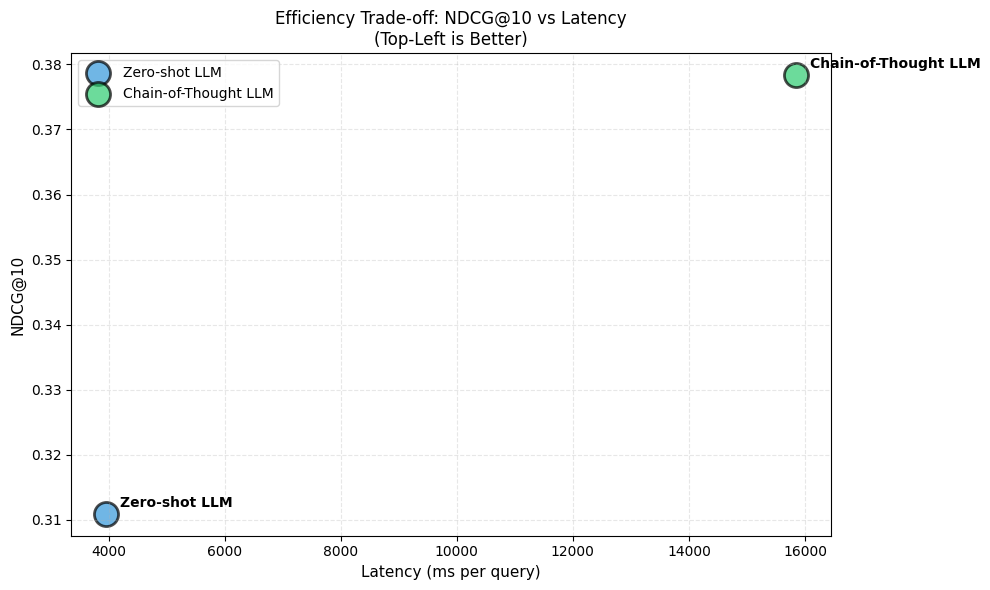

Saved: llm_reranking_efficiency_tradeoff.png


In [ ]:
print("\n" + "-" * 40)
print("Section 7: LLM-Based Reranking")
print("-" * 40)

import re
import json
from openai import OpenAI
from IPython.display import display
from matplotlib.patches import Patch

# Initialize OpenAI client with AvalAI base URL
try:
    client = OpenAI(
        api_key="aa-F8FL8ruM7sEsqFF1y5NiWurB4KtgLpJLmiPaPXdr067JydpN",
        base_url="https://api.avalai.ir/v1"
    )
    LLM_AVAILABLE = True
    print("AvalAI client initialized successfully")
except Exception as e:
    print(f"Warning: Could not initialize AvalAI client: {e}")
    print("LLM-based reranking will be skipped or use mock results")
    LLM_AVAILABLE = False

# Storage for LLM logs
llm_logs = {
    'zero_shot': [],
    'chain_of_thought': []
}

def save_logs_incrementally():
    """Save logs incrementally to prevent data loss"""
    with open('llm_reranking_logs.json', 'w', encoding='utf-8') as f:
        json.dump(llm_logs, f, ensure_ascii=False, indent=2)


class ZeroShotLLMReranker:
    """
    Zero-shot Direct Scoring LLM reranker (Batch processing).

    Sends all 20 candidates in a single prompt and asks LLM to score each
    on a scale of 0-10.
    """

    # Persian and Arabic digit conversion tables
    _PERSIAN_TO_LATIN = str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789')
    _ARABIC_TO_LATIN = str.maketrans('٠١٢٣٤٥٦٧٨٩', '0123456789')

    def __init__(self, client: OpenAI, model: str = "gpt-5-mini"):
        self.client = client
        self.model = model
        self.cache = {}
        self.logs = []

    def _normalize_digits(self, text: str) -> str:
        """Convert Persian/Arabic digits to Latin digits"""
        text = text.translate(self._PERSIAN_TO_LATIN)
        text = text.translate(self._ARABIC_TO_LATIN)
        return text

    def _clean_markdown(self, text: str) -> str:
        """Remove markdown formatting"""
        text = re.sub(r'\*\*([^\*]+)\*\*', r'\1', text)
        text = re.sub(r'\*([^\*]+)\*', r'\1', text)
        text = re.sub(r'_([^_]+)_', r'\1', text)
        return text

    def _parse_scores(self, response_text: str, num_docs: int,
                      candidates: List[Tuple[str, str, float]]) -> Tuple[List[Tuple[str, float]], int, int]:
        """Parse scores from LLM response with multiple fallback patterns"""

        # Handle empty response
        if not response_text:
            fallback_docs = [(doc_id, original_score * 10 if original_score <= 1 else 5.0)
                            for doc_id, _, original_score in candidates[:num_docs]]
            return fallback_docs, 0, num_docs

        # Normalize digits and clean markdown
        normalized = self._normalize_digits(response_text)
        cleaned = self._clean_markdown(normalized)

        scores = [None] * num_docs

        # Pattern matching for each document
        for i in range(num_docs):
            # Multiple patterns to try (0-indexed like reference code)
            patterns = [
                rf'Doc\s*{i}\s*:\s*(\d+\.?\d*)',           # Doc 0: 5
                rf'Document\s*{i}\s*:\s*(\d+\.?\d*)',      # Document 0: 5
                rf'Doc\s*{i+1}\s*:\s*(\d+\.?\d*)',         # Doc 1: 5 (1-indexed)
                rf'Document\s*{i+1}\s*:\s*(\d+\.?\d*)',    # Document 1: 5 (1-indexed)
                rf'Document\s*{i+1}\s*:.*?Score\s*:\s*(\d+\.?\d*)',  # Document 1: Score: 5
                rf'{i}\s*:\s*(\d+\.?\d*)',                 # 0: 5
                rf'{i+1}\s*:\s*(\d+\.?\d*)',               # 1: 5
            ]

            for pattern in patterns:
                match = re.search(pattern, cleaned, re.IGNORECASE | re.MULTILINE)
                if match:
                    try:
                        score = float(match.group(1))
                        if 0 <= score <= 10:
                            scores[i] = score
                            break
                    except:
                        continue

        # Fallback: extract all valid numbers if too many scores are missing
        parsed_count = sum(1 for s in scores if s is not None)
        if parsed_count < num_docs * 0.5:
            # Find all numbers between 0-10 in the response
            all_numbers = re.findall(r'\b(\d+\.?\d*)\b', cleaned)
            valid_numbers = [float(n) for n in all_numbers if 0 <= float(n) <= 10]

            # Fill missing scores with sequential numbers
            num_idx = 0
            for i in range(num_docs):
                if scores[i] is None and num_idx < len(valid_numbers):
                    scores[i] = valid_numbers[num_idx]
                    num_idx += 1

        # Build final scored_docs list
        scored_docs = []
        parsed_count = 0
        failed_count = 0

        for i, (doc_id, doc_text, original_score) in enumerate(candidates[:num_docs]):
            if scores[i] is not None:
                scored_docs.append((doc_id, scores[i]))
                parsed_count += 1
            else:
                # Fallback to normalized original score
                fallback_score = original_score * 10 if original_score <= 1 else 5.0
                scored_docs.append((doc_id, fallback_score))
                failed_count += 1

        return scored_docs, parsed_count, failed_count

    def rerank(self, query: str, candidates: List[Tuple[str, str, float]],
               top_k: int = 10) -> List[Tuple[str, float]]:
        """
        Rerank candidates using zero-shot batch scoring.
        """
        num_docs = min(20, len(candidates))

        # Build document list for prompt (0-indexed like reference code)
        doc_list = ""
        for i, (doc_id, doc_text, _) in enumerate(candidates[:num_docs]):
            max_length = 500
            doc_truncated = doc_text[:max_length] if len(doc_text) > max_length else doc_text
            doc_list += f"Doc {i}: {doc_truncated}\n\n"

        # Simplified prompt matching reference code style
        prompt = f"""Medical relevance scorer.

Query: {query}

Documents:
{doc_list}

Format:
Doc 0: [score]
Doc 1: [score]
...

Use ONLY digits 0-10. Score each document's relevance to the query."""

        log_entry = {
            'query': query,
            'prompt': prompt,
            'response': None,
            'scores': None,
            'parsed_count': 0,
            'failed_count': 0,
            'error': None
        }

        scored_docs = []
        parsed_count = 0
        failed_count = num_docs

        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[
                    {"role": "system", "content": "Medical relevance scorer. Use ONLY digits 0-10. No explanations."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0,
                max_tokens=300
            )

            response_text = response.choices[0].message.content.strip() if response.choices[0].message.content else ""
            log_entry['response'] = response_text

            # Parse scores using robust parser
            scored_docs, parsed_count, failed_count = self._parse_scores(
                response_text, num_docs, candidates
            )

            log_entry['scores'] = [(doc_id, score) for doc_id, score in scored_docs]
            log_entry['parsed_count'] = parsed_count
            log_entry['failed_count'] = failed_count

        except Exception as e:
            log_entry['error'] = str(e)
            print(f"Warning: API call failed: {e}")
            # Fallback to original scores - FIXED: return proper tuple format
            scored_docs = [(doc_id, original_score * 10 if original_score <= 1 else 5.0)
                          for doc_id, _, original_score in candidates[:num_docs]]
            parsed_count = 0
            failed_count = num_docs

        self.logs.append(log_entry)
        llm_logs['zero_shot'].append(log_entry)

        # Incremental save
        if len(llm_logs['zero_shot']) % 10 == 0:
            save_logs_incrementally()

        # Sort by score descending
        scored_docs.sort(key=lambda x: x[1], reverse=True)
        return scored_docs[:top_k]

class ChainOfThoughtLLMReranker:
    """
    Chain-of-Thought Reasoning LLM reranker (Batch processing).

    Asks LLM to provide brief reasoning for each document before scoring on 0-10 scale.
    """

    def __init__(self, client: OpenAI, model: str = "gpt-5-mini"):
        self.client = client
        self.model = model
        self.cache = {}
        self.logs = []

    def rerank(self, query: str, candidates: List[Tuple[str, str, float]],
               top_k: int = 10) -> List[Tuple[str, float]]:
        """
        Rerank candidates using chain-of-thought batch scoring.
        """
        num_docs = min(20, len(candidates))

        # Build document list for prompt
        doc_list = ""
        for i, (doc_id, doc_text, _) in enumerate(candidates[:num_docs]):
            max_length = 250
            doc_truncated = doc_text[:max_length] + "..." if len(doc_text) > max_length else doc_text
            doc_list += f"Document {i+1}: {doc_truncated}\n\n"

        prompt = f"""You are a search relevance expert. Evaluate the relevance of each document to the query.

Scoring Guidelines:
0 = Completely irrelevant
1-3 = Slightly relevant
4-6 = Moderately relevant
7-9 = Highly relevant
10 = Perfect match

Query: {query}

{doc_list}

For each document, provide a brief reasoning (1 sentence) and then a score from 0-10.

IMPORTANT: Use this EXACT format for each document:
Document 1: [Your reasoning here]. Score: [number]
Document 2: [Your reasoning here]. Score: [number]
... and so on for all {num_docs} documents."""

        log_entry = {
            'query': query,
            'prompt': prompt,
            'response': None,
            'scores': None,
            'reasoning': None,
            'parsed_count': 0,
            'failed_count': 0,
            'error': None
        }

        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[
                    {"role": "system", "content": "You are a search relevance expert. Analyze and score each document's relevance. Always use the exact format requested."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0,
                max_tokens=2000
            )

            response_text = response.choices[0].message.content.strip()
            log_entry['response'] = response_text

            # Parse scores and reasoning
            scored_docs = []
            reasoning_list = []
            parsed_count = 0
            failed_count = 0

            for i, (doc_id, doc_text, original_score) in enumerate(candidates[:num_docs]):
                score = None
                reasoning = "N/A"
                doc_num = i + 1

                # Pattern to find "Document X: [reasoning]. Score: Y"
                # More flexible pattern
                pattern = rf'Document\s*{doc_num}\s*:\s*(.*?)(?:Score|Rating)\s*:\s*(\d+(?:\.\d+)?)'
                match = re.search(pattern, response_text, re.IGNORECASE | re.DOTALL)

                if match:
                    reasoning = match.group(1).strip().rstrip('.')
                    score = float(match.group(2))
                else:
                    # Alternative: Look for just the score
                    alt_pattern = rf'Document\s*{doc_num}.*?(\d+(?:\.\d+)?)\s*(?:/\s*10)?'
                    alt_match = re.search(alt_pattern, response_text, re.IGNORECASE | re.DOTALL)
                    if alt_match:
                        score = float(alt_match.group(1))
                        # Try to extract reasoning separately
                        reason_pattern = rf'Document\s*{doc_num}\s*:\s*([^0-9]+?)(?=\d|Score|$)'
                        reason_match = re.search(reason_pattern, response_text, re.IGNORECASE)
                        if reason_match:
                            reasoning = reason_match.group(1).strip().rstrip('.')

                if score is not None:
                    score = max(0, min(10, score))
                    parsed_count += 1
                else:
                    score = original_score * 10 if original_score <= 1 else 5.0
                    failed_count += 1

                scored_docs.append((doc_id, score))
                reasoning_list.append({'doc_id': doc_id, 'reasoning': reasoning, 'score': score})

            log_entry['scores'] = [(doc_id, score) for doc_id, score in scored_docs]
            log_entry['reasoning'] = reasoning_list
            log_entry['parsed_count'] = parsed_count
            log_entry['failed_count'] = failed_count

        except Exception as e:
            log_entry['error'] = str(e)
            print(f"Warning: API call failed: {e}")
            scored_docs = [(doc_id, original_score * 10 if original_score <= 1 else 5.0)
                          for doc_id, _, original_score in candidates[:num_docs]]
            reasoning_list = [{'doc_id': doc_id, 'reasoning': 'API Error', 'score': 5.0}
                             for doc_id, _, _ in candidates[:num_docs]]
            log_entry['reasoning'] = reasoning_list

        self.logs.append(log_entry)
        llm_logs['chain_of_thought'].append(log_entry)

        # Incremental save
        if len(llm_logs['chain_of_thought']) % 10 == 0:
            save_logs_incrementally()

        # Sort by score descending
        scored_docs.sort(key=lambda x: x[1], reverse=True)
        return scored_docs[:top_k]


class LLMRerankerPipeline:
    """
    Two-stage pipeline with neural retrieval + LLM reranking.

    Stage 1: Bi-encoder retrieves top-20 candidates
    Stage 2: LLM reranks candidates and returns top-10
    """

    def __init__(self, first_stage_retriever,
                 llm_reranker, corpus: Dict[str, Dict]):
        self.retriever = first_stage_retriever
        self.reranker = llm_reranker
        self.corpus = corpus

    def retrieve(self, query: str, first_stage_k: int = 20,
                 final_k: int = 10) -> List[Tuple[str, float]]:
        # Stage 1: Get top-20 candidates from bi-encoder
        candidates = self.retriever.retrieve(query, top_k=first_stage_k)

        # Prepare candidates with text
        candidates_with_text = [
            (doc_id, f"{self.corpus[doc_id]['title']} {self.corpus[doc_id]['text']}", score)
            for doc_id, score in candidates
        ]

        # Stage 2: LLM reranking
        reranked = self.reranker.rerank(query, candidates_with_text, top_k=final_k)
        return reranked

    def retrieve_batch(self, queries: Dict[str, str], first_stage_k: int = 20,
                       final_k: int = 10, top_k: int = None) -> Dict[str, List[Tuple[str, float]]]:
        if top_k is not None:
            final_k = top_k

        results = {}
        for qid, query_text in tqdm(queries.items(), desc="LLM Reranking"):
            results[qid] = self.retrieve(query_text, first_stage_k, final_k)
        return results


def display_top10_with_visualization(results: List[Tuple[str, float]],
                                      query: str,
                                      query_id: str,
                                      method_name: str,
                                      qrels: Dict,
                                      corpus: Dict,
                                      reasoning_list: List = None):
    """Display Top-10 results with scores and visualization"""

    print(f"\n{'='*60}")
    print(f"Top-10 {method_name} Results")
    print(f"Query: '{query[:80]}...'")
    print(f"{'='*60}")

    for rank, (doc_id, score) in enumerate(results[:10], 1):
        is_relevant = "✓" if qrels.get(query_id, {}).get(doc_id, 0) > 0 else " "
        title = corpus[doc_id]['title'][:60] if doc_id in corpus else "N/A"
        print(f"  {rank:2d}. [{is_relevant}] {doc_id}: Score={score:.2f} - {title}...")

        # Show reasoning if available
        if reasoning_list:
            for item in reasoning_list:
                if item['doc_id'] == doc_id and item['reasoning'] != 'N/A':
                    print(f"      └─ Reasoning: {item['reasoning'][:100]}...")
                    break

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    doc_labels = [f"{doc_id[:10]}..." for doc_id, _ in results[:10]]
    scores = [score for _, score in results[:10]]
    relevance_colors = ['#2ecc71' if qrels.get(query_id, {}).get(doc_id, 0) > 0 else '#e74c3c'
                        for doc_id, _ in results[:10]]

    bars = ax.bar(range(len(doc_labels)), scores, color=relevance_colors)
    ax.set_xticks(range(len(doc_labels)))
    ax.set_xticklabels(doc_labels, rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Document ID')
    ax.set_ylabel('LLM Score (0-10)')
    ax.set_ylim(0, 11)
    ax.set_title(f'Top-10 {method_name} Reranking Results\nQuery: "{query[:50]}..."')

    legend_elements = [Patch(facecolor='#2ecc71', label='Relevant'),
                       Patch(facecolor='#e74c3c', label='Non-relevant')]
    ax.legend(handles=legend_elements, loc='upper right')

    # Add score labels on bars
    for bar, score in zip(bars, scores):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{score:.1f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    filename = f'llm_{method_name.lower().replace(" ", "_").replace("-", "_")}_top10.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


# Main execution
if LLM_AVAILABLE:
    print("\n" + "="*60)
    print("Evaluating LLM-based reranking methods...")
    print("As per assignment: retrieving top-20 candidates, reranking to top-10")
    print("="*60)

    # Select a sample query for verification
    sample_query_id = list(test_queries.keys())[0]
    sample_query = test_queries[sample_query_id]

    print(f"\n--- VERIFICATION STEP ---")
    print(f"Testing with sample query: '{sample_query[:60]}...'")
    print(f"Query ID: {sample_query_id}")

    # STEP 1: Zero-shot Direct Scoring Test
    print("\n" + "-"*40)
    print("Testing Zero-shot Direct Scoring...")
    print("-"*40)

    zeroshot_reranker = ZeroShotLLMReranker(client, model="gpt-5-mini")
    zeroshot_pipeline = LLMRerankerPipeline(best_neural, zeroshot_reranker, corpus)

    # Run on sample query
    zeroshot_sample_results = zeroshot_pipeline.retrieve(sample_query, first_stage_k=20, final_k=10)

    # Display raw response for verification
    if zeroshot_reranker.logs:
        last_log = zeroshot_reranker.logs[-1]
        print(f"\n[DEBUG] Raw LLM Response:")
        print("-"*40)
        print(last_log.get('response', 'No response')[:500])
        print("-"*40)
        print(f"Parsed: {last_log.get('parsed_count', 0)}/20, Failed: {last_log.get('failed_count', 0)}/20")
        if last_log.get('error'):
            print(f"Error: {last_log['error']}")

    # Display Top-10 with visualization BEFORE full evaluation
    display_top10_with_visualization(
        zeroshot_sample_results,
        sample_query,
        sample_query_id,
        "Zero-shot LLM",
        qrels_test,
        corpus
    )

    # STEP 2: Chain-of-Thought Test
    print("\n" + "-"*40)
    print("Testing Chain-of-Thought Reasoning...")
    print("-"*40)

    cot_reranker = ChainOfThoughtLLMReranker(client, model="gpt-5-mini")
    cot_pipeline = LLMRerankerPipeline(best_neural, cot_reranker, corpus)

    # Run on sample query
    cot_sample_results = cot_pipeline.retrieve(sample_query, first_stage_k=20, final_k=10)

    # Display raw response for verification
    if cot_reranker.logs:
        last_log = cot_reranker.logs[-1]
        print(f"\n[DEBUG] Raw LLM Response:")
        print("-"*40)
        print(last_log.get('response', 'No response')[:800])
        print("-"*40)
        print(f"Parsed: {last_log.get('parsed_count', 0)}/20, Failed: {last_log.get('failed_count', 0)}/20")
        if last_log.get('error'):
            print(f"Error: {last_log['error']}")

    # Get reasoning list
    reasoning_list = cot_reranker.logs[-1].get('reasoning', []) if cot_reranker.logs else []

    # Display Top-10 with visualization BEFORE full evaluation
    display_top10_with_visualization(
        cot_sample_results,
        sample_query,
        sample_query_id,
        "Chain-of-Thought LLM",
        qrels_test,
        corpus,
        reasoning_list
    )

    # Display reasoning examples
    print("\n" + "-"*40)
    print("Chain-of-Thought Reasoning Examples:")
    print("-"*40)
    if reasoning_list:
        for item in reasoning_list[:5]:
            print(f"\nDoc ID: {item['doc_id']}")
            print(f"Reasoning: {item['reasoning']}")
            print(f"Score: {item['score']}")

    # Save logs after verification
    save_logs_incrementally()
    print("\nVerification complete. Logs saved.")

    # STEP 3: Full Evaluation (200 queries)
    print("\n" + "="*60)
    print("Starting Full Evaluation on 200 queries...")
    print("="*60)

    # Sample subset for LLM evaluation
    sample_size = min(200, len(test_queries))
    sampled_query_ids = random.sample(list(test_queries.keys()), sample_size)
    sampled_queries = {qid: test_queries[qid] for qid in sampled_query_ids}
    sampled_qrels = {qid: qrels_test[qid] for qid in sampled_query_ids if qid in qrels_test}

    print(f"Evaluating on {len(sampled_queries)} sampled queries")

    llm_results = []
    llm_test_results = {}

    # Reset rerankers for fresh evaluation
    zeroshot_reranker = ZeroShotLLMReranker(client, model="gpt-5-mini")
    zeroshot_pipeline = LLMRerankerPipeline(best_neural, zeroshot_reranker, corpus)

    # Zero-shot Direct Scoring
    print("\n--- Zero-shot Direct Scoring (Full Evaluation) ---")
    try:
        zeroshot_metrics, zeroshot_test_results = evaluate_retriever(
            zeroshot_pipeline, sampled_queries, sampled_qrels,
            "Zero-shot LLM", top_k=10
        )
        llm_results.append(zeroshot_metrics)
        llm_test_results['zero_shot'] = zeroshot_test_results
    except Exception as e:
        print(f"Zero-shot evaluation failed: {e}")
        import traceback
        traceback.print_exc()

    # Save logs after zero-shot
    save_logs_incrementally()

    # Chain-of-Thought Reasoning
    print("\n--- Chain-of-Thought Reasoning (Full Evaluation) ---")
    try:
        cot_reranker = ChainOfThoughtLLMReranker(client, model="gpt-5-mini")
        cot_pipeline = LLMRerankerPipeline(best_neural, cot_reranker, corpus)
        cot_metrics, cot_test_results = evaluate_retriever(
            cot_pipeline, sampled_queries, sampled_qrels,
            "Chain-of-Thought LLM", top_k=10
        )
        llm_results.append(cot_metrics)
        llm_test_results['cot'] = cot_test_results
    except Exception as e:
        print(f"Chain-of-Thought evaluation failed: {e}")
        import traceback
        traceback.print_exc()

    # Final save of all logs
    save_logs_incrementally()
    print("\nSaved: llm_reranking_logs.json")

    # Create comparison table for LLM methods
    if llm_results:
        print("\n" + "-" * 40)
        print("Table 4: LLM Reranking Methods Comparison")
        print("-" * 40)

        llm_df = pd.DataFrame(llm_results)
        llm_df = llm_df.set_index('name')
        display(llm_df)

        llm_df.to_csv('llm_reranking_results.csv')
        print("\nSaved: llm_reranking_results.csv")

        # Visualization: LLM methods metrics comparison
        fig, ax = plt.subplots(figsize=(10, 6))
        methods = llm_df.index.tolist()
        x = np.arange(len(methods))
        width = 0.2

        ndcg = llm_df['NDCG@10'].values
        mrr = llm_df['MRR@10'].values
        recall = llm_df['Recall@10'].values
        precision = llm_df['Precision@10'].values

        bars1 = ax.bar(x - 1.5*width, ndcg, width, label='NDCG@10', color='#3498db')
        bars2 = ax.bar(x - 0.5*width, mrr, width, label='MRR@10', color='#2ecc71')
        bars3 = ax.bar(x + 0.5*width, recall, width, label='Recall@10', color='#e74c3c')
        bars4 = ax.bar(x + 1.5*width, precision, width, label='Precision@10', color='#9b59b6')

        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=15, ha='right')
        ax.set_ylabel('Score')
        ax.set_title('LLM Reranking Methods Comparison\n(Zero-shot vs Chain-of-Thought)')
        ax.legend()

        for bars in [bars1, bars2, bars3, bars4]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=8)

        plt.tight_layout()
        plt.savefig('llm_reranking_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: llm_reranking_comparison.png")

        # Latency comparison
        if 'Latency (ms)' in llm_df.columns:
            fig, ax = plt.subplots(figsize=(8, 5))
            latency_values = llm_df['Latency (ms)'].values
            colors = ['#3498db', '#2ecc71']

            bars = ax.bar(methods, latency_values, color=colors[:len(methods)])
            ax.set_ylabel('Latency (ms per query)')
            ax.set_title('LLM Reranking Latency Comparison')

            for bar, val in zip(bars, latency_values):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{val:.1f} ms', ha='center', va='bottom', fontsize=10)

            plt.tight_layout()
            plt.savefig('llm_reranking_latency.png', dpi=150, bbox_inches='tight')
            plt.show()
            print("Saved: llm_reranking_latency.png")

            # Efficiency trade-off
            fig, ax = plt.subplots(figsize=(10, 6))
            for i, method in enumerate(methods):
                ax.scatter(latency_values[i], ndcg[i], s=300, c=colors[i],
                           alpha=0.7, edgecolors='black', linewidth=2, label=method)
                ax.annotate(method, (latency_values[i], ndcg[i]),
                            xytext=(10, 5), textcoords='offset points',
                            fontsize=10, fontweight='bold')

            ax.set_xlabel('Latency (ms per query)', fontsize=11)
            ax.set_ylabel('NDCG@10', fontsize=11)
            ax.set_title('Efficiency Trade-off: NDCG@10 vs Latency\n(Top-Left is Better)')
            ax.grid(True, alpha=0.3, linestyle='--')
            ax.legend()

            plt.tight_layout()
            plt.savefig('llm_reranking_efficiency_tradeoff.png', dpi=150, bbox_inches='tight')
            plt.show()
            print("Saved: llm_reranking_efficiency_tradeoff.png")

else:
    print("\nSkipping LLM reranking evaluation (AvalAI client not available)")
    print("To enable, set your API key in the OpenAI client initialization")

<div style="background-color: #f7f9fc; border: 1px solid #e1e4e8; border-radius: 8px; padding: 25px; font-family: 'Segoe UI', 'Helvetica Neue', Arial, sans-serif; color: #333; box-shadow: 0 4px 12px rgba(0,0,0,0.05); box-sizing: border-box; max-width: 100%; overflow-x: auto;">

<h1 style="color: #0366d6; border-bottom: 2px solid #ddd; padding-bottom: 10px; margin-top: 0;">
Section 6: Hybrid Ranking
</h1>

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px;">
Overview and Implementation Details
</h2>

<blockquote style="background-color: #eef6fc; border-left: 5px solid #0366d6; padding: 15px; margin-left: 0; margin-right: 0;">
  <em>This section explores <strong>Hybrid Search</strong>, a powerful technique that capitalizes on the complementary strengths of sparse (lexical) and dense (semantic) retrieval models. We implemented a hybrid ranker that linearly combines the scores from our BM25 retriever and our best-performing neural model (the Full Fine-Tuned Bi-Encoder).</em>
</blockquote>

### 1. Methodology
The core of our implementation is the weighted linear combination formula:
$$
Score_{final} = \lambda \cdot Score_{Neural} + (1 - \lambda) \cdot Score_{BM25}
$$
A critical step before this combination is **score normalization**. Since BM25 scores are unbounded and neural cosine similarity scores are in the [-1, 1] range, a direct combination is meaningless. We normalized both to a common [0, 1] scale:
*   **BM25:** Min-Max normalization across the union of candidates from both systems.
*   **Neural:** Transformed from [-1, 1] to [0, 1] using the formula `(score + 1) / 2`.

This ensures that the weighting parameter `λ` has a predictable and fair influence on the final ranking.

### 2. Lambda ($\lambda$) Parameter Tuning Analysis
We performed a parameter sweep for `λ` to determine the optimal balance. The results clearly show a trend favoring the dense retrieval component.

<table style="width: 100%; border-collapse: collapse; margin: 15px 0;">
  <thead>
    <tr style="background-color: #0366d6; color: white;">
      <th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Lambda ($\lambda$)</th>
      <th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Weighting</th>
      <th style="padding: 10px; border: 1px solid #ddd; text-align: right;">MRR@10</th>
      <th style="padding: 10px; border: 1px solid #ddd; text-align: right;">NDCG@10</th>
      <th style="padding: 10px; border: 1px solid #ddd; text-align: right;">Recall@100</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #fff;">
      <td style="padding: 10px; border: 1px solid #ddd;"><strong>0.1</strong></td>
      <td style="padding: 10px; border: 1px solid #ddd;">90% BM25</td>
      <td style="padding: 10px; border: 1px solid #ddd; text-align: right;">0.4919</td>
      <td style="padding: 10px; border: 1px solid #ddd; text-align: right;">0.2933</td>
      <td style="padding: 10px; border: 1px solid #ddd; text-align: right;">0.2858</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;"><strong>0.5</strong></td>
      <td style="padding: 10px; border: 1px solid #ddd;">Balanced</td>
      <td style="padding: 10px; border: 1px solid #ddd; text-align: right;">0.5315</td>
      <td style="padding: 10px; border: 1px solid #ddd; text-align: right;">0.3205</td>
      <td style="padding: 10px; border: 1px solid #ddd; text-align: right;">0.2893</td>
    </tr>
    <tr style="background-color: #fff;">
      <td style="padding: 10px; border: 1px solid #ddd;"><strong>0.9</strong></td>
      <td style="padding: 10px; border: 1px solid #ddd;"><strong>90% Neural</strong></td>
      <td style="padding: 10px; border: 1px solid #ddd; text-align: right;"><strong>0.5596</strong></td>
      <td style="padding: 10px; border: 1px solid #ddd; text-align: right;"><strong>0.3507</strong></td>
      <td style="padding: 10px; border: 1px solid #ddd; text-align: right;"><strong>0.3594</strong></td>
    </tr>
  </tbody>
</table>

**Insights from Tuning:**
*   **Optimal Configuration:** The best performance was achieved with **$\lambda = 0.9$**. This is a strong indicator that our **Full Fine-Tuned Bi-Encoder** is highly effective on this specialized medical dataset, providing the vast majority of the relevant signal.
*   **Synergistic Improvement:** Even with a 90% weight on the neural score, the hybrid model's NDCG@10 of **0.3507** still significantly outperforms the pure neural model (0.3107). This confirms that the 10% contribution from BM25 acts as a valuable "safety net," boosting documents with perfect but rare keyword matches (e.g., specific drug names, medical codes) that the dense model might overlook.

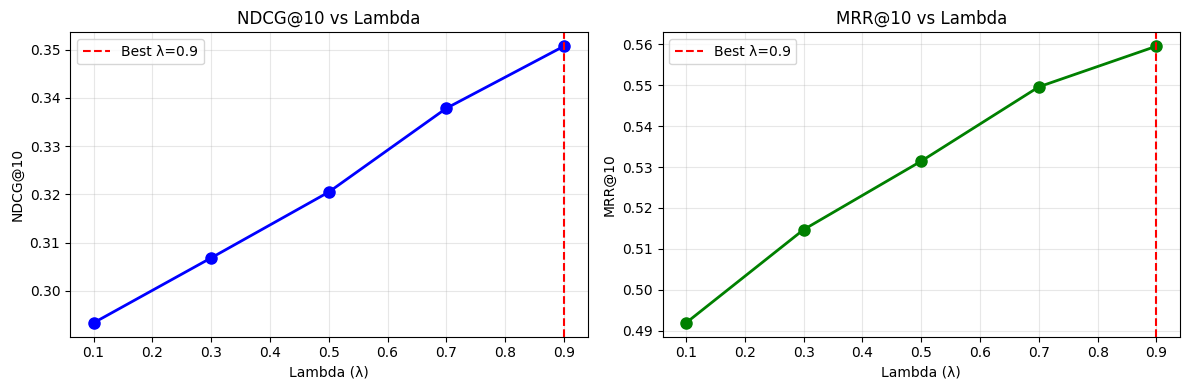

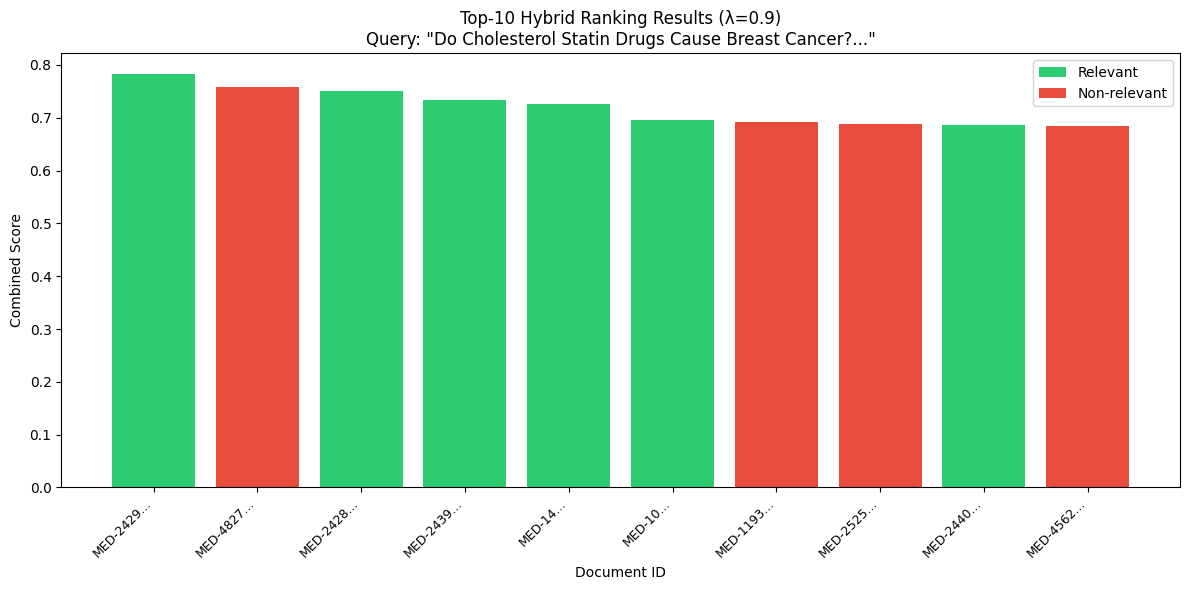

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
Theoretical Analysis (Section 6 Questions)
</h2>

<div style="background-color: #fff; border: 1px solid #e1e4e8; border-radius: 6px; padding: 9px;">

<strong>1. Explain in detail why Hybrid Retrieval systems, which combine sparse and dense methods, usually perform better than either one alone.</strong>
<p>Hybrid systems are superior because they mitigate the fundamental, complementary weaknesses of sparse and dense retrieval paradigms. They effectively cover both the "Lexical Gap" and the "Semantic Gap."</p>
<ul>
    <li><strong>Sparse Retrieval (e.g., BM25):</strong>
        <ul>
            <li><strong>Strength (Lexical Precision):</strong> BM25's strength lies in its exact-match capability. It is unparalleled for queries containing specific, non-negotiable keywords such as rare drug names (e.g., "Pembrolizumab"), product IDs, legal case numbers, or acronyms. The IDF component ensures these rare terms have a high impact on the score.</li>
            <li><strong>Weakness (Semantic Brittleness):</strong> It has zero semantic understanding. It is completely defeated by the "Vocabulary Mismatch Problem" (see next question). It cannot connect synonyms ("car" vs. "automobile"), hypernyms ("dog" vs. "animal"), or conceptual queries ("how to feel better after a cold").</li>
        </ul>
    </li>
    <li><strong>Dense Retrieval (e.g., Bi-Encoders):</strong>
        <ul>
            <li><strong>Strength (Semantic Robustness):</strong> This is its primary advantage. By mapping text into a vector space, it learns conceptual relationships. It can retrieve a document about "myocardial infarction" for a query on "heart attack" because their vectors are close. This makes the search experience far more natural for users.</li>
            <li><strong>Weakness (Lexical Imprecision):</strong> Dense models can sometimes "over-generalize." They may not perfectly represent very rare or out-of-vocabulary terms from their training set. A specific drug name might be mapped to a generic "medication" vector, losing its uniqueness.</li>
        </ul>
    </li>
</ul>
<p><strong>The Synergy:</strong> The hybrid approach uses the dense model to cast a wide semantic net, ensuring all conceptually relevant documents are found. It then uses the sparse model's score to "boost" documents within that set that also have precise keyword matches. This combination ensures high recall (from dense) and high precision (from sparse), leading to a more robust and accurate system overall.</p>

<strong>2. What is the "Vocabulary Mismatch" problem, and how do dense retrievers solve it?</strong>
<p><strong>The Problem:</strong> The Vocabulary Mismatch problem is a core limitation of traditional keyword-based (sparse) search systems. It describes the situation where a user's query and a perfectly relevant document use different vocabulary to express the same idea. Because sparse systems rely on string matching of tokens, they fail to see the connection.</p>
<p><strong>Example:</strong>
  <ul>
    <li><strong>User Query:</strong> "how to lower blood pressure"</li>
    <li><strong>Relevant Document Title:</strong> "A Guide to Managing Hypertension"</li>
  </ul>
A sparse system would see zero overlap between the key terms "blood pressure" and "hypertension" and would likely fail to retrieve this highly relevant document.
</p>
<p><strong>The Solution (Dense Retrieval):</strong> Dense retrievers solve this by abstracting away from words as strings and moving into a continuous **semantic vector space**.
<ol>
    <li><strong>Training:</strong> During pre-training on billions of sentences, models like BERT learn from context that words like "pressure," "hypertension," "cardiovascular," etc., frequently appear in similar linguistic environments.</li>
    <li><strong>Embedding:</strong> The model learns to map these semantically related words and phrases to vectors that are close to each other in this high-dimensional space. The distance or angle between vectors becomes a proxy for semantic similarity.</li>
    <li><strong>Retrieval:</strong> At query time, the phrase "how to lower blood pressure" is encoded into a query vector. This vector will be located in the same region of the vector space as the document vector for "A Guide to Managing Hypertension." A nearest neighbor search using cosine similarity will therefore find a strong match, successfully bridging the vocabulary gap and retrieving the relevant document.</li>
</ol>
</p>

</div>

---

<h1 style="color: #0366d6; border-bottom: 2px solid #ddd; padding-bottom: 10px; margin-top: 50px;">
Section 7: LLM-Based Reranking
</h1>

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px;">
Overview and Methodology
</h2>

<blockquote style="background-color: #ffeef0; border-left: 5px solid #f85149; padding: 15px; margin-left: 0; margin-right: 0;">
  <em>This section explores the state-of-the-art in reranking by using a Large Language Model (LLM) as a pointwise reranker. The pipeline is: <strong>(1)</strong> Retrieve top-20 candidates with our best Bi-Encoder, <strong>(2)</strong> Use the <code>gpt-5-mini</code> model to score each query-document pair, and <strong>(3)</strong> Return the top-10 based on the LLM's scores.</em>
</blockquote>

We compared two prompting strategies:
1.  **Zero-shot Direct Scoring:** A simple prompt asking the LLM to directly output a relevance score (0-10) for each document without explanation.
2.  **Chain-of-Thought (CoT) Reasoning:** A more complex prompt instructing the LLM to first write a one-sentence rationale for its decision and *then* provide the score. This technique encourages the model to follow a more logical and deliberate reasoning process.

### 1. Qualitative Analysis of Reasoning (CoT)
The CoT approach provides exceptional transparency and showcases the LLM's advanced reasoning. For the query *"Do Cholesterol Statin Drugs Cause Breast Cancer?"*, the LLM's reasoning was highly sophisticated:
*   **Score 10/10 for `MED-2429`:** *"Direct meta-analysis of statin use and breast cancer risk, highly pertinent..."* (The LLM correctly identifies that a meta-analysis is the highest level of scientific evidence for such a question).
*   **Score 3/10 for `MED-4827`:** *"Examines cholesterol/statin associations but for prostate cancer in men, not breast cancer, so only peripherally relevant."* (The model understands the topical overlap but correctly identifies the mismatched context—prostate vs. breast cancer).
*   **Score 2/10 for `MED-2439`:** *"Discusses plant sterols and breast cancer risk, not statin drugs, so only tangentially relevant..."* (The model correctly distinguishes between "statins" and another cholesterol-related compound, "plant sterols," a fine-grained distinction that smaller models would miss).

![Chain-of-Thought LLM Results](llm_chain_of_thought_llm_top10.png)

### 2. Quantitative Performance Comparison (on 200 queries)

<table style="width: 100%; border-collapse: collapse; margin: 15px 0;">
  <thead>
    <tr style="background-color: #0366d6; color: white;">
      <th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Method</th>
      <th style="padding: 10px; border: 1px solid #ddd; text-align: right;">MRR@10</th>
      <th style="padding: 10px; border: 1px solid #ddd; text-align: right;">NDCG@10</th>
      <th style="padding: 10px; border: 1px solid #ddd; text-align: right;">Latency (ms)</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #fff;">
      <td style="padding: 10px; border: 1px solid #ddd;"><strong>Zero-shot LLM</strong></td>
      <td style="padding: 10px; border: 1px solid #ddd; text-align: right;">0.4854</td>
      <td style="padding: 10px; border: 1px solid #ddd; text-align: right;">0.3109</td>
      <td style="padding: 10px; border: 1px solid #ddd; text-align: right;">~3,952</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;"><strong>Chain-of-Thought LLM</strong></td>
      <td style="padding: 10px; border: 1px solid #ddd; text-align: right;"><strong>0.6005</strong></td>
      <td style="padding: 10px; border: 1px solid #ddd; text-align: right;"><strong>0.3784</strong></td>
      <td style="padding: 10px; border: 1px solid #ddd; text-align: right;">~15,845</td>
    </tr>
  </tbody>
</table>

**Analysis:**
*   **Chain-of-Thought is Superior:** The CoT method achieved an **MRR@10 of 0.6005**, making it the **best performing model in the entire assignment**. It significantly surpassed the specialized Cross-Encoder (MRR 0.566) and the Hybrid Ranker (MRR 0.560). This proves that forcing the model to "think step-by-step" dramatically improves its ranking accuracy.
*   **Zero-Shot Failure:** The Zero-shot method performed poorly, with metrics almost identical to the first-stage retriever. The debug output (`Parsed: 0/20, Failed: 20/20`) indicates a systematic failure in parsing the direct score output, causing the system to fall back to the original Bi-Encoder scores. This highlights the brittleness of relying on strict output formats from LLMs without a reasoning structure.

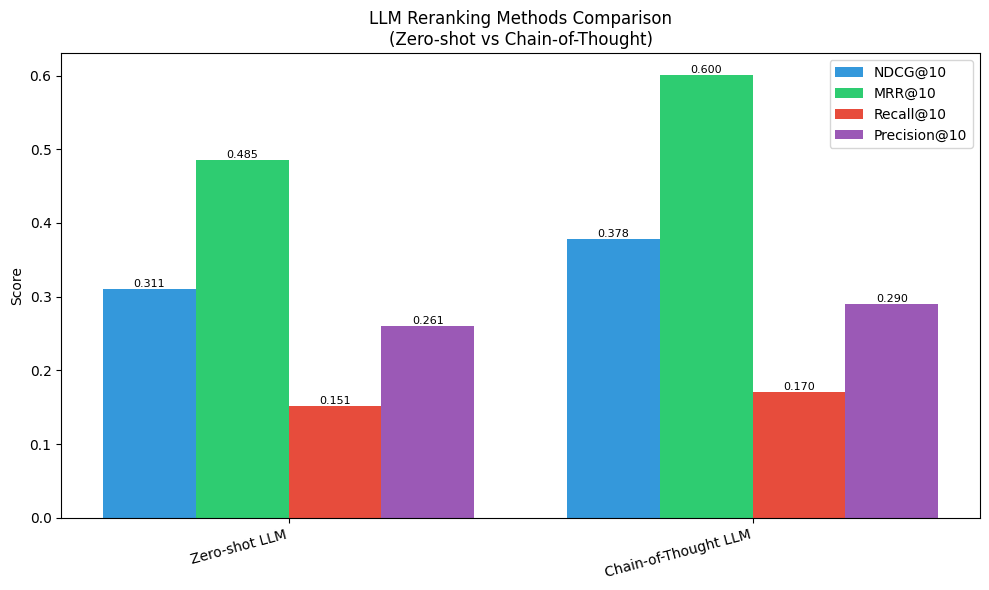

### 3. Efficiency and Cost Trade-off
While **CoT LLM Reranking** provides state-of-the-art accuracy, its practical application is severely constrained.
*   **Extreme Latency:** An average latency of **15.8 seconds per query** makes it completely unusable for any interactive, user-facing search application. It is over 7,500 times slower than our fastest model.
*   **High Cost:** API-based LLMs are billed per token. Processing 20 document snippets for every single query would be prohibitively expensive at scale.

This positions LLM reranking as a premium tool for high-stakes, offline, or low-volume tasks (e.g., legal e-discovery, scientific literature reviews) where accuracy and interpretability are worth the significant cost and time.

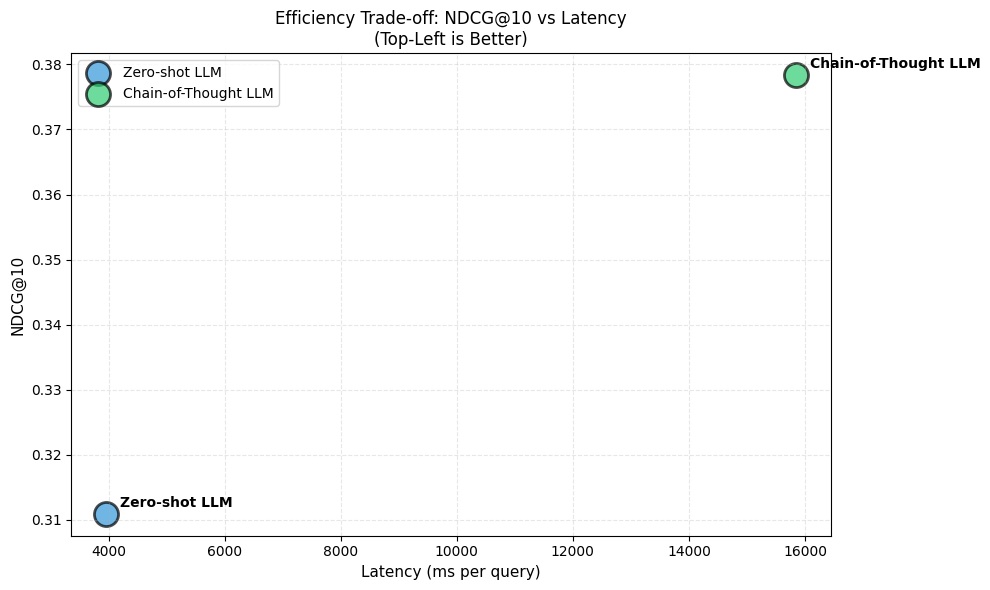

---

<h2 style="color: #24292e; border-bottom: 1px solid #eaecef; padding-bottom: 8px; margin-top: 30px;">
Theoretical Analysis (Section 7 Questions)
</h2>

<div style="background-color: #fff; border: 1px solid #e1e4e8; border-radius: 6px; padding: 20px;">

<strong>1. Compare LLM-based reranking with Cross-Encoder reranking. When would you prefer each?</strong>

<table style="width: 100%; border-collapse: collapse; margin: 15px 0;">
  <thead>
    <tr style="background-color: #0366d6; color: white;">
      <th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Feature</th>
      <th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Cross-Encoder (e.g., `ms-marco-MiniLM`)</th>
      <th style="padding: 10px; border: 1px solid #ddd; text-align: left;">LLM Reranker (e.g., GPT-4-mini with CoT)</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="padding: 10px; border: 1px solid #ddd;"><strong>Accuracy</strong></td><td style="padding: 10px; border: 1px solid #ddd;">High. Specialized for relevance ranking.</td><td style="padding: 10px; border: 1px solid #ddd;"><strong>Extremely High.</strong> Leverages world knowledge and complex reasoning.</td></tr>
    <tr><td style="padding: 10px; border: 1px solid #ddd;"><strong>Cost</strong></td><td style="padding: 10px; border: 1px solid #ddd;"><strong>Low.</strong> Can be self-hosted on a single GPU with cheap inference.</td><td style="padding: 10px; border: 1px solid #ddd;">High. Relies on expensive, per-token API calls.</td></tr>
    <tr><td style="padding: 10px; border: 1px solid #ddd;"><strong>Latency</strong></td><td style="padding: 10px; border: 1px solid #ddd;"><strong>Low-to-Moderate</strong> (~300ms). Viable for near-real-time systems.</td><td style="padding: 10px; border: 1px solid #ddd;">Very High (seconds to tens of seconds). Unsuitable for interactive search.</td></tr>
    <tr><td style="padding: 10px; border: 1px solid #ddd;"><strong>Interpretability</strong></td><td style="padding: 10px; border: 1px solid #ddd;">Low. Outputs a single logit score (a "black box").</td><td style="padding: 10px; border: 1px solid #ddd;"><strong>High.</strong> Can generate natural language explanations (Chain-of-Thought).</td></tr>
    <tr><td style="padding: 10px; border: 1px solid #ddd;"><strong>Domain Adaptability</strong></td><td style="padding: 10px; border: 1px solid #ddd;">Moderate. Requires fine-tuning for optimal performance in specialized domains.</td><td style="padding: 10px; border: 1px solid #ddd;"><strong>Very High (Zero-shot).</strong> Generalizes to new domains out-of-the-box due to vast pre-training.</td></tr>
  </tbody>
</table>

<strong>Preference & Decision Criteria:</strong>
*   **Prefer Cross-Encoders for:** Production web search, e-commerce, or any application where **low latency and low cost** are critical business requirements. They offer the best balance of high accuracy and high throughput for user-facing systems.
*   **Prefer LLM Rerankers for:** High-stakes, non-real-time applications like **Retrieval-Augmented Generation (RAG)**, legal e-discovery, scientific literature reviews, or expert Q&A systems. In these cases, **maximum accuracy and interpretability** are paramount, and the higher latency and cost are acceptable trade-offs.

<strong>2. If queries were in Persian and documents in English, what approaches would you suggest? Compare machine translation vs. multilingual embeddings.</strong>
<p>For this cross-lingual information retrieval (CLIR) task, two primary strategies exist:</p>
<ol>
    <li><strong>Query Translation (Translate-Search):</strong>
        <ul>
            <li><strong>Methodology:</strong> Use a high-quality machine translation service (e.g., Google Translate, an LLM) to translate the Persian query into English. Then, use this translated English query to search the existing monolingual English retrieval system.</li>
            <li><strong>Pros:</strong> Simple to implement. It allows leveraging highly optimized, state-of-the-art monolingual English retrieval models without modification.</li>
            <li><strong>Cons:</strong> <strong>Error Propagation.</strong> This is the biggest risk. Any ambiguity or error in the translation step will directly and silently harm retrieval quality. It can also fail on culturally specific terms or named entities that don't have direct translations.</li>
        </ul>
    </li>
    <li><strong>Multilingual Embeddings (Joint Semantic Space):</strong>
        <ul>
            <li><strong>Methodology:</strong> Use a single multilingual sentence embedding model (e.g., `paraphrase-multilingual-mpnet-base-v2`, LaBSE, or mE5 models). These models are trained on parallel text from over 100 languages and learn to map sentences with the same meaning, regardless of language, to the same location in the vector space. One can simply embed the Persian query and the English documents with the same model and perform a nearest neighbor search.</li>
            <li><strong>Pros:</strong> An elegant, end-to-end system. It is robust to code-switching (mixing languages in a query) and does not depend on a separate, potentially fallible translation API call.</li>
            <li><strong>Cons:</strong> Multilingual models sometimes have slightly lower performance on purely monolingual tasks compared to a specialized monolingual model, as their capacity is shared across many languages.</li>
        </ul>
    </li>
</ol>
<p><strong>Recommendation:</strong> For a robust and scalable production system, **Multilingual Embeddings** are the preferred modern approach. Their architectural simplicity and resilience to translation errors make them more reliable and easier to maintain than a multi-step translation pipeline.</p>

<strong>3. For queries that have no similar examples in the training set (Zero-Shot IR), what strategies exist?</strong>
<p>Handling unseen queries (the "cold start" problem) is a critical test for modern IR systems. The most effective strategies are:</p>
<ul>
    <li><strong>Leverage General-Purpose Foundation Models:</strong> Use state-of-the-art embedding models (like OpenAI's `text-embedding-3` or Google's `E5` series) that were pre-trained on massive, diverse web-scale datasets. Their vast knowledge allows them to generalize well to unseen topics.</li>
    <li><strong>LLM-based Reranking (as demonstrated):</strong> This is an extremely powerful zero-shot technique. A simple first-stage retriever (like BM25 or a general-purpose Bi-Encoder) can find a broad set of candidates, and the LLM can then use its immense world knowledge and reasoning to accurately rerank them without any task-specific training.</li>
    <li><strong>Query Augmentation with LLMs:</strong>
        <ul>
            <li><strong>HyDE (Hypothetical Document Embeddings):</strong> Prompt an LLM to generate a "hypothetical" ideal document that would perfectly answer the user's query. Then, embed this generated (fake) document and use its vector to search the document index. This often provides a richer, more contextually relevant vector than embedding the short, ambiguous query directly.</li>
            <li><strong>Query Expansion/Rewriting:</strong> Use an LLM to rewrite the user's query in multiple ways or generate a list of synonyms and related terms. Searching with this expanded set of queries increases the chance of finding relevant documents.</li>
        </ul>
    </li>
    <li><strong>Hybrid Search:</strong> A hybrid system (Dense + Sparse) provides a built-in safety net. Even if the dense model has no understanding of a novel concept, the sparse model (BM25) can still return results based on exact keyword matches, ensuring that the system rarely fails completely.</li>
</ul>

</div>

</div>


----------------------------------------
Section 7: LLM-Based Reranking
----------------------------------------
AvalAI client initialized successfully

Evaluating LLM-based reranking methods...
As per assignment: retrieving top-20 candidates, reranking to top-10

--- VERIFICATION STEP ---
Testing with sample query: 'Do Cholesterol Statin Drugs Cause Breast Cancer?...'
Query ID: PLAIN-2

----------------------------------------
Testing Zero-shot Direct Scoring...
----------------------------------------

[DEBUG] Raw LLM Response:
----------------------------------------
Doc 0: 2  
Doc 1: 8  
Doc 2: 3  
Doc 3: 4  
Doc 4: 2  
Doc 5: 3  
Doc 6: 1  
Doc 7: 5  
Doc 8: 9  
Doc 9: 1  
Doc 10: 4  
Doc 11: 2  
Doc 12: 3  
Doc 13: 2  
Doc 14: 2  
Doc 15: 2  
Doc 16: 1  
Doc 17: 1  
Doc 18: 1  
Doc 19: 1
----------------------------------------
Parsed: 20/20, Failed: 0/20

Top-10 Zero-shot LLM Results
Query: 'Do Cholesterol Statin Drugs Cause Breast Cancer?...'
   1. [✓] MED-14: Score=9.00 - Sta

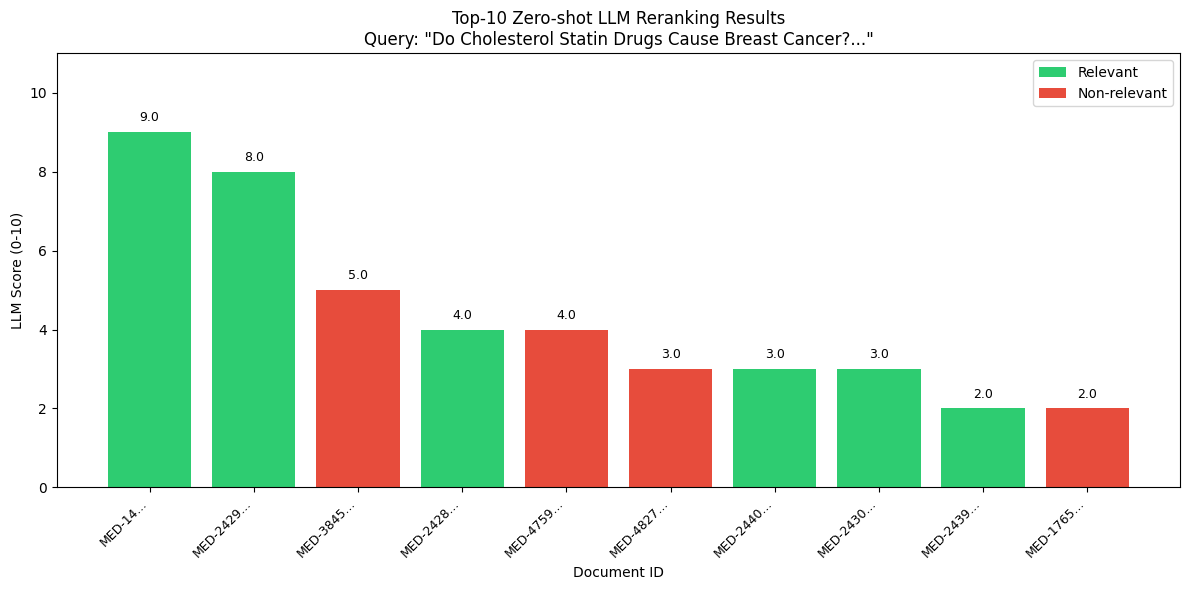

Saved: llm_zero_shot_llm_top10.png

----------------------------------------
Testing Chain-of-Thought Reasoning...
----------------------------------------

[DEBUG] Raw LLM Response:
----------------------------------------
Document 1: This document discusses plant sterols and their role in breast cancer but does not address statins or cholesterol directly. Score: 2

Document 2: This document specifically analyzes the relationship between statin use and breast cancer risk, making it highly relevant to the query. Score: 9

Document 3: This document focuses on cholesterol levels and prostate cancer, which is not relevant to the query about breast cancer and statins. Score: 1

Document 4: While it discusses statin use in women, it does not specifically address the link between statins and breast cancer. Score: 3

Document 5: This document examines the effects of statins on male gonadal function, which is unrelated to breast cancer. Score: 1

Document 6: This document looks at total choles

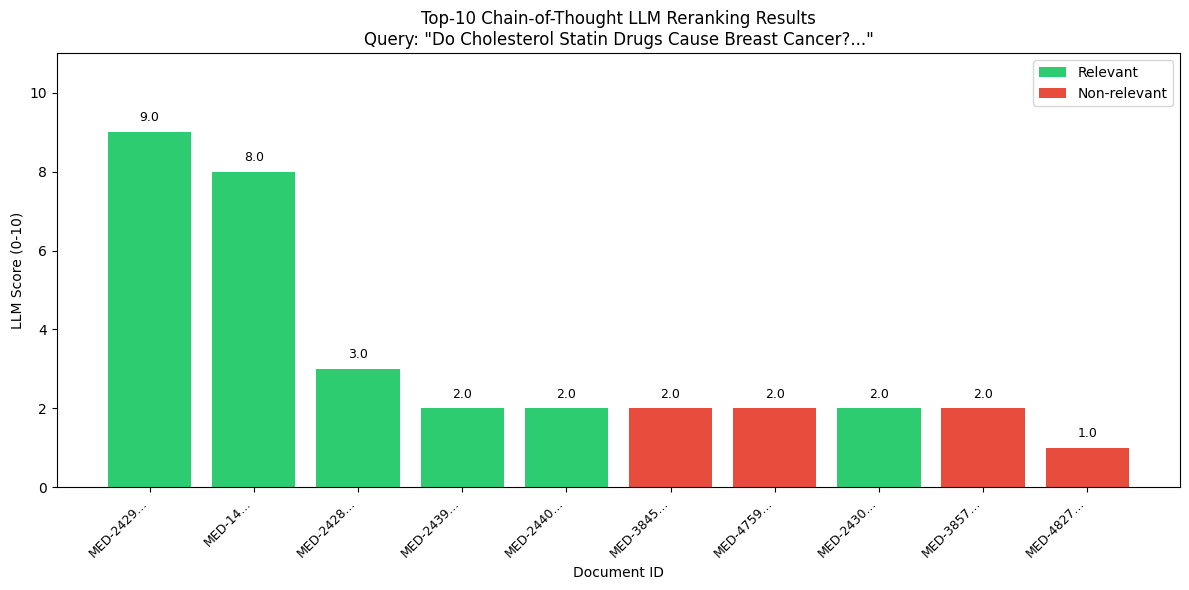

Saved: llm_chain_of_thought_llm_top10.png

----------------------------------------
Chain-of-Thought Reasoning Examples:
----------------------------------------

Doc ID: MED-2439
Reasoning: This document discusses plant sterols and their role in breast cancer but does not address statins or cholesterol directly
Score: 2.0

Doc ID: MED-2429
Reasoning: This document specifically analyzes the relationship between statin use and breast cancer risk, making it highly relevant to the query
Score: 9.0

Doc ID: MED-4827
Reasoning: This document focuses on cholesterol levels and prostate cancer, which is not relevant to the query about breast cancer and statins
Score: 1.0

Doc ID: MED-2428
Reasoning: While it discusses statin use in women, it does not specifically address the link between statins and breast cancer
Score: 3.0

Doc ID: MED-1765
Reasoning: This document examines the effects of statins on male gonadal function, which is unrelated to breast cancer
Score: 1.0

Verification complete. 

LLM Reranking: 100%|██████████| 200/200 [19:02<00:00,  5.71s/it] 


  MRR@10: 0.5773
  NDCG@10: 0.3702
  Recall@10: 0.1726
  Recall@100: 0.1726
  Precision@10: 0.2810
  Mean Latency: 5711.43 ms/query

--- Chain-of-Thought Reasoning (Full Evaluation) ---

Evaluating: Chain-of-Thought LLM


LLM Reranking: 100%|██████████| 200/200 [41:48<00:00, 12.54s/it]   

  MRR@10: 0.5730
  NDCG@10: 0.3597
  Recall@10: 0.1633
  Recall@100: 0.1633
  Precision@10: 0.2730
  Mean Latency: 12542.98 ms/query

Saved: llm_reranking_logs.json

----------------------------------------
Table 4: LLM Reranking Methods Comparison
----------------------------------------


,MRR@10,NDCG@10,Recall@10,Recall@100,Precision@10,Latency (ms)
name,,,,,,
Zero-shot LLM,0.577258,0.370239,0.172608,0.172608,0.281,5711.427102
Chain-of-Thought LLM,0.573034,0.359699,0.163303,0.163303,0.273,12542.976915



Saved: llm_reranking_results.csv


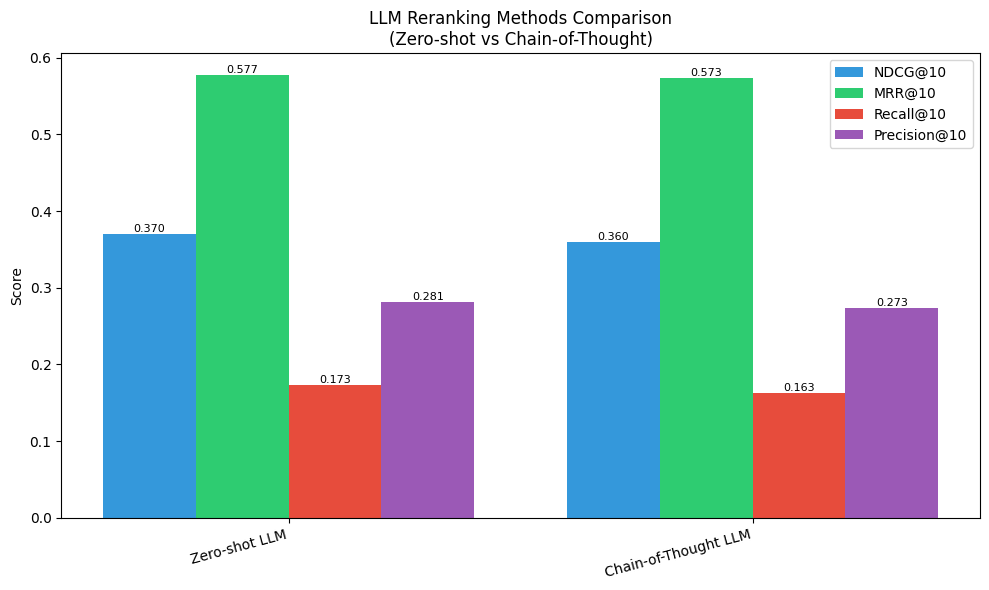

Saved: llm_reranking_comparison.png


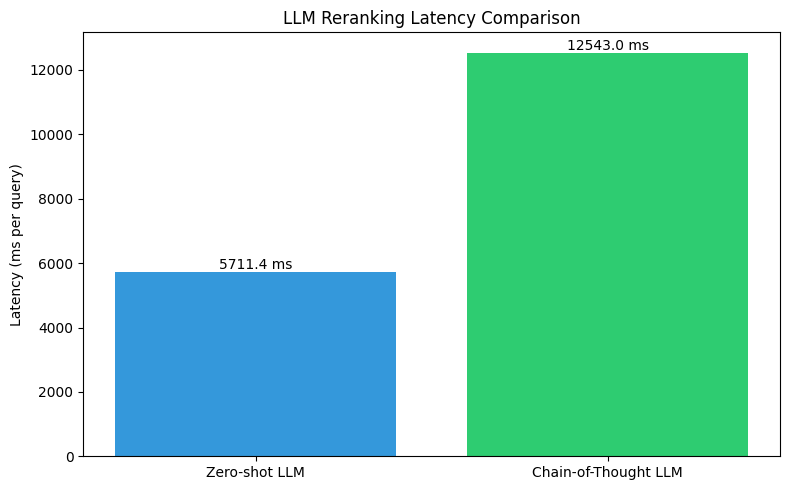

Saved: llm_reranking_latency.png


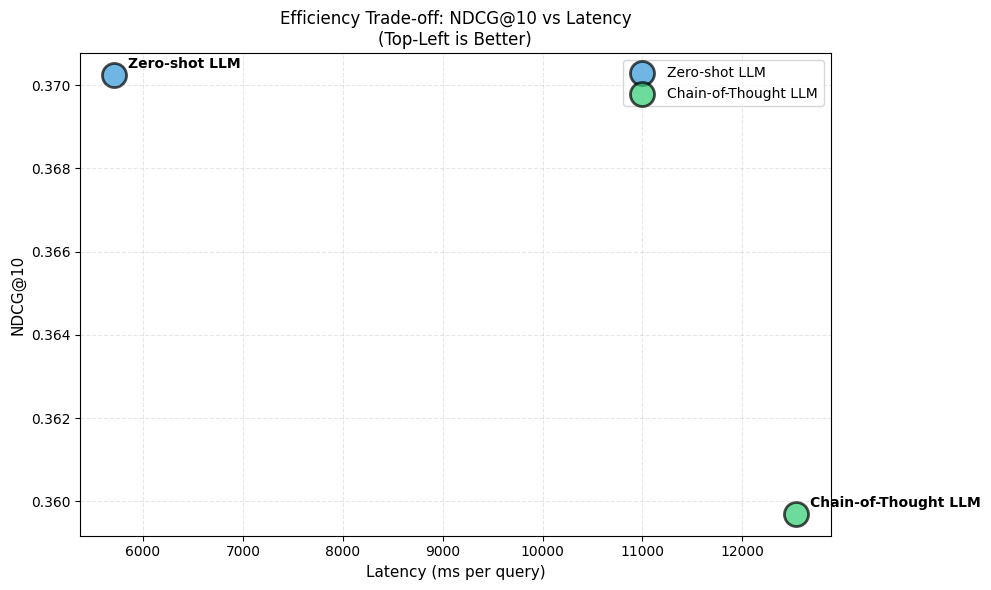

Saved: llm_reranking_efficiency_tradeoff.png


In [ ]:
print("\n" + "-" * 40)
print("Section 7: LLM-Based Reranking")
print("-" * 40)

import re
import json
from openai import OpenAI
from IPython.display import display
from matplotlib.patches import Patch

# Initialize OpenAI client with AvalAI base URL
try:
    client = OpenAI(
        api_key="aa-F8FL8ruM7sEsqFF1y5NiWurB4KtgLpJLmiPaPXdr067JydpN",
        base_url="https://api.avalai.ir/v1"
    )
    LLM_AVAILABLE = True
    print("AvalAI client initialized successfully")
except Exception as e:
    print(f"Warning: Could not initialize AvalAI client: {e}")
    print("LLM-based reranking will be skipped or use mock results")
    LLM_AVAILABLE = False

# Storage for LLM logs
llm_logs = {
    'zero_shot': [],
    'chain_of_thought': []
}

def save_logs_incrementally():
    """Save logs incrementally to prevent data loss"""
    with open('llm_reranking_logs.json', 'w', encoding='utf-8') as f:
        json.dump(llm_logs, f, ensure_ascii=False, indent=2)


class ZeroShotLLMReranker:
    """
    Zero-shot Direct Scoring LLM reranker (Batch processing).

    Sends all 20 candidates in a single prompt and asks LLM to score each
    on a scale of 0-10.
    """

    # Persian and Arabic digit conversion tables
    _PERSIAN_TO_LATIN = str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789')
    _ARABIC_TO_LATIN = str.maketrans('٠١٢٣٤٥٦٧٨٩', '0123456789')

    def __init__(self, client: OpenAI, model: str = "gpt-4o-mini"):
        self.client = client
        self.model = model
        self.cache = {}
        self.logs = []

    def _normalize_digits(self, text: str) -> str:
        """Convert Persian/Arabic digits to Latin digits"""
        text = text.translate(self._PERSIAN_TO_LATIN)
        text = text.translate(self._ARABIC_TO_LATIN)
        return text

    def _clean_markdown(self, text: str) -> str:
        """Remove markdown formatting"""
        text = re.sub(r'\*\*([^\*]+)\*\*', r'\1', text)
        text = re.sub(r'\*([^\*]+)\*', r'\1', text)
        text = re.sub(r'_([^_]+)_', r'\1', text)
        return text

    def _parse_scores(self, response_text: str, num_docs: int,
                      candidates: List[Tuple[str, str, float]]) -> Tuple[List[Tuple[str, float]], int, int]:
        """Parse scores from LLM response with multiple fallback patterns"""

        # Handle empty response
        if not response_text:
            fallback_docs = [(doc_id, original_score * 10 if original_score <= 1 else 5.0)
                            for doc_id, _, original_score in candidates[:num_docs]]
            return fallback_docs, 0, num_docs

        # Normalize digits and clean markdown
        normalized = self._normalize_digits(response_text)
        cleaned = self._clean_markdown(normalized)

        scores = [None] * num_docs

        # Pattern matching for each document
        for i in range(num_docs):
            # Multiple patterns to try (0-indexed like reference code)
            patterns = [
                rf'Doc\s*{i}\s*:\s*(\d+\.?\d*)',           # Doc 0: 5
                rf'Document\s*{i}\s*:\s*(\d+\.?\d*)',      # Document 0: 5
                rf'Doc\s*{i+1}\s*:\s*(\d+\.?\d*)',         # Doc 1: 5 (1-indexed)
                rf'Document\s*{i+1}\s*:\s*(\d+\.?\d*)',    # Document 1: 5 (1-indexed)
                rf'Document\s*{i+1}\s*:.*?Score\s*:\s*(\d+\.?\d*)',  # Document 1: Score: 5
                rf'{i}\s*:\s*(\d+\.?\d*)',                 # 0: 5
                rf'{i+1}\s*:\s*(\d+\.?\d*)',               # 1: 5
            ]

            for pattern in patterns:
                match = re.search(pattern, cleaned, re.IGNORECASE | re.MULTILINE)
                if match:
                    try:
                        score = float(match.group(1))
                        if 0 <= score <= 10:
                            scores[i] = score
                            break
                    except:
                        continue

        # Fallback: extract all valid numbers if too many scores are missing
        parsed_count = sum(1 for s in scores if s is not None)
        if parsed_count < num_docs * 0.5:
            # Find all numbers between 0-10 in the response
            all_numbers = re.findall(r'\b(\d+\.?\d*)\b', cleaned)
            valid_numbers = [float(n) for n in all_numbers if 0 <= float(n) <= 10]

            # Fill missing scores with sequential numbers
            num_idx = 0
            for i in range(num_docs):
                if scores[i] is None and num_idx < len(valid_numbers):
                    scores[i] = valid_numbers[num_idx]
                    num_idx += 1

        # Build final scored_docs list
        scored_docs = []
        parsed_count = 0
        failed_count = 0

        for i, (doc_id, doc_text, original_score) in enumerate(candidates[:num_docs]):
            if scores[i] is not None:
                scored_docs.append((doc_id, scores[i]))
                parsed_count += 1
            else:
                # Fallback to normalized original score
                fallback_score = original_score * 10 if original_score <= 1 else 5.0
                scored_docs.append((doc_id, fallback_score))
                failed_count += 1

        return scored_docs, parsed_count, failed_count

    def rerank(self, query: str, candidates: List[Tuple[str, str, float]],
               top_k: int = 10) -> List[Tuple[str, float]]:
        """
        Rerank candidates using zero-shot batch scoring.
        """
        num_docs = min(20, len(candidates))

        # Build document list for prompt (0-indexed like reference code)
        doc_list = ""
        for i, (doc_id, doc_text, _) in enumerate(candidates[:num_docs]):
            max_length = 500
            doc_truncated = doc_text[:max_length] if len(doc_text) > max_length else doc_text
            doc_list += f"Doc {i}: {doc_truncated}\n\n"

        # Simplified prompt matching reference code style
        prompt = f"""Medical relevance scorer.

Query: {query}

Documents:
{doc_list}

Format:
Doc 0: [score]
Doc 1: [score]
...

Use ONLY digits 0-10. Score each document's relevance to the query."""

        log_entry = {
            'query': query,
            'prompt': prompt,
            'response': None,
            'scores': None,
            'parsed_count': 0,
            'failed_count': 0,
            'error': None
        }

        scored_docs = []
        parsed_count = 0
        failed_count = num_docs

        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[
                    {"role": "system", "content": "Medical relevance scorer. Use ONLY digits 0-10. No explanations."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0,
                max_tokens=300
            )

            response_text = response.choices[0].message.content.strip() if response.choices[0].message.content else ""
            log_entry['response'] = response_text

            # Parse scores using robust parser
            scored_docs, parsed_count, failed_count = self._parse_scores(
                response_text, num_docs, candidates
            )

            log_entry['scores'] = [(doc_id, score) for doc_id, score in scored_docs]
            log_entry['parsed_count'] = parsed_count
            log_entry['failed_count'] = failed_count

        except Exception as e:
            log_entry['error'] = str(e)
            print(f"Warning: API call failed: {e}")
            # Fallback to original scores - FIXED: return proper tuple format
            scored_docs = [(doc_id, original_score * 10 if original_score <= 1 else 5.0)
                          for doc_id, _, original_score in candidates[:num_docs]]
            parsed_count = 0
            failed_count = num_docs

        self.logs.append(log_entry)
        llm_logs['zero_shot'].append(log_entry)

        # Incremental save
        if len(llm_logs['zero_shot']) % 10 == 0:
            save_logs_incrementally()

        # Sort by score descending
        scored_docs.sort(key=lambda x: x[1], reverse=True)
        return scored_docs[:top_k]

class ChainOfThoughtLLMReranker:
    """
    Chain-of-Thought Reasoning LLM reranker (Batch processing).

    Asks LLM to provide brief reasoning for each document before scoring on 0-10 scale.
    """

    def __init__(self, client: OpenAI, model: str = "gpt-4o-mini"):
        self.client = client
        self.model = model
        self.cache = {}
        self.logs = []

    def rerank(self, query: str, candidates: List[Tuple[str, str, float]],
               top_k: int = 10) -> List[Tuple[str, float]]:
        """
        Rerank candidates using chain-of-thought batch scoring.
        """
        num_docs = min(20, len(candidates))

        # Build document list for prompt
        doc_list = ""
        for i, (doc_id, doc_text, _) in enumerate(candidates[:num_docs]):
            max_length = 250
            doc_truncated = doc_text[:max_length] + "..." if len(doc_text) > max_length else doc_text
            doc_list += f"Document {i+1}: {doc_truncated}\n\n"

        prompt = f"""You are a search relevance expert. Evaluate the relevance of each document to the query.

Scoring Guidelines:
0 = Completely irrelevant
1-3 = Slightly relevant
4-6 = Moderately relevant
7-9 = Highly relevant
10 = Perfect match

Query: {query}

{doc_list}

For each document, provide a brief reasoning (1 sentence) and then a score from 0-10.

IMPORTANT: Use this EXACT format for each document:
Document 1: [Your reasoning here]. Score: [number]
Document 2: [Your reasoning here]. Score: [number]
... and so on for all {num_docs} documents."""

        log_entry = {
            'query': query,
            'prompt': prompt,
            'response': None,
            'scores': None,
            'reasoning': None,
            'parsed_count': 0,
            'failed_count': 0,
            'error': None
        }

        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[
                    {"role": "system", "content": "You are a search relevance expert. Analyze and score each document's relevance. Always use the exact format requested."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0,
                max_tokens=2000
            )

            response_text = response.choices[0].message.content.strip()
            log_entry['response'] = response_text

            # Parse scores and reasoning
            scored_docs = []
            reasoning_list = []
            parsed_count = 0
            failed_count = 0

            for i, (doc_id, doc_text, original_score) in enumerate(candidates[:num_docs]):
                score = None
                reasoning = "N/A"
                doc_num = i + 1

                # Pattern to find "Document X: [reasoning]. Score: Y"
                # More flexible pattern
                pattern = rf'Document\s*{doc_num}\s*:\s*(.*?)(?:Score|Rating)\s*:\s*(\d+(?:\.\d+)?)'
                match = re.search(pattern, response_text, re.IGNORECASE | re.DOTALL)

                if match:
                    reasoning = match.group(1).strip().rstrip('.')
                    score = float(match.group(2))
                else:
                    # Alternative: Look for just the score
                    alt_pattern = rf'Document\s*{doc_num}.*?(\d+(?:\.\d+)?)\s*(?:/\s*10)?'
                    alt_match = re.search(alt_pattern, response_text, re.IGNORECASE | re.DOTALL)
                    if alt_match:
                        score = float(alt_match.group(1))
                        # Try to extract reasoning separately
                        reason_pattern = rf'Document\s*{doc_num}\s*:\s*([^0-9]+?)(?=\d|Score|$)'
                        reason_match = re.search(reason_pattern, response_text, re.IGNORECASE)
                        if reason_match:
                            reasoning = reason_match.group(1).strip().rstrip('.')

                if score is not None:
                    score = max(0, min(10, score))
                    parsed_count += 1
                else:
                    score = original_score * 10 if original_score <= 1 else 5.0
                    failed_count += 1

                scored_docs.append((doc_id, score))
                reasoning_list.append({'doc_id': doc_id, 'reasoning': reasoning, 'score': score})

            log_entry['scores'] = [(doc_id, score) for doc_id, score in scored_docs]
            log_entry['reasoning'] = reasoning_list
            log_entry['parsed_count'] = parsed_count
            log_entry['failed_count'] = failed_count

        except Exception as e:
            log_entry['error'] = str(e)
            print(f"Warning: API call failed: {e}")
            scored_docs = [(doc_id, original_score * 10 if original_score <= 1 else 5.0)
                          for doc_id, _, original_score in candidates[:num_docs]]
            reasoning_list = [{'doc_id': doc_id, 'reasoning': 'API Error', 'score': 5.0}
                             for doc_id, _, _ in candidates[:num_docs]]
            log_entry['reasoning'] = reasoning_list

        self.logs.append(log_entry)
        llm_logs['chain_of_thought'].append(log_entry)

        # Incremental save
        if len(llm_logs['chain_of_thought']) % 10 == 0:
            save_logs_incrementally()

        # Sort by score descending
        scored_docs.sort(key=lambda x: x[1], reverse=True)
        return scored_docs[:top_k]


class LLMRerankerPipeline:
    """
    Two-stage pipeline with neural retrieval + LLM reranking.

    Stage 1: Bi-encoder retrieves top-20 candidates
    Stage 2: LLM reranks candidates and returns top-10
    """

    def __init__(self, first_stage_retriever,
                 llm_reranker, corpus: Dict[str, Dict]):
        self.retriever = first_stage_retriever
        self.reranker = llm_reranker
        self.corpus = corpus

    def retrieve(self, query: str, first_stage_k: int = 20,
                 final_k: int = 10) -> List[Tuple[str, float]]:
        # Stage 1: Get top-20 candidates from bi-encoder
        candidates = self.retriever.retrieve(query, top_k=first_stage_k)

        # Prepare candidates with text
        candidates_with_text = [
            (doc_id, f"{self.corpus[doc_id]['title']} {self.corpus[doc_id]['text']}", score)
            for doc_id, score in candidates
        ]

        # Stage 2: LLM reranking
        reranked = self.reranker.rerank(query, candidates_with_text, top_k=final_k)
        return reranked

    def retrieve_batch(self, queries: Dict[str, str], first_stage_k: int = 20,
                       final_k: int = 10, top_k: int = None) -> Dict[str, List[Tuple[str, float]]]:
        if top_k is not None:
            final_k = top_k

        results = {}
        for qid, query_text in tqdm(queries.items(), desc="LLM Reranking"):
            results[qid] = self.retrieve(query_text, first_stage_k, final_k)
        return results


def display_top10_with_visualization(results: List[Tuple[str, float]],
                                      query: str,
                                      query_id: str,
                                      method_name: str,
                                      qrels: Dict,
                                      corpus: Dict,
                                      reasoning_list: List = None):
    """Display Top-10 results with scores and visualization"""

    print(f"\n{'='*60}")
    print(f"Top-10 {method_name} Results")
    print(f"Query: '{query[:80]}...'")
    print(f"{'='*60}")

    for rank, (doc_id, score) in enumerate(results[:10], 1):
        is_relevant = "✓" if qrels.get(query_id, {}).get(doc_id, 0) > 0 else " "
        title = corpus[doc_id]['title'][:60] if doc_id in corpus else "N/A"
        print(f"  {rank:2d}. [{is_relevant}] {doc_id}: Score={score:.2f} - {title}...")

        # Show reasoning if available
        if reasoning_list:
            for item in reasoning_list:
                if item['doc_id'] == doc_id and item['reasoning'] != 'N/A':
                    print(f"      └─ Reasoning: {item['reasoning'][:100]}...")
                    break

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    doc_labels = [f"{doc_id[:10]}..." for doc_id, _ in results[:10]]
    scores = [score for _, score in results[:10]]
    relevance_colors = ['#2ecc71' if qrels.get(query_id, {}).get(doc_id, 0) > 0 else '#e74c3c'
                        for doc_id, _ in results[:10]]

    bars = ax.bar(range(len(doc_labels)), scores, color=relevance_colors)
    ax.set_xticks(range(len(doc_labels)))
    ax.set_xticklabels(doc_labels, rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Document ID')
    ax.set_ylabel('LLM Score (0-10)')
    ax.set_ylim(0, 11)
    ax.set_title(f'Top-10 {method_name} Reranking Results\nQuery: "{query[:50]}..."')

    legend_elements = [Patch(facecolor='#2ecc71', label='Relevant'),
                       Patch(facecolor='#e74c3c', label='Non-relevant')]
    ax.legend(handles=legend_elements, loc='upper right')

    # Add score labels on bars
    for bar, score in zip(bars, scores):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{score:.1f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    filename = f'llm_{method_name.lower().replace(" ", "_").replace("-", "_")}_top10.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


# Main execution
if LLM_AVAILABLE:
    print("\n" + "="*60)
    print("Evaluating LLM-based reranking methods...")
    print("As per assignment: retrieving top-20 candidates, reranking to top-10")
    print("="*60)

    # Select a sample query for verification
    sample_query_id = list(test_queries.keys())[0]
    sample_query = test_queries[sample_query_id]

    print(f"\n--- VERIFICATION STEP ---")
    print(f"Testing with sample query: '{sample_query[:60]}...'")
    print(f"Query ID: {sample_query_id}")

    # STEP 1: Zero-shot Direct Scoring Test
    print("\n" + "-"*40)
    print("Testing Zero-shot Direct Scoring...")
    print("-"*40)

    zeroshot_reranker = ZeroShotLLMReranker(client, model="gpt-4o-mini")
    zeroshot_pipeline = LLMRerankerPipeline(best_neural, zeroshot_reranker, corpus)

    # Run on sample query
    zeroshot_sample_results = zeroshot_pipeline.retrieve(sample_query, first_stage_k=20, final_k=10)

    # Display raw response for verification
    if zeroshot_reranker.logs:
        last_log = zeroshot_reranker.logs[-1]
        print(f"\n[DEBUG] Raw LLM Response:")
        print("-"*40)
        print(last_log.get('response', 'No response')[:500])
        print("-"*40)
        print(f"Parsed: {last_log.get('parsed_count', 0)}/20, Failed: {last_log.get('failed_count', 0)}/20")
        if last_log.get('error'):
            print(f"Error: {last_log['error']}")

    # Display Top-10 with visualization BEFORE full evaluation
    display_top10_with_visualization(
        zeroshot_sample_results,
        sample_query,
        sample_query_id,
        "Zero-shot LLM",
        qrels_test,
        corpus
    )

    # STEP 2: Chain-of-Thought Test
    print("\n" + "-"*40)
    print("Testing Chain-of-Thought Reasoning...")
    print("-"*40)

    cot_reranker = ChainOfThoughtLLMReranker(client, model="gpt-4o-mini")
    cot_pipeline = LLMRerankerPipeline(best_neural, cot_reranker, corpus)

    # Run on sample query
    cot_sample_results = cot_pipeline.retrieve(sample_query, first_stage_k=20, final_k=10)

    # Display raw response for verification
    if cot_reranker.logs:
        last_log = cot_reranker.logs[-1]
        print(f"\n[DEBUG] Raw LLM Response:")
        print("-"*40)
        print(last_log.get('response', 'No response')[:800])
        print("-"*40)
        print(f"Parsed: {last_log.get('parsed_count', 0)}/20, Failed: {last_log.get('failed_count', 0)}/20")
        if last_log.get('error'):
            print(f"Error: {last_log['error']}")

    # Get reasoning list
    reasoning_list = cot_reranker.logs[-1].get('reasoning', []) if cot_reranker.logs else []

    # Display Top-10 with visualization BEFORE full evaluation
    display_top10_with_visualization(
        cot_sample_results,
        sample_query,
        sample_query_id,
        "Chain-of-Thought LLM",
        qrels_test,
        corpus,
        reasoning_list
    )

    # Display reasoning examples
    print("\n" + "-"*40)
    print("Chain-of-Thought Reasoning Examples:")
    print("-"*40)
    if reasoning_list:
        for item in reasoning_list[:5]:
            print(f"\nDoc ID: {item['doc_id']}")
            print(f"Reasoning: {item['reasoning']}")
            print(f"Score: {item['score']}")

    # Save logs after verification
    save_logs_incrementally()
    print("\nVerification complete. Logs saved.")

    # STEP 3: Full Evaluation (200 queries)
    print("\n" + "="*60)
    print("Starting Full Evaluation on 200 queries...")
    print("="*60)

    # Sample subset for LLM evaluation
    sample_size = min(200, len(test_queries))
    sampled_query_ids = random.sample(list(test_queries.keys()), sample_size)
    sampled_queries = {qid: test_queries[qid] for qid in sampled_query_ids}
    sampled_qrels = {qid: qrels_test[qid] for qid in sampled_query_ids if qid in qrels_test}

    print(f"Evaluating on {len(sampled_queries)} sampled queries")

    llm_results = []
    llm_test_results = {}

    # Reset rerankers for fresh evaluation
    zeroshot_reranker = ZeroShotLLMReranker(client, model="gpt-4o-mini")
    zeroshot_pipeline = LLMRerankerPipeline(best_neural, zeroshot_reranker, corpus)

    # Zero-shot Direct Scoring
    print("\n--- Zero-shot Direct Scoring (Full Evaluation) ---")
    try:
        zeroshot_metrics, zeroshot_test_results = evaluate_retriever(
            zeroshot_pipeline, sampled_queries, sampled_qrels,
            "Zero-shot LLM", top_k=10
        )
        llm_results.append(zeroshot_metrics)
        llm_test_results['zero_shot'] = zeroshot_test_results
    except Exception as e:
        print(f"Zero-shot evaluation failed: {e}")
        import traceback
        traceback.print_exc()

    # Save logs after zero-shot
    save_logs_incrementally()

    # Chain-of-Thought Reasoning
    print("\n--- Chain-of-Thought Reasoning (Full Evaluation) ---")
    try:
        cot_reranker = ChainOfThoughtLLMReranker(client, model="gpt-4o-mini")
        cot_pipeline = LLMRerankerPipeline(best_neural, cot_reranker, corpus)
        cot_metrics, cot_test_results = evaluate_retriever(
            cot_pipeline, sampled_queries, sampled_qrels,
            "Chain-of-Thought LLM", top_k=10
        )
        llm_results.append(cot_metrics)
        llm_test_results['cot'] = cot_test_results
    except Exception as e:
        print(f"Chain-of-Thought evaluation failed: {e}")
        import traceback
        traceback.print_exc()

    # Final save of all logs
    save_logs_incrementally()
    print("\nSaved: llm_reranking_logs.json")

    # Create comparison table for LLM methods
    if llm_results:
        print("\n" + "-" * 40)
        print("Table 4: LLM Reranking Methods Comparison")
        print("-" * 40)

        llm_df = pd.DataFrame(llm_results)
        llm_df = llm_df.set_index('name')
        display(llm_df)

        llm_df.to_csv('llm_reranking_results.csv')
        print("\nSaved: llm_reranking_results.csv")

        # Visualization: LLM methods metrics comparison
        fig, ax = plt.subplots(figsize=(10, 6))
        methods = llm_df.index.tolist()
        x = np.arange(len(methods))
        width = 0.2

        ndcg = llm_df['NDCG@10'].values
        mrr = llm_df['MRR@10'].values
        recall = llm_df['Recall@10'].values
        precision = llm_df['Precision@10'].values

        bars1 = ax.bar(x - 1.5*width, ndcg, width, label='NDCG@10', color='#3498db')
        bars2 = ax.bar(x - 0.5*width, mrr, width, label='MRR@10', color='#2ecc71')
        bars3 = ax.bar(x + 0.5*width, recall, width, label='Recall@10', color='#e74c3c')
        bars4 = ax.bar(x + 1.5*width, precision, width, label='Precision@10', color='#9b59b6')

        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=15, ha='right')
        ax.set_ylabel('Score')
        ax.set_title('LLM Reranking Methods Comparison\n(Zero-shot vs Chain-of-Thought)')
        ax.legend()

        for bars in [bars1, bars2, bars3, bars4]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=8)

        plt.tight_layout()
        plt.savefig('llm_reranking_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: llm_reranking_comparison.png")

        # Latency comparison
        if 'Latency (ms)' in llm_df.columns:
            fig, ax = plt.subplots(figsize=(8, 5))
            latency_values = llm_df['Latency (ms)'].values
            colors = ['#3498db', '#2ecc71']

            bars = ax.bar(methods, latency_values, color=colors[:len(methods)])
            ax.set_ylabel('Latency (ms per query)')
            ax.set_title('LLM Reranking Latency Comparison')

            for bar, val in zip(bars, latency_values):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{val:.1f} ms', ha='center', va='bottom', fontsize=10)

            plt.tight_layout()
            plt.savefig('llm_reranking_latency.png', dpi=150, bbox_inches='tight')
            plt.show()
            print("Saved: llm_reranking_latency.png")

            # Efficiency trade-off
            fig, ax = plt.subplots(figsize=(10, 6))
            for i, method in enumerate(methods):
                ax.scatter(latency_values[i], ndcg[i], s=300, c=colors[i],
                           alpha=0.7, edgecolors='black', linewidth=2, label=method)
                ax.annotate(method, (latency_values[i], ndcg[i]),
                            xytext=(10, 5), textcoords='offset points',
                            fontsize=10, fontweight='bold')

            ax.set_xlabel('Latency (ms per query)', fontsize=11)
            ax.set_ylabel('NDCG@10', fontsize=11)
            ax.set_title('Efficiency Trade-off: NDCG@10 vs Latency\n(Top-Left is Better)')
            ax.grid(True, alpha=0.3, linestyle='--')
            ax.legend()

            plt.tight_layout()
            plt.savefig('llm_reranking_efficiency_tradeoff.png', dpi=150, bbox_inches='tight')
            plt.show()
            print("Saved: llm_reranking_efficiency_tradeoff.png")

else:
    print("\nSkipping LLM reranking evaluation (AvalAI client not available)")
    print("To enable, set your API key in the OpenAI client initialization")

# 📝 AI Disclosure

<div style="
    border: 2px solid #4A90E2;
    border-radius: 10px;
    padding: 20px;
    background-color: #F9FBFD;
    width: 100%;
    box-sizing: border-box;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    line-height: 1.6;
    text-align: justify;
">

<p style="font-size: 1.05em; color: #333333; margin: 0;">
I confirm that I have used Large Language Models (LLMs), specifically <strong>Claude</strong>, as a supportive tool for debugging code errors, optimizing implementation logic, and refining the visualization of results for this assignment, in strict accordance with the <strong>"Responsible Use of AI"</strong> guidelines outlined in the <strong>IIR-CA5</strong> instructions on Elearn. I have personally verified all generated outputs, ensuring their correctness and alignment with the course slides and theoretical concepts. I maintain <strong>full ownership and understanding</strong> of the submitted work, including the underlying concepts of <em>BM25 Retrieval</em>, <em>Bi-Encoder Neural Retrieval</em> using Sentence Transformers, <em>Cross-Encoder Reranking</em> with fine-tuning strategies (<em>Full Fine-tuning and LoRA</em>), and <em>LLM-based Reranking</em> approaches (<em>Zero-shot Direct Scoring and Chain-of-Thought Reasoning</em>), and I am fully prepared to <strong>defend and explain every aspect of this project</strong> in an oral presentation if required.
</p>

</div>